# Tech Challenge: Fase 1 | IA Foundations

## Classificação Binária Supervisionada: Breast Cancer Wisconsin

Classificação binária supervisionada de tumores mamários como malignos ou benignos a partir de 30 características numéricas extraídas de imagens de aspirados por agulha fina (FNA). A métrica prioritária é o Recall da classe maligna; minimizar falsos negativos é o objetivo clínico central.

---

## Etapa 0: Setup

### 0.1 Imports mínimos

Os imports são incrementais: esta célula carrega apenas o necessário para o carregamento e inspeção dos dados. Bibliotecas de visualização e sklearn aparecem nas células que as utilizam pela primeira vez.

In [239]:
import numpy as np
import pandas as pd

In [240]:
import logging
from pathlib import Path

_logs_dir = Path('../logs')
_logs_dir.mkdir(exist_ok=True)

logger = logging.getLogger('breast_cancer_ag')
logger.setLevel(logging.DEBUG)
logger.handlers.clear()

_fmt = logging.Formatter(
    fmt='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)
_fh = logging.FileHandler(_logs_dir / 'ga_experiments.log', mode='a', encoding='utf-8')
_sh = logging.StreamHandler()
_fh.setLevel(logging.DEBUG)
_sh.setLevel(logging.INFO)
_fh.setFormatter(_fmt)
_sh.setFormatter(_fmt)
logger.addHandler(_fh)
logger.addHandler(_sh)

logger.info('Logger inicializado - breast_cancer_ag')

2026-07-12 19:00:42 | INFO     | breast_cancer_ag | Logger inicializado - breast_cancer_ag


In [241]:
from pathlib import Path

_FIGURES_DIR = Path('../logs/figures')
_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f'Figuras serao salvas em: {_FIGURES_DIR.resolve()}')

_LLM_DIR = Path('../logs/llm_outputs')
_LLM_DIR.mkdir(parents=True, exist_ok=True)
logger.info(f'Outputs LLM serao salvos em: {_LLM_DIR.resolve()}')

2026-07-12 19:00:42 | INFO     | breast_cancer_ag | Figuras serao salvas em: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/logs/figures
2026-07-12 19:00:42 | INFO     | breast_cancer_ag | Outputs LLM serao salvos em: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/logs/llm_outputs


### 0.3 Carregamento e checagem inicial dos dados

In [242]:
df = pd.read_csv('../data/data.csv')

# Garantir que todas as 33 colunas apareçam no head(): sem isso, o pandas trunca
pd.set_option('display.max_columns', None)

logger.info(f'Shape: {df.shape}')  # esperado: (569, 33)
df.head()

2026-07-12 19:00:42 | INFO     | breast_cancer_ag | Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [243]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

O `df.head()` mostra a estrutura das colunas: a coluna alvo chama-se **`diagnosis`**. O `unique()` confirma que os dois valores esperados estão presentes: `M` (Maligno) e `B` (Benigno). Definimos as constantes de mapeamento aqui, logo após a primeira visualização, para que todas as etapas seguintes usem nomes legíveis em vez de strings literais.

In [244]:
# Coluna alvo identificada no head()
TARGET_COL = 'diagnosis'

# Valores brutos das classes (conforme o CSV)
POSITIVE_RAW = 'M'   # Maligno: classe de interesse clínico
NEGATIVE_RAW = 'B'   # Benigno

# Rótulos legíveis para gráficos e relatório
POSITIVE_LABEL = 'Maligno'
NEGATIVE_LABEL = 'Benigno'
CLASS_NAMES = [NEGATIVE_LABEL, POSITIVE_LABEL]   # ordem [0, 1] após encoding

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [246]:
logger.info('=== Valores ausentes por coluna ===')
print(df.isnull().sum())

2026-07-12 19:00:43 | INFO     | breast_cancer_ag | === Valores ausentes por coluna ===


id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

O `df.info()` e a checagem de nulos revelaram duas colunas que não devem entrar no modelo:

- **`id`**: identificador único do paciente. Não carrega nenhum padrão biológico: cada linha tem um valor diferente, então qualquer modelo que aprenda esse campo estaria memorizando índices, não características tumorais.
- **`Unnamed: 32`**: artefato do CSV do Kaggle (vírgula extra ao final de cada linha). Apresenta **569 nulos**, o equivalente a 100% de valores ausentes. Sem informação utilizável.

Essas colunas são excluídas dos plots da EDA e removidas definitivamente no pré-processamento (Etapa 3.1).

In [247]:
# Colunas identificadas na inspeção como não-preditivas / espúrias
COLS_TO_DROP = ['id', 'Unnamed: 32']

In [248]:
logger.info('=== Contagem absoluta ===')
print(df[TARGET_COL].value_counts())
logger.info('\n=== Proporção (%) ===')
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2))

2026-07-12 19:00:43 | INFO     | breast_cancer_ag | === Contagem absoluta ===
2026-07-12 19:00:44 | INFO     | breast_cancer_ag | 
=== Proporção (%) ===


diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


---

## Etapa 1: Dados e Modelos

### 1.1 Descrição do problema

O **câncer de mama** é a neoplasia maligna mais frequente entre mulheres no mundo. O diagnóstico precoce é o fator que mais influencia o prognóstico: quanto antes a malignidade é detectada, maiores as chances de tratamento bem-sucedido. A análise citológica de **aspirados por agulha fina (FNA, do inglês Fine Needle Aspiration)** é um exame minimamente invasivo no qual células são extraídas de uma massa mamária e analisadas. O **Breast Cancer Wisconsin (Diagnostic) Dataset** computacionalizou esse processo: a partir de imagens digitalizadas dos núcleos celulares, são extraídas 30 características numéricas que descrevem geometricamente cada amostra.

### 1.2 Descrição do dataset

| Atributo | Valor |
|---|---|
| Origem | UCI Machine Learning Repository / Kaggle |
| Amostras | **569** pacientes |
| Features | **30 numéricas** (10 características × 3 medidas: `mean`, `se`, `worst`) |
| Target | `diagnosis` ∈ {`M` = Maligno, `B` = Benigno} |
| Distribuição | B = 357 (62,74%) | M = 212 (37,26%) |
| Valores ausentes | Nenhum nas features (a coluna `Unnamed: 32` é espúria do CSV, descartada) |

**As 10 características** medidas em cada núcleo celular são: `radius`, `texture`, `perimeter`, `area`, `smoothness`, `compactness`, `concavity`, `concave points`, `symmetry`, `fractal_dimension`. Cada uma aparece em três versões: média (`_mean`), erro padrão (`_se`) e o pior valor observado (`_worst`).

### 1.3 Variável alvo

**`diagnosis`** é uma variável categórica binária:
- **`M` (Maligno)** → classe positiva (evento de interesse)
- **`B` (Benigno)** → classe negativa

### 1.4 Justificativa do tipo de problema

Este é um problema de **Classificação Binária Supervisionada**: a target (`diagnosis`) é categórica com duas classes mutuamente exclusivas, cada amostra já vem rotulada no dataset, e a pergunta de negócio é uma decisão binária discreta (maligno ou benigno). Métricas de regressão não se aplicam; algoritmos não-supervisionados não se aplicam porque os rótulos existem e são o objeto de estudo.

### 1.5 Métrica prioritária: por que recall e não accuracy

Em problemas médicos, **falso negativo** (classificar um tumor maligno como benigno) é catastrófico: atrasa o tratamento e pode custar a vida do paciente. **Falso positivo** (classificar um benigno como maligno) é apenas um susto: gera ansiedade e leva a uma biópsia confirmatória, mas é reversível.

Por isso, a métrica primária de otimização será o **Recall (Sensibilidade) da classe maligna**, complementada por F1-score, Precision e ROC-AUC. Accuracy é insuficiente porque o desbalanceamento (62/38) faz dela uma métrica enganosa: um modelo que classifica tudo como benigno teria 62,74% de accuracy e 0% de recall, totalmente inútil clinicamente.

---

## Etapa 2: Análise Exploratória de Dados (EDA)

### 2.1 Imports de visualização

`matplotlib` é a biblioteca-base de gráficos do Python; `seaborn` é uma camada de alto nível sobre ela, com integração direta a `pandas` e estilo estatístico.

In [249]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Estilo padrão para todos os gráficos do notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 2.2 Estatísticas descritivas

`describe()` resume cada feature numérica em 8 estatísticas (média, desvio-padrão, mínimo, quartis, máximo). Os números abaixo respondem duas perguntas críticas:

- **As features estão em escalas comparáveis?** (não: variam de centésimos até milhares.)
- **Há outliers extremos?** (Comparar `max` ao `75%` e `mean`.)

In [250]:
# .T transpõe (features nas linhas): facilita leitura quando há muitas features
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000,869218.000,906024.000,8813129.000,9.113205e+08
radius_mean,569.0,1.412700e+01,3.524000e+00,6.981,11.700,13.370,15.780,2.811000e+01
texture_mean,569.0,1.929000e+01,4.301000e+00,9.710,16.170,18.840,21.800,3.928000e+01
perimeter_mean,569.0,9.196900e+01,2.429900e+01,43.790,75.170,86.240,104.100,1.885000e+02
area_mean,569.0,6.548890e+02,3.519140e+02,143.500,420.300,551.100,782.700,2.501000e+03
smoothness_mean,569.0,9.600000e-02,1.400000e-02,0.053,0.086,0.096,0.105,1.630000e-01
compactness_mean,569.0,1.040000e-01,5.300000e-02,0.019,0.065,0.093,0.130,3.450000e-01
concavity_mean,569.0,8.900000e-02,8.000000e-02,0.000,0.030,0.062,0.131,4.270000e-01
concave points_mean,569.0,4.900000e-02,3.900000e-02,0.000,0.020,0.034,0.074,2.010000e-01
symmetry_mean,569.0,1.810000e-01,2.700000e-02,0.106,0.162,0.179,0.196,3.040000e-01


### 2.3 Balanceamento da variável alvo (visual)

Já vimos numericamente (Etapa 0.3) que a distribuição é 62,74% benignos × 37,26% malignos. O gráfico abaixo confirma visualmente:

- Desbalanceamento é **moderado**: com 37% de malignos, estamos bem acima do limiar de 10-20% abaixo do qual técnicas como SMOTE ou `class_weight='balanced'` seriam necessárias.
- Ainda assim, a diferença é suficiente para tornar a `accuracy` enganosa como métrica isolada, o que reforça a escolha de recall como métrica prioritária (Etapa 1.5).
- O uso de `stratify=y` no `train_test_split` e de `StratifiedKFold` na validação cruzada preserva a proporção original em todos os subconjuntos, garantindo comparabilidade entre folds.


**Impacto no Algoritmo Genetico:** A funcao fitness composta usada no AG (`0.4*Recall + 0.4*F1 + 0.2*Accuracy`) tambem enderca implicitamente o desbalanceamento: ao incluir F1 (media harmonica de precisao e recall), o AG e penalizado se simplesmente classificar tudo como Maligno para maximizar recall - comportamento degenerado que o scoring='recall' puro do GridSearchCV nao inibe da mesma forma.

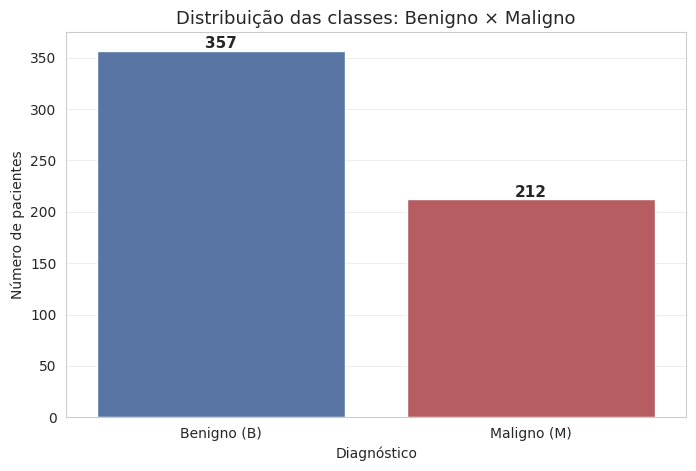

In [251]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x=TARGET_COL, data=df, order=[NEGATIVE_RAW, POSITIVE_RAW], hue=TARGET_COL, palette={NEGATIVE_RAW:'#4C72B0', POSITIVE_RAW: '#C44E52'})
ax.set_xticks([0, 1])
ax.set_xticklabels([f'{NEGATIVE_LABEL} (B)', f'{POSITIVE_LABEL} (M)'])
plt.title('Distribuição das classes: Benigno × Maligno', fontsize=13)
plt.xlabel('Diagnóstico')
plt.ylabel('Número de pacientes')

# Anotar valores absolutos sobre cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.savefig(_FIGURES_DIR / '01_distribuicao_classes.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Distribuição das features (histogramas)

Plotar todas as 30 features simultaneamente em uma grade 6×5 oferece uma visão geral rápida de:

- **Forma da distribuição** (normal, assimétrica, multimodal).
- **Escala absoluta** (algumas em centésimos, outras em milhares, o que confirma necessidade de scaling).
- **Outliers** (caudas longas à direita, ex.: `area_mean`, `area_worst`). A implicação para a escolha do scaler é discutida na Etapa 3.4.

Outliers não foram removidos: em dados clínicos, valores extremos representam pacientes reais, não erros de medição. Um tumor com `area_worst` muito elevado é exatamente o caso que o modelo precisa aprender a classificar corretamente. Removê-los enviesaria o modelo contra as apresentações mais atípicas e potencialmente mais graves.


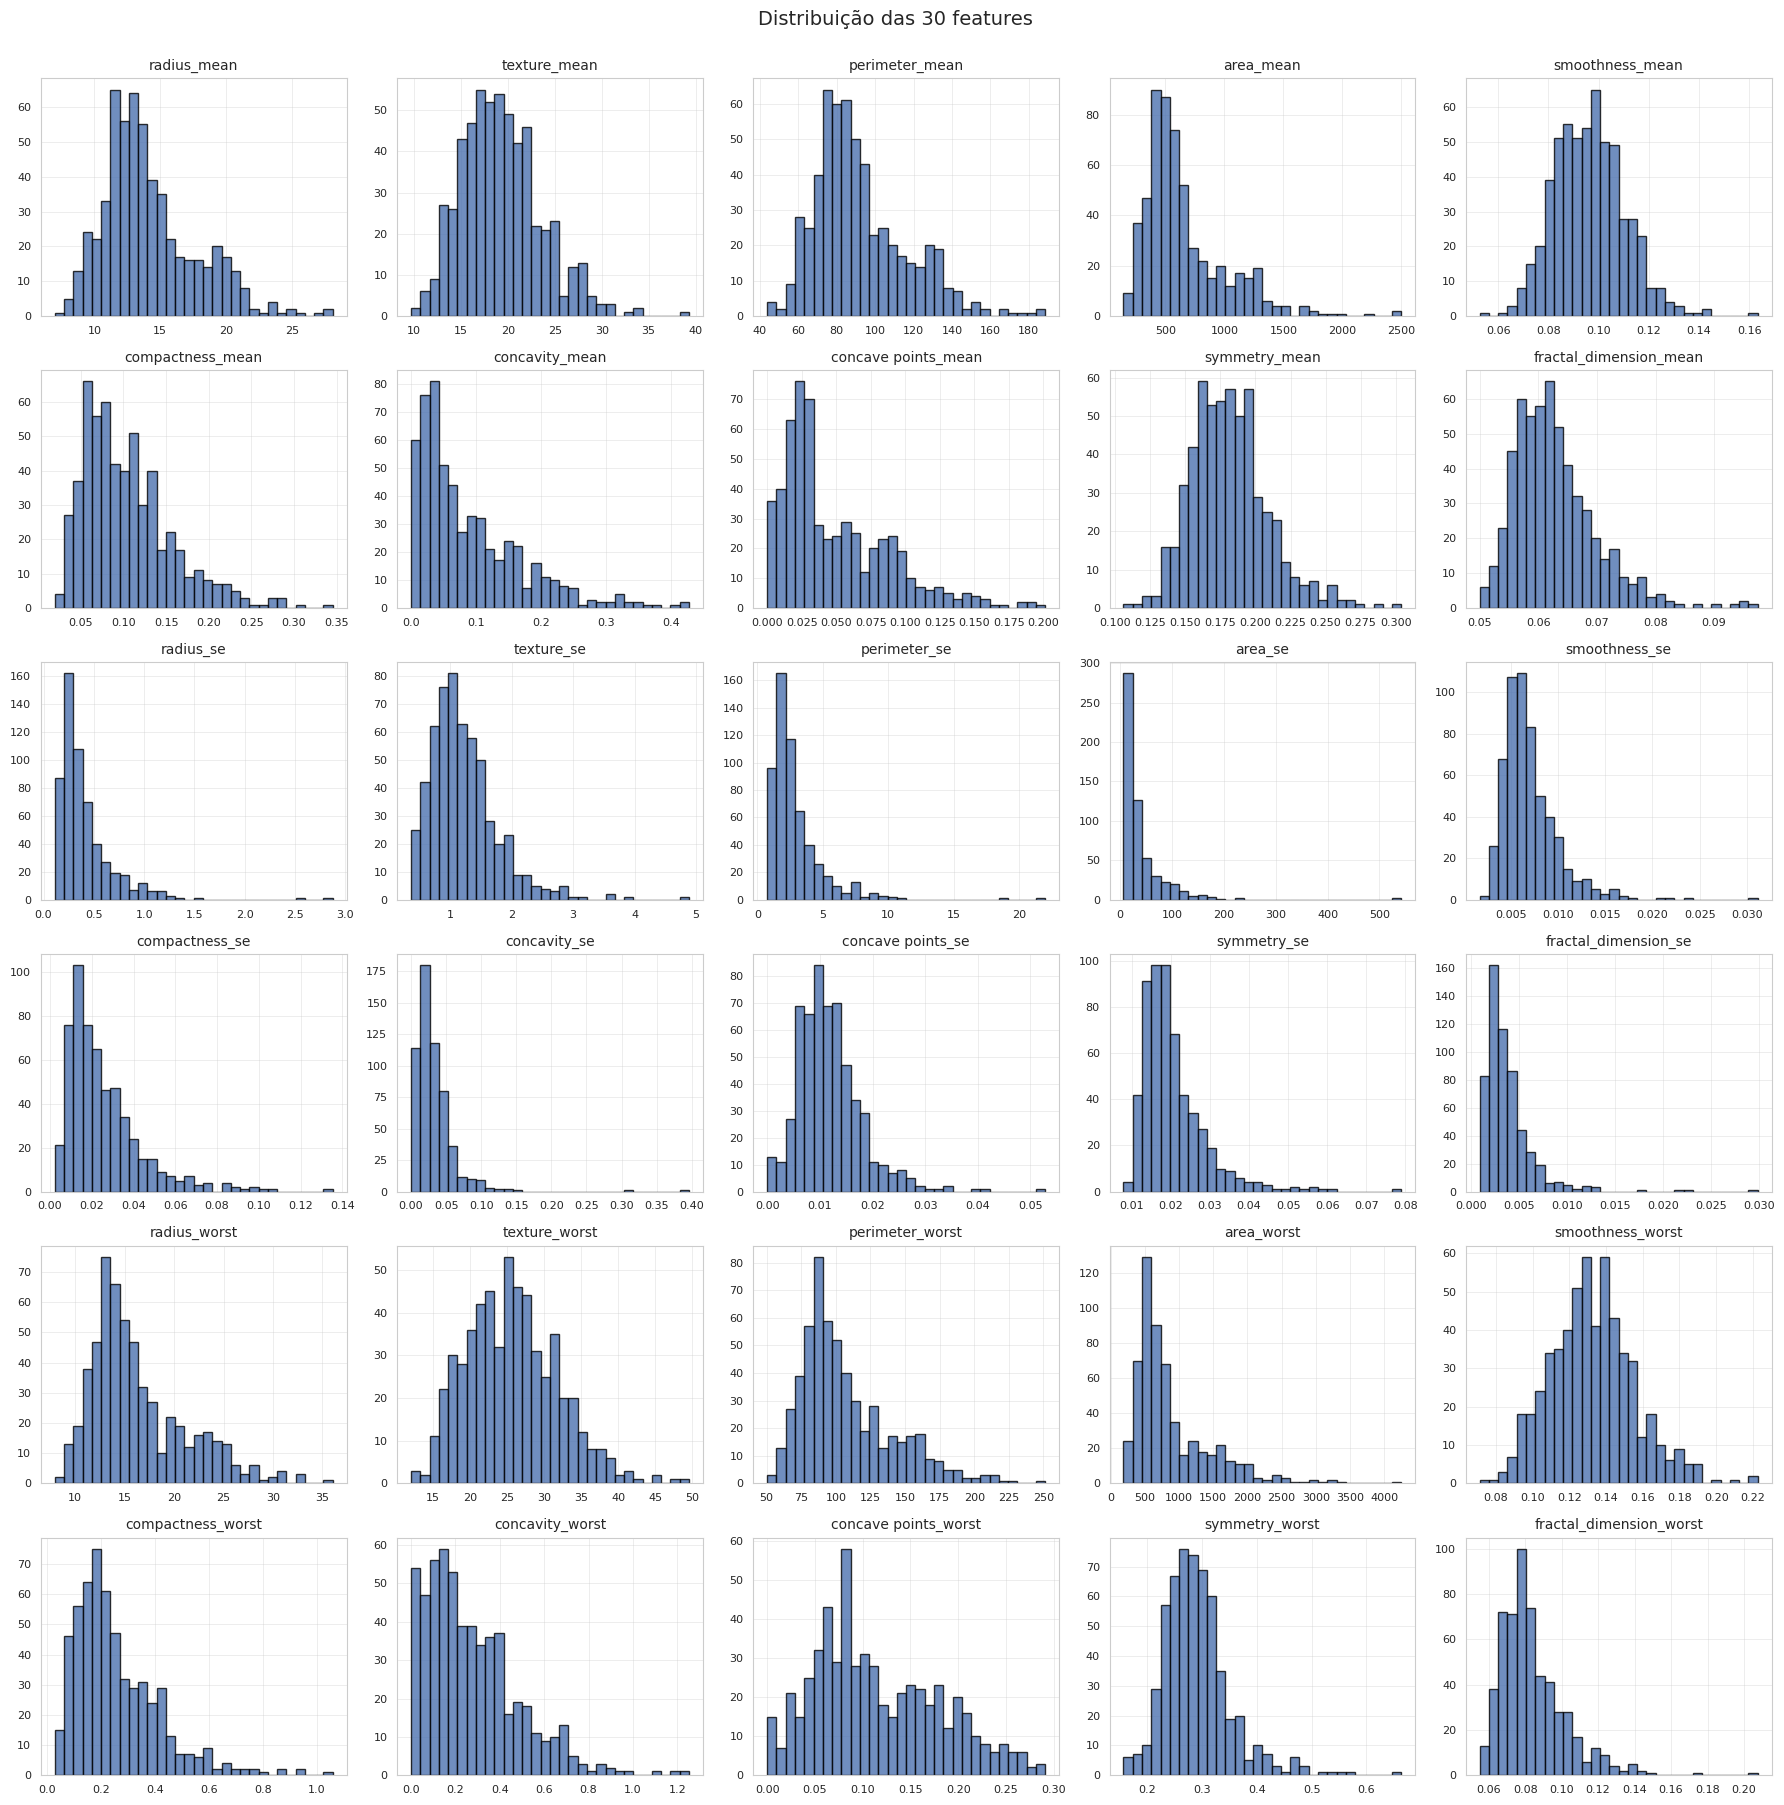

In [252]:
# Histograma de cada feature numérica (descartando id, target e Unnamed: 32)
features_numericas = df.drop(columns=COLS_TO_DROP + [TARGET_COL]).columns

fig, axes = plt.subplots(6, 5, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(features_numericas):
    axes[i].hist(df[col], bins=30, color='#4C72B0', edgecolor='black', alpha=0.8)
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Distribuição das 30 features', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '02_boxplots_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Correlação entre features

O heatmap de correlação revela multicolinearidade: pares de features que carregam essencialmente a mesma informação. No Breast Cancer Wisconsin esse fenômeno é estrutural: como `area = π × radius²` e `perimeter = 2π × radius`, esses três grupos de features apresentarão correlação ≈ 1,0 dentro de cada bloco (`mean`, `se`, `worst`).

A multicolinearidade não impede modelos baseados em árvore (RF, DT), mas degrada estimativas de coeficientes em Regressão Logística e prejudica modelos baseados em distância (**KNN, SVM**), motivos para tratar isso na Etapa 2.7.2 (drop de features correlacionadas).

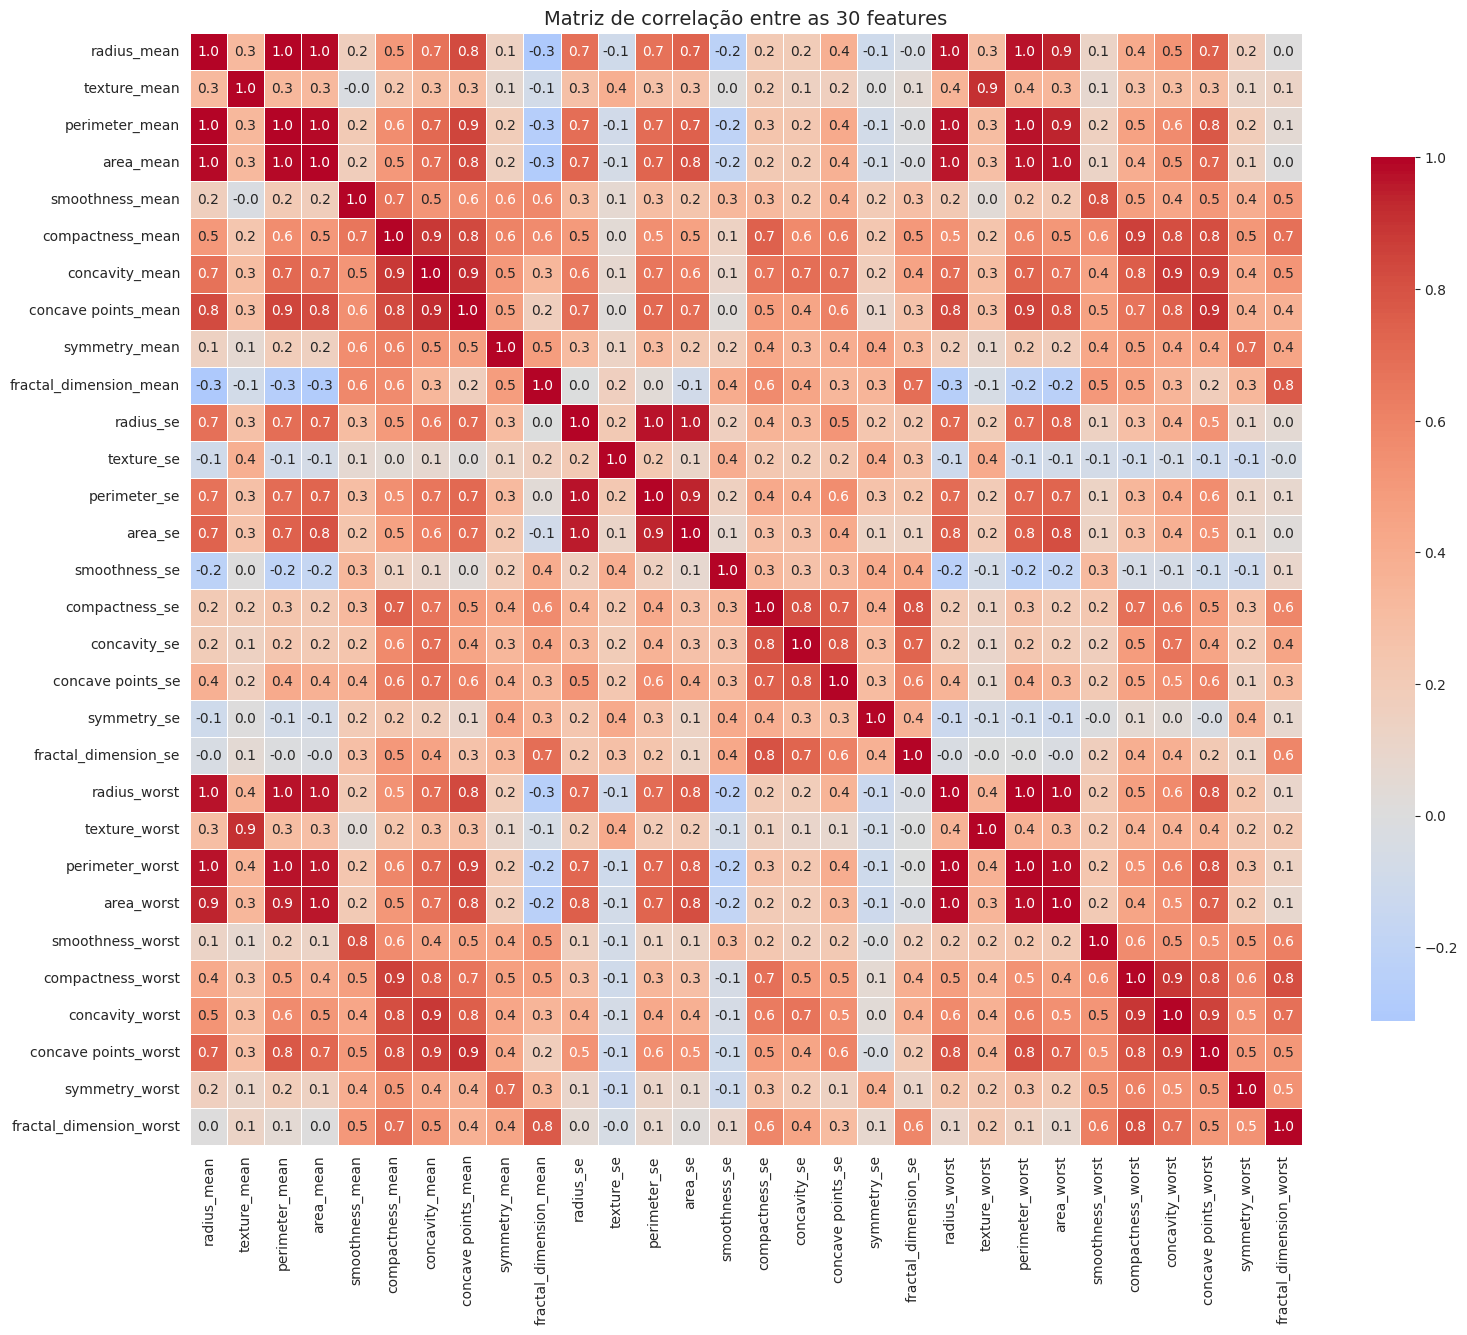

In [253]:
corr = df.drop(columns=COLS_TO_DROP + [TARGET_COL]).corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.7})
plt.title('Matriz de correlação entre as 30 features', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '03_correlacao_features.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.6 Correlação das features com a target

Após codificar a target em valor numérico (`B` → 0, `M` → 1), calculamos a correlação de cada feature com o diagnóstico. Essa lista, ordenada decrescentemente, antecipa quais features serão mais discriminativas no modelo final.

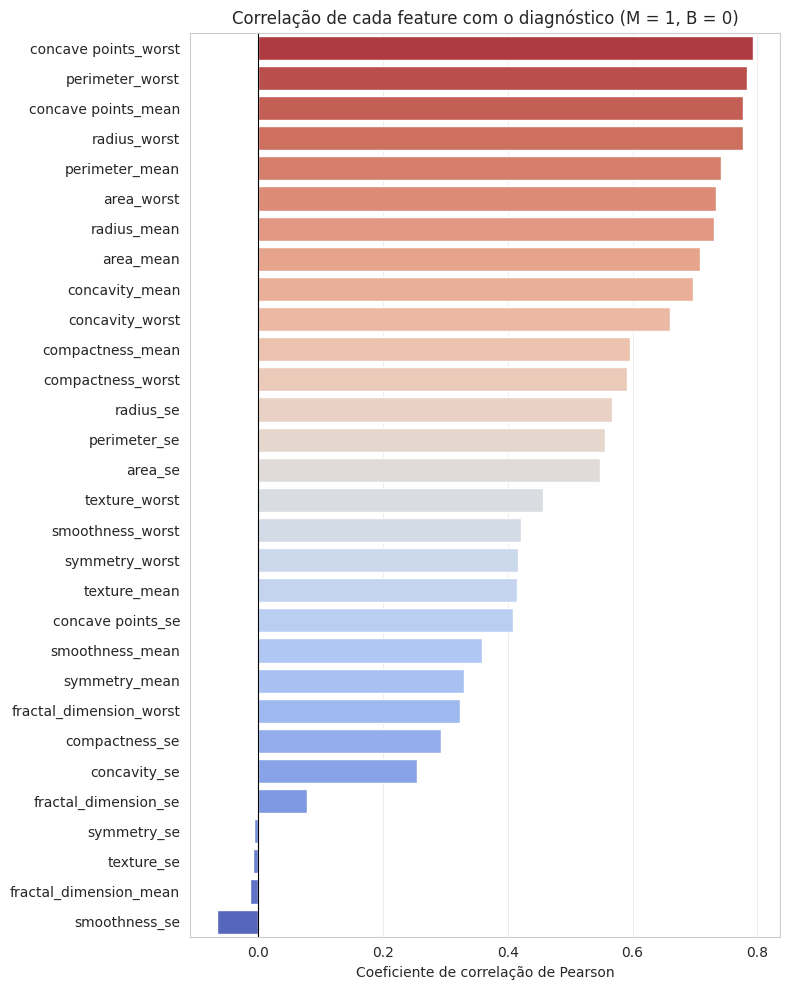

2026-07-12 19:00:59 | INFO     | breast_cancer_ag | === Top 10 features mais correlacionadas com malignidade ===


concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
concavity_mean          0.696
concavity_worst         0.660
Name: diagnosis, dtype: float64


In [254]:
# Correlação de cada feature com a target (apenas para visualização: encoding oficial será na Etapa 3)
df_temp = df.drop(columns=COLS_TO_DROP).copy()
df_temp[TARGET_COL] = (df_temp[TARGET_COL] == POSITIVE_RAW).astype(int)

corr_target = df_temp.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(x=corr_target.values, y=corr_target.index,
            hue=corr_target.index, palette='coolwarm_r', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de cada feature com o diagnóstico (M = 1, B = 0)', fontsize=12)
plt.xlabel('Coeficiente de correlação de Pearson')
plt.ylabel('')
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '04_correlacao_target.png', dpi=150, bbox_inches='tight')
plt.show()

logger.info('=== Top 10 features mais correlacionadas com malignidade ===')
print(corr_target.head(10).round(3))

---

### 2.7 Visualização Avançada e Feature Selection

Antes das análises por classe, separamos features e target. Esta separação é somente para fins exploratórios: o pipeline oficial (com `train_test_split` + `StandardScaler` + estimador) será construído na Etapa 3.

In [255]:
X = df.drop(columns=COLS_TO_DROP + [TARGET_COL])
y = (df[TARGET_COL] == POSITIVE_RAW).astype(int)   # 1 = Maligno, 0 = Benigno

logger.info(f'X.shape: {X.shape}')  # (569, 30)
logger.info(f'y.shape: {y.shape}')  # (569,)
logger.info(f'Distribuição de y: {dict(y.value_counts())}')

2026-07-12 19:00:59 | INFO     | breast_cancer_ag | X.shape: (569, 30)
2026-07-12 19:00:59 | INFO     | breast_cancer_ag | y.shape: (569,)
2026-07-12 19:00:59 | INFO     | breast_cancer_ag | Distribuição de y: {0: np.int64(357), 1: np.int64(212)}


### 2.7.1 Distribuições por classe: boxplot + pontos individuais

**Estrutura do dataset BC**: as 30 features estão organizadas em **3 blocos de 10**:
- **`mean`** (índices 0-9): valor médio da característica do núcleo celular
- **`se`** (índices 10-19): erro padrão (variabilidade entre núcleos)
- **`worst`** (índices 20-29): pior valor observado (média dos 3 maiores)

Plotar os 3 grupos separadamente evita poluição visual e permite comparar as 3 versões da mesma característica. O boxplot mostra mediana e quartis; os pontos individuais (stripplot) exibem a distribuição real dos dados sem suavização. Features com pouca sobreposição entre maligno e benigno são as mais discriminativas para o modelo.


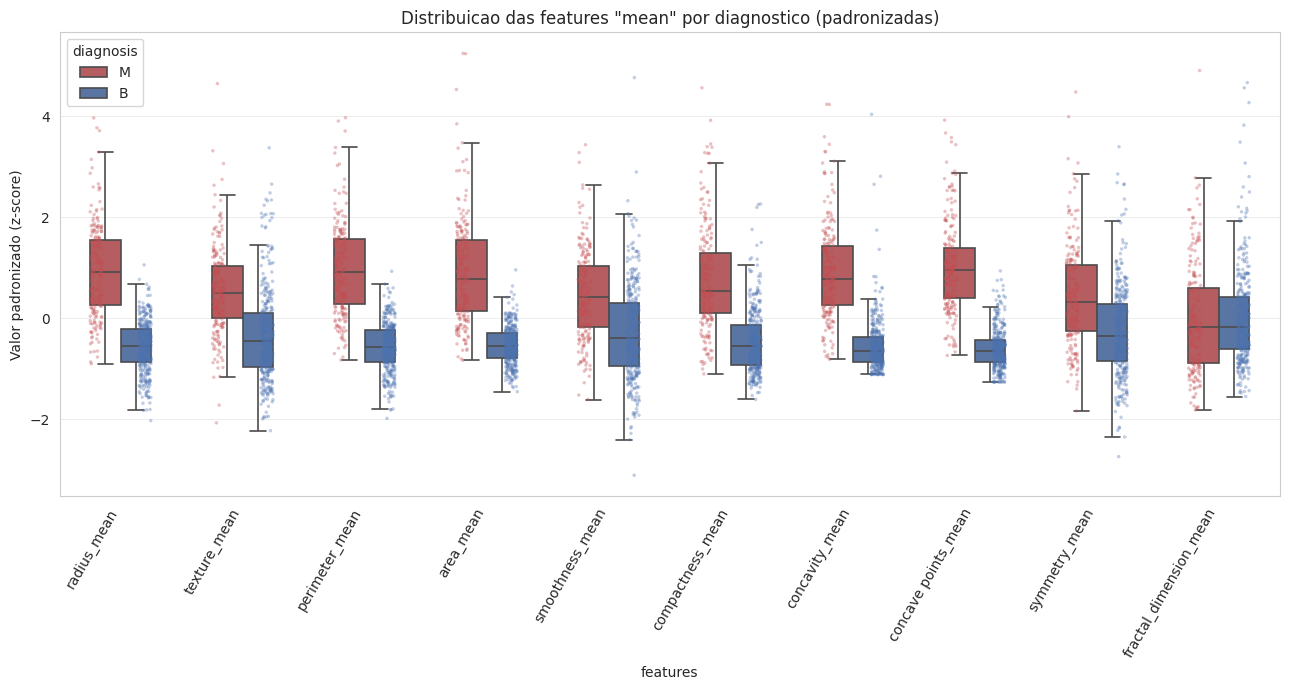

In [256]:
# Padronizar apenas para visualização (não interfere no pipeline da Etapa 3)
data_std = (X - X.mean()) / X.std()

# Recriar a coluna target nominal (M/B) para o hue
y_nominal = df[TARGET_COL]

PALETTE = {NEGATIVE_RAW: '#4C72B0', POSITIVE_RAW: '#C44E52'}

def plot_box_strip_group(start, end, group_name):
    data_viz = pd.concat([y_nominal, data_std.iloc[:, start:end]], axis=1)
    data_viz = pd.melt(data_viz, id_vars=TARGET_COL, var_name='features', value_name='value')

    fig, ax = plt.subplots(figsize=(13, 7))
    sns.boxplot(x='features', y='value', hue=TARGET_COL, data=data_viz,
                showfliers=False, width=0.5, palette=PALETTE, linewidth=1.2, ax=ax)
    sns.stripplot(x='features', y='value', hue=TARGET_COL, data=data_viz,
                  jitter=True, dodge=True, size=2.5, alpha=0.35, palette=PALETTE,
                  legend=False, ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=60, ha='right')
    ax.set_title(f'Distribuicao das features "{group_name}" por diagnostico (padronizadas)', fontsize=12)
    ax.set_ylabel('Valor padronizado (z-score)')
    plt.tight_layout()
    plt.savefig(_FIGURES_DIR / '05_distribuicao_grupos_features.png', dpi=150, bbox_inches='tight')
plt.show()


# Bloco 1: features _mean (0-9)
plot_box_strip_group(0, 10, 'mean')


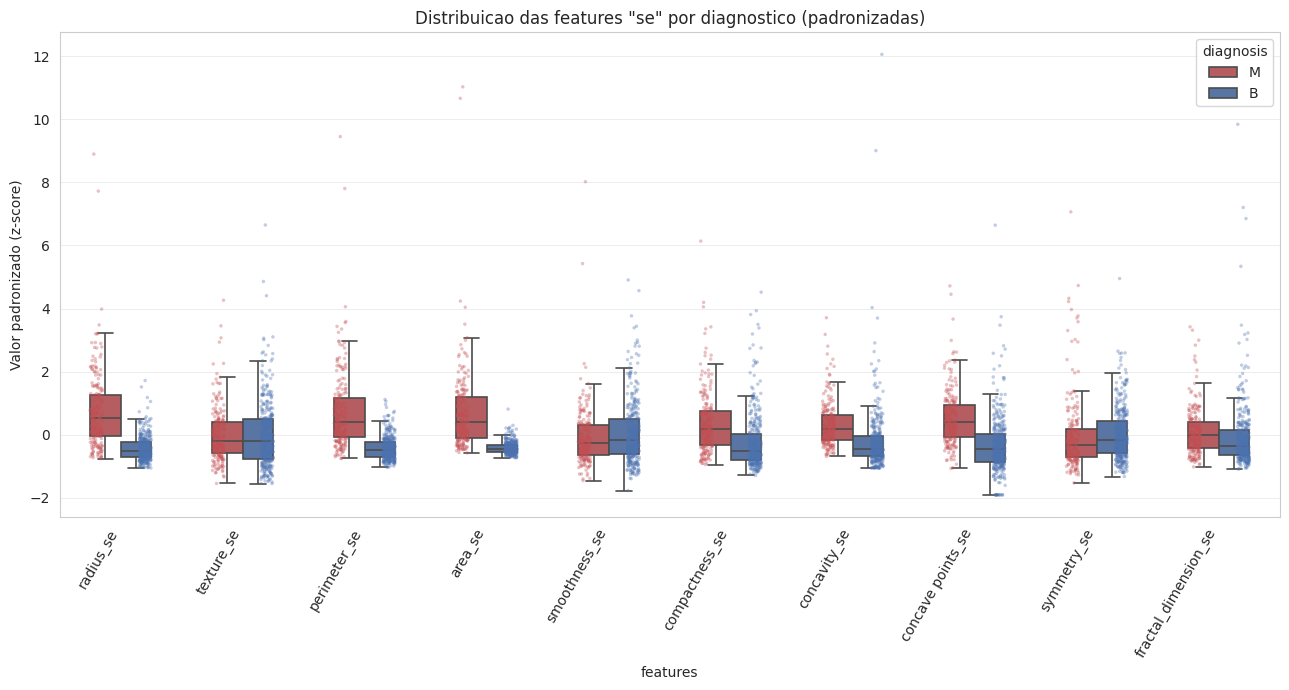

In [257]:
# Bloco 2: features _se (10-19): variabilidade
plot_box_strip_group(10, 20, 'se')


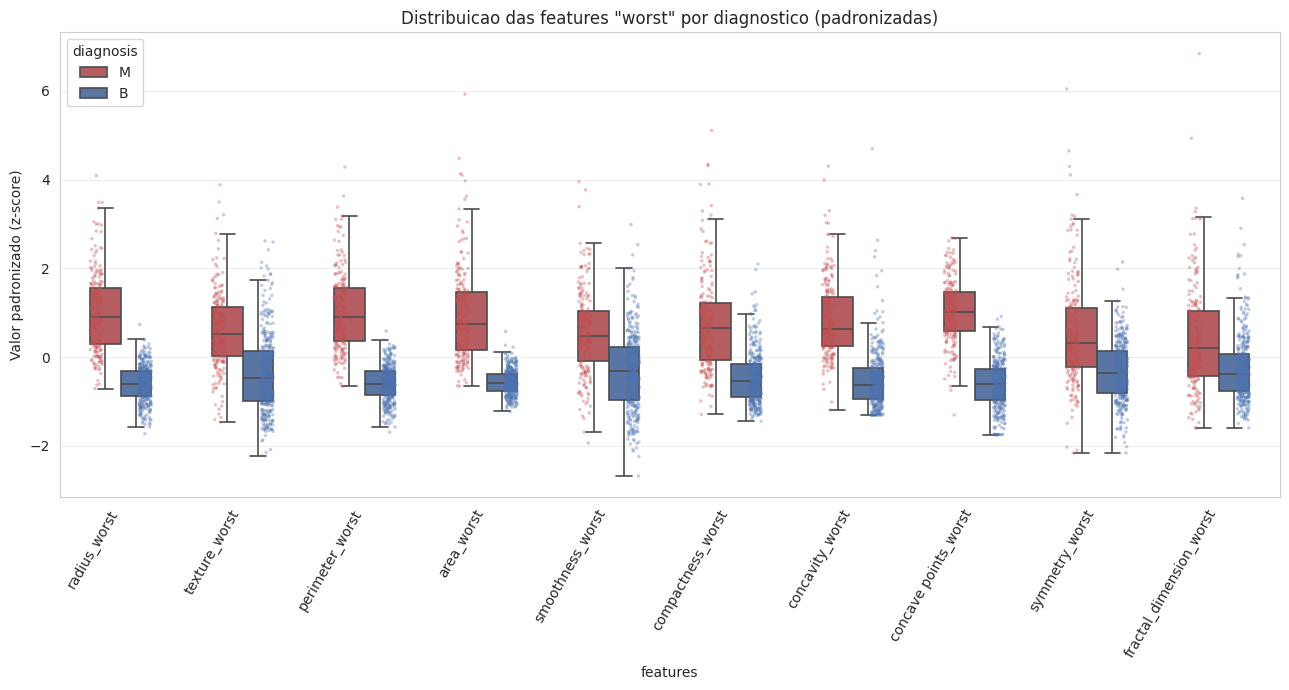

In [258]:
# Bloco 3: features _worst (20-29): pior valor por amostra
plot_box_strip_group(20, 30, 'worst')


### 2.7.2 Drop manual por correlação alta (multicolinearidade)

A partir do heatmap (Etapa 2.5), identificamos pares com `|corr| > 0,9`. Removemos uma feature de cada par, priorizando a de maior correlação com o target (Etapa 2.6) e menor redundância:

- **Família radius/perimeter/area**: as três são geometricamente dependentes. Mantemos `area_mean` e `area_se`; removemos `radius_*`, `perimeter_*` e `area_worst`.
- **Bloco `_se` redundante**: `compactness_se` e `concave points_se` removidos por alta correlação com seus pares `_mean`.
- **`_mean` × `_worst` de alta correlação**: `compactness_mean`, `concave points_mean`, `texture_worst`, `compactness_worst` e `concave points_worst` removidos por redundância com suas versões `_worst` ou `_mean` mantidas.

Multicolinearidade prejudica especialmente **Regressão Logística** (instabilidade dos coeficientes) e modelos baseados em distância (SVM). Random Forest é robusto a isso, mas reduzir features melhora interpretabilidade e velocidade de treino.

`X_reduced` é gerado aqui apenas para visualizar a redução de correlação no heatmap abaixo. As Etapas 2.7.3 e 2.7.4 usam `X` completo (análise exploratória independente), e a modelagem (Etapa 4) também usa `X` completo.


In [259]:
# Lista de features altamente correlacionadas a remover (baseada no heatmap da Etapa 2.5)
drop_list = [
    'perimeter_mean', 'radius_mean', 'compactness_mean', 'concave points_mean',
    'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst',
    'compactness_worst', 'concave points_worst', 'compactness_se',
    'concave points_se', 'texture_worst', 'area_worst'
]

X_reduced = X.drop(columns=drop_list)

logger.info(f'Features originais: {X.shape[1]}')
logger.info(f'Features após drop: {X_reduced.shape[1]}')
logger.info(f'Features removidas ({len(drop_list)}):')
for f in drop_list:
    logger.info(f'  - {f}')

logger.info(f'\nFeatures mantidas ({X_reduced.shape[1]}):')
for f in X_reduced.columns.tolist():
    logger.info(f'  - {f}')

2026-07-12 19:01:04 | INFO     | breast_cancer_ag | Features originais: 30
2026-07-12 19:01:04 | INFO     | breast_cancer_ag | Features após drop: 16
2026-07-12 19:01:04 | INFO     | breast_cancer_ag | Features removidas (14):
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - perimeter_mean
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - radius_mean
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - compactness_mean
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - concave points_mean
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - radius_se
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - perimeter_se
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - radius_worst
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - perimeter_worst
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - compactness_worst
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - concave points_worst
2026-07-12 19:01:04 | INFO     | breast_cancer_ag |   - co

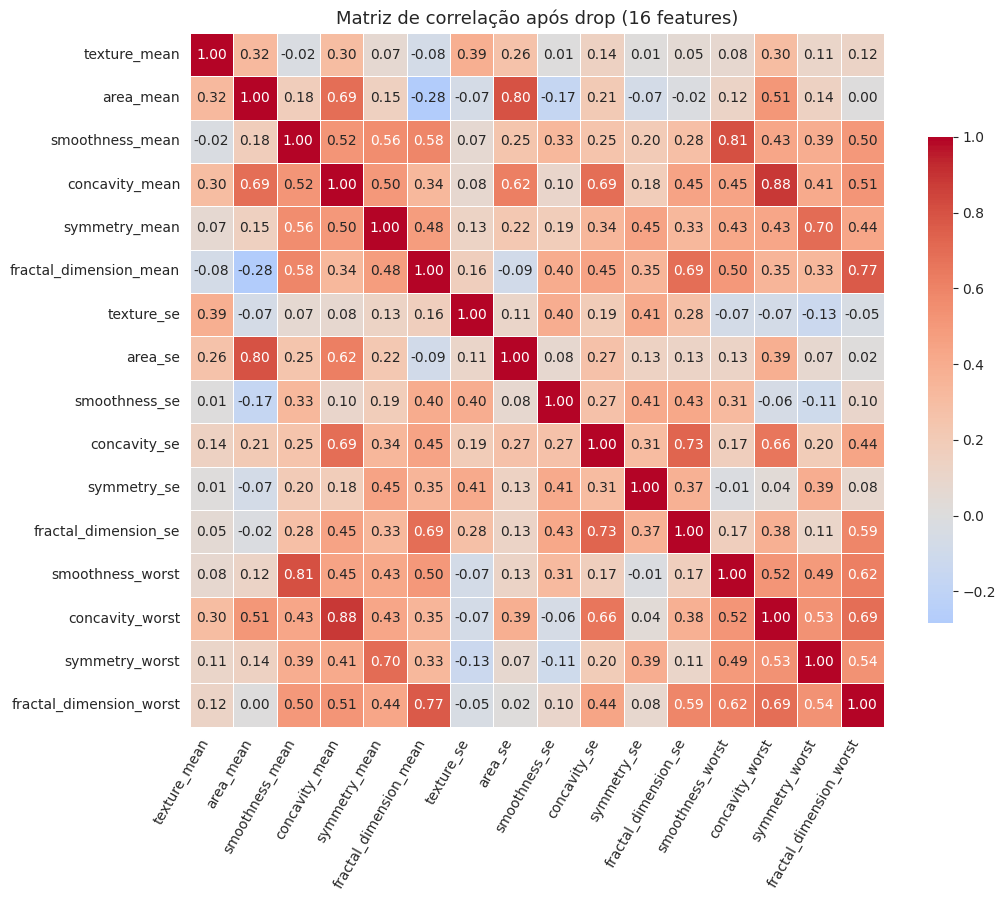

In [260]:
# Verificar visualmente que a multicolinearidade reduziu (heatmap após drop)
plt.figure(figsize=(11, 9))
sns.heatmap(X_reduced.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.7})
plt.title(f'Matriz de correlação após drop ({X_reduced.shape[1]} features)', fontsize=13)
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '06_correlacao_pos_drop.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.7.3 Feature selection automatizada

Aplicamos 2 técnicas para validar (ou refinar) a escolha manual:

- **`RFE` (Recursive Feature Elimination)**: treina um modelo, descarta a feature menos importante, repete. Considera interações entre features (multivariado). Aqui usamos `RandomForestClassifier` como avaliador.
- **`RFECV`**: variante do RFE que usa cross-validation para escolher automaticamente o número ótimo de features.

As técnicas são aplicadas aqui sobre `X` completo para fins exploratórios. Os resultados não alimentam o modelo final, que usa `X_train` completo dentro de um `Pipeline`.

In [261]:
from sklearn.feature_selection import RFE, RFECV
from sklearn.ensemble import RandomForestClassifier

# (a) RFE: top 5 features pelo Random Forest (multivariado)
rfe = RFE(estimator=RandomForestClassifier(random_state=42, n_estimators=100),
          n_features_to_select=5, step=1).fit(X, y)
top_rfe = X.columns[rfe.support_].tolist()
logger.info('Top 5 features (RFE com RandomForest):')
for f in top_rfe:
    logger.info(f'  - {f}')

2026-07-12 19:01:11 | INFO     | breast_cancer_ag | Top 5 features (RFE com RandomForest):
2026-07-12 19:01:11 | INFO     | breast_cancer_ag |   - concave points_mean
2026-07-12 19:01:11 | INFO     | breast_cancer_ag |   - radius_worst
2026-07-12 19:01:11 | INFO     | breast_cancer_ag |   - perimeter_worst
2026-07-12 19:01:11 | INFO     | breast_cancer_ag |   - area_worst
2026-07-12 19:01:11 | INFO     | breast_cancer_ag |   - concave points_worst


2026-07-12 19:01:31 | INFO     | breast_cancer_ag | Número ótimo de features (RFECV, otimizado para recall): 18
2026-07-12 19:01:31 | INFO     | breast_cancer_ag | 
Features escolhidas pelo RFECV:
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - radius_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - texture_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - perimeter_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - area_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - compactness_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - concavity_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - concave points_mean
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - radius_se
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - area_se
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - radius_worst
2026-07-12 19:01:31 | INFO     | breast_cancer_ag |   - texture_worst
2026-07-12 19:01:31 | INFO     | breast_

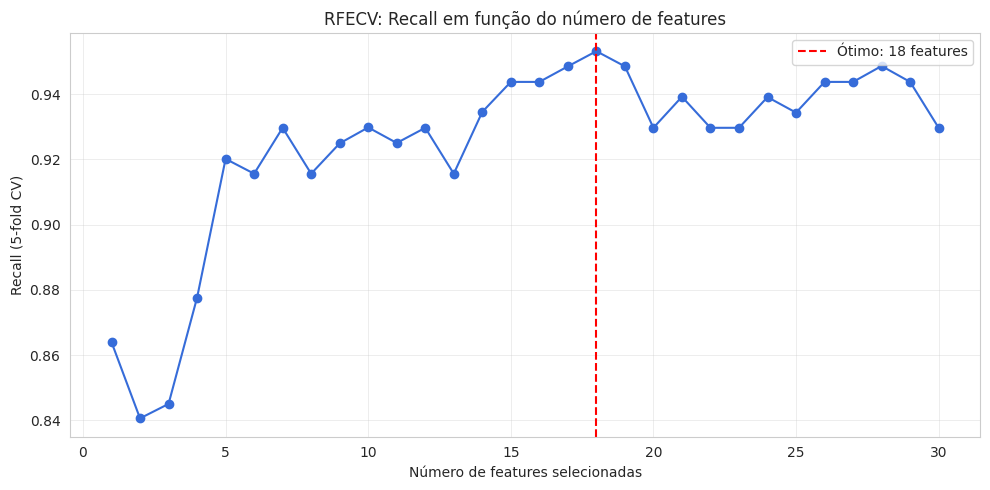

In [262]:
# (b) RFECV: escolhe automaticamente o nº ótimo de features otimizando recall
rfecv = RFECV(estimator=RandomForestClassifier(random_state=42, n_estimators=100),
              step=1, cv=5, scoring='recall').fit(X, y)

logger.info(f'Número ótimo de features (RFECV, otimizado para recall): {rfecv.n_features_}')
logger.info('\nFeatures escolhidas pelo RFECV:')
for f in X.columns[rfecv.support_].tolist():
    logger.info(f'  - {f}')

# Plotar curva de recall × nº de features
plt.figure(figsize=(10, 5))
mean_scores = rfecv.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, marker='o')
plt.axvline(rfecv.n_features_, color='red', linestyle='--',
            label=f'Ótimo: {rfecv.n_features_} features')
plt.xlabel('Número de features selecionadas')
plt.ylabel('Recall (5-fold CV)')
plt.title('RFECV: Recall em função do número de features')
plt.legend()
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '07_rfecv_recall_features.png', dpi=150, bbox_inches='tight')
plt.show()

**RFE vs. seleção manual (Etapa 2.7.2)**: as features selecionadas pelo RFE/RFECV nem sempre coincidem com as removidas pela análise de correlação, pois os métodos trabalham em perspectivas distintas.

- **Seleção manual**: correlação bivariada de Pearson. Remove redundâncias entre features (multicolinearidade) e features com baixa correlação individual com `diagnosis`.
- **RFE/RFECV**: avalia importância em contexto multivariado. Pode manter features de correlação individual moderada quando elas contribuem ao conjunto como um todo.

Ambas as análises são exploratórias. A modelagem (Etapa 4) usa `X` completo, permitindo que os algoritmos (especialmente o Random Forest) trabalhem com todas as features disponíveis. RFE e seleção por correlação serviram aqui para entender a estrutura dos dados antes de modelar.


### 2.7.4 PCA: Análise de Componentes Principais

PCA é uma técnica de **redução de dimensionalidade** que transforma as 30 features originais em componentes ortogonais (não-correlacionados) ordenados pela variância que explicam. Em datasets com muita multicolinearidade (caso do BC), poucos componentes capturam a maior parte da variância total.

Por que padronizar antes: PCA é sensível à escala. Uma feature com magnitude 1000× maior dominaria os componentes apenas pela escala bruta, não pela informação. Sempre aplicar `StandardScaler` antes do PCA.

Trade-off em contexto médico: ganha-se compactação, perde-se interpretabilidade (componentes não são mais features clinicamente reconhecíveis como 'raio do núcleo'). Neste projeto, a modelagem usa `X` completo com todas as features originais, sem redução dimensional.

O PCA abaixo é aplicado sobre `X_scaled` (dataset completo padronizado) apenas para fins exploratórios. Em produção, deve ser encapsulado dentro de um `Pipeline` e ajustado somente sobre `X_train`. Aplicar PCA antes do split ou fora do Pipeline constitui data leakage.

Três análises sequenciais:
- **(a) Variância acumulada**: quantos componentes preservam 95% da informação?
- **(b) Screeplot**: variância individual de cada componente.
- **(c) Biplot 2D**: verificar se as 2 primeiras componentes preservam a separação maligno × benigno.


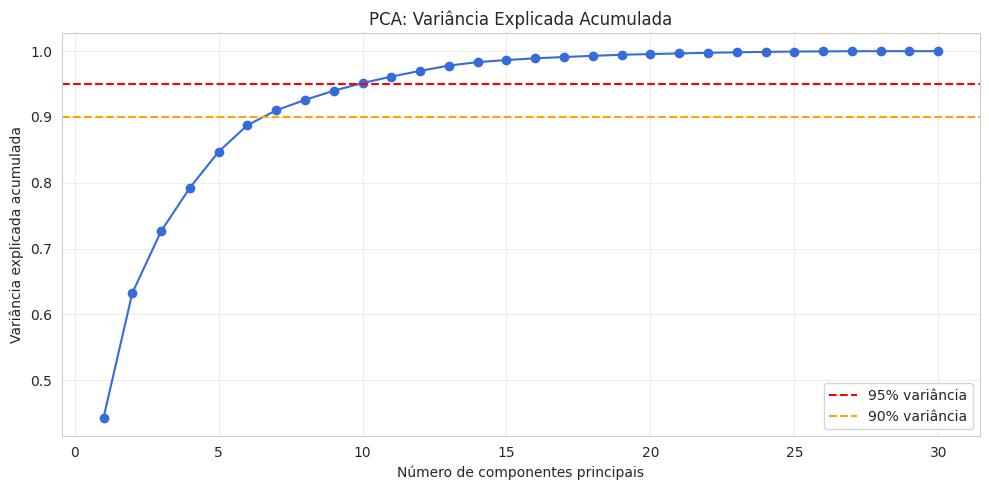

2026-07-12 19:01:31 | INFO     | breast_cancer_ag | Componentes para preservar 90% da variância: 7
2026-07-12 19:01:31 | INFO     | breast_cancer_ag | Componentes para preservar 95% da variância: 10


In [263]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Padronização exploratória (a Etapa 3 fará isso oficialmente dentro do pipeline)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ajustar PCA com TODOS os componentes (= nº de features)
pca_full = PCA().fit(X_scaled)

# (a) Variância explicada acumulada
plt.figure(figsize=(10, 5))
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
plt.plot(range(1, len(cumvar) + 1), cumvar, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variância')
plt.axhline(0.90, color='orange', linestyle='--', label='90% variância')
plt.xlabel('Número de componentes principais')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA: Variância Explicada Acumulada')
plt.legend()
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '08_pca_variancia_acumulada.png', dpi=150, bbox_inches='tight')
plt.show()

# Imprimir nº de componentes para 90% e 95%
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
logger.info(f'Componentes para preservar 90% da variância: {n_90}')
logger.info(f'Componentes para preservar 95% da variância: {n_95}')

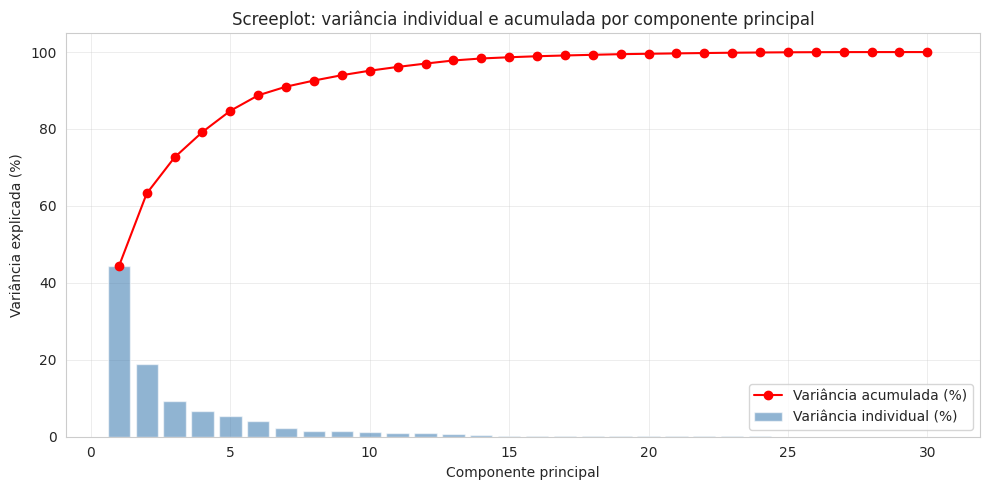

In [264]:
# (b) Screeplot: variância individual e acumulada por componente
plt.figure(figsize=(10, 5))
n = len(pca_full.explained_variance_ratio_)
plt.bar(range(1, n + 1), pca_full.explained_variance_ratio_ * 100,
        alpha=0.6, label='Variância individual (%)', color='steelblue')
plt.plot(range(1, n + 1), pca_full.explained_variance_ratio_.cumsum() * 100,
         marker='o', color='red', label='Variância acumulada (%)')
plt.xlabel('Componente principal')
plt.ylabel('Variância explicada (%)')
plt.title('Screeplot: variância individual e acumulada por componente principal')
plt.legend()
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '09_pca_screeplot.png', dpi=150, bbox_inches='tight')
plt.show()

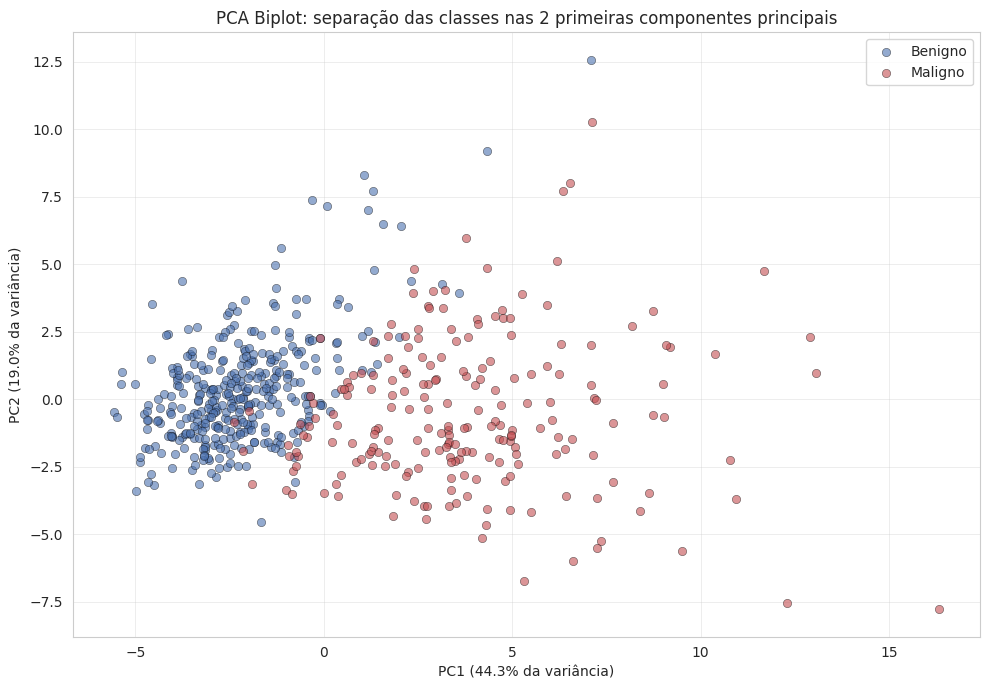

2026-07-12 19:01:32 | INFO     | breast_cancer_ag | PC1 + PC2 explicam 63.2% da variância total


In [265]:
# (c) PCA Biplot 2D: verifica se as 2 primeiras componentes separam as classes
pca_2d = PCA(n_components=2).fit(X_scaled)
X_pca = pca_2d.transform(X_scaled)

plt.figure(figsize=(10, 7))
for label, color, name in [(0, '#4C72B0', NEGATIVE_LABEL), (1, '#C44E52', POSITIVE_LABEL)]:
    mask = y.values == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=name, alpha=0.6, edgecolors='k', linewidths=0.4)

plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.title('PCA Biplot: separação das classes nas 2 primeiras componentes principais')
plt.legend()
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '10_pca_biplot.png', dpi=150, bbox_inches='tight')
plt.show()

variancia_2pc = (pca_2d.explained_variance_ratio_.sum() * 100)
logger.info(f'PC1 + PC2 explicam {variancia_2pc:.1f}% da variância total')

---

### 2.8 Análise de Outliers

Valores extremos em dados clínicos não são necessariamente erros de medição: podem representar casos biologicamente severos. Esta seção quantifica a presença de outliers com dois métodos complementares e avalia sua distribuição por classe antes de qualquer decisão sobre tratamento.

In [266]:
from scipy.stats import zscore

# Colunas numéricas preditivas (excluindo target e colunas não-preditivas)
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c not in COLS_TO_DROP]

# --- IQR ---
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask_iqr = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
n_outliers_iqr = outlier_mask_iqr.sum().sort_values(ascending=False)

logger.info('Top 10 features com mais outliers (IQR):')
print(n_outliers_iqr.head(10).to_string())

2026-07-12 19:01:32 | INFO     | breast_cancer_ag | Top 10 features com mais outliers (IQR):


area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24


In [267]:
# --- Z-score ---
z_scores = df[numeric_cols].apply(zscore)
outlier_mask_zscore = z_scores.abs() > 3
n_outliers_zscore = outlier_mask_zscore.sum().sort_values(ascending=False)

# Comparação entre métodos
comparison = pd.DataFrame({
    'IQR': n_outliers_iqr,
    'Z-score (>3)': n_outliers_zscore
}).sort_values('IQR', ascending=False)

logger.info('Comparação IQR x Z-score - top 10 features:')
print(comparison.head(10).to_string())

2026-07-12 19:01:32 | INFO     | breast_cancer_ag | Comparação IQR x Z-score - top 10 features:


                         IQR  Z-score (>3)
area_se                   65             6
perimeter_se              38             8
radius_se                 38             7
area_worst                35            10
smoothness_se             30             7
compactness_se            28            12
fractal_dimension_se      28            10
symmetry_se               27            11
area_mean                 25             8
fractal_dimension_worst   24             9


2026-07-12 19:01:32 | INFO     | breast_cancer_ag | Proporção de amostras com pelo menos um outlier por classe:


         IQR (%)  Z-score (%)
Benigno     16.0          7.0
Maligno     53.8         23.1


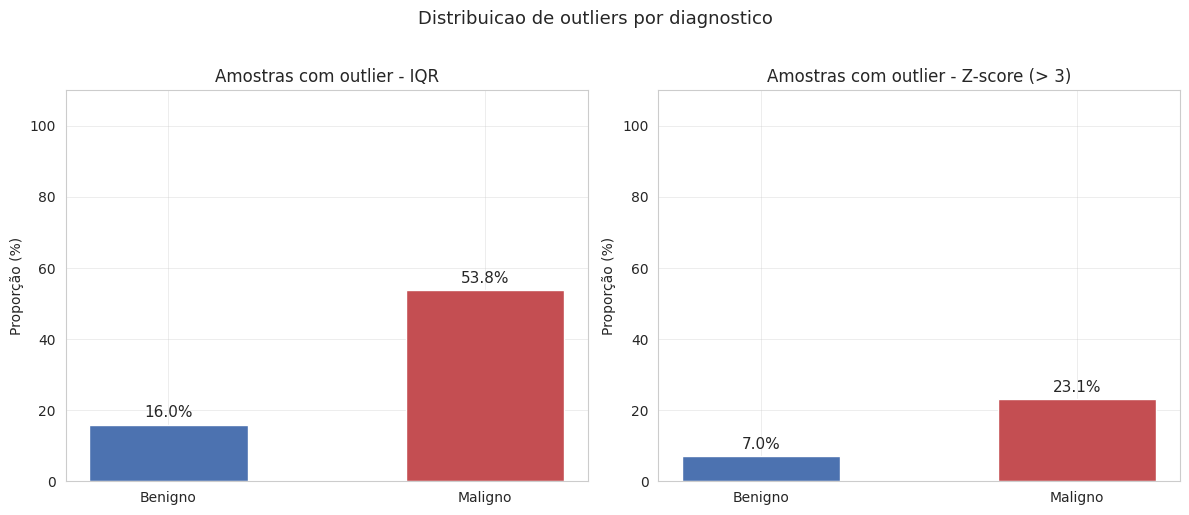

In [268]:
# --- Proporção de outliers por classe ---
df_out = df[[TARGET_COL]].copy()
df_out['has_outlier_iqr']    = outlier_mask_iqr.any(axis=1).values
df_out['has_outlier_zscore'] = outlier_mask_zscore.any(axis=1).values

outlier_by_class = (
    df_out.groupby(TARGET_COL)[['has_outlier_iqr', 'has_outlier_zscore']]
    .mean()
    .rename(columns={'has_outlier_iqr': 'IQR (%)', 'has_outlier_zscore': 'Z-score (%)'})
    * 100
).round(1)
outlier_by_class.index = [POSITIVE_LABEL if x == POSITIVE_RAW else NEGATIVE_LABEL for x in outlier_by_class.index]
logger.info('Proporção de amostras com pelo menos um outlier por classe:')
print(outlier_by_class.to_string())

# --- Visualização ---
palette = {NEGATIVE_RAW: '#4C72B0', POSITIVE_RAW: '#C44E52'}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, title in zip(
    axes,
    ['has_outlier_iqr', 'has_outlier_zscore'],
    ['IQR', 'Z-score (> 3)']
):
    prop = df_out.groupby(TARGET_COL)[col].mean() * 100
    labels = [NEGATIVE_LABEL if c == NEGATIVE_RAW else POSITIVE_LABEL for c in prop.index]
    colors = [palette[c] for c in prop.index]
    bars = ax.bar(labels, prop.values, color=colors, edgecolor='white', width=0.5)
    ax.set_title(f'Amostras com outlier - {title}', fontsize=12)
    ax.set_ylabel('Proporção (%)')
    ax.set_ylim(0, 110)
    for bar, val in zip(bars, prop.values):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 2, f'{val:.1f}%', ha='center', fontsize=11)

plt.suptitle('Distribuicao de outliers por diagnostico', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '11_outliers_distribuicao.png', dpi=150, bbox_inches='tight')
plt.show()

A classe maligna concentra proporcionalmente mais amostras com outliers do que a benigna, em ambos os métodos. Isso é esperado sob o ponto de vista clínico: tumores malignos tendem a apresentar núcleos celulares com morfologia extrema (raio, área e concavidade muito elevados), o que se traduz em valores fora do intervalo típico da população.

Os outliers não serão removidos. A análise por classe evidencia que eles representam, em sua maioria, casos clínicos reais da classe maligna. Removê-los reduziria artificialmente a diversidade de padrões da classe de interesse clínico, comprometendo a capacidade do modelo de identificar casos severos. O `StandardScaler` (z-score) aplicado na Etapa 3 padroniza as escalas sem eliminar esses pontos extremos.

## Etapa 3: Pré-processamento de Dados
### 3.1 Remoção de colunas não-preditivas

As colunas `id` e `Unnamed: 32`, identificadas na inspeção inicial (Etapa 0.3) como não-preditivas, são removidas definitivamente aqui. O código confirma os valores antes do drop.


In [269]:
# Inspecionar antes de remover (documentação da decisão)
logger.info('=== Colunas a remover ===')
for col in COLS_TO_DROP:
    if col in df.columns:
        nuniq = df[col].nunique()
        nnull = df[col].isnull().sum()
        logger.info(f'{col:20s}: {nuniq:4d} valores únicos, {nnull:4d} nulos de {df.shape[0]} linhas')

df = df.drop(columns=COLS_TO_DROP, errors='ignore')
logger.info(f'\nShape após limpeza: {df.shape}')  # esperado: (569, 31)

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | === Colunas a remover ===
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | id                  :  569 valores únicos,    0 nulos de 569 linhas
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Unnamed: 32         :    0 valores únicos,  569 nulos de 569 linhas
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | 
Shape após limpeza: (569, 31)


In [270]:
# Confirmar ausência de nulos restantes
logger.info('Nulos por coluna após limpeza:')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string() or 'Nenhum nulo restante.')

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Nulos por coluna após limpeza:


Series([], )


### 3.2 Encoding da variável target

Usamos `LabelEncoder` do sklearn para converter `diagnosis` de string para inteiro. `LabelEncoder` codifica em ordem alfabética: `B→0` e `M→1`, que coincide com a convenção correta para este dataset (Benigno = 0, Maligno = 1).


In [271]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df[TARGET_COL] = le.fit_transform(df[TARGET_COL])

logger.info(f'Classes aprendidas pelo LabelEncoder: {le.classes_}')  # ['B' 'M'] → B=0, M=1
logger.info(f'\nDistribuição após encoding:')
print(df[TARGET_COL].value_counts())
logger.info(f'\nTipo da coluna: {df[TARGET_COL].dtype}')  # deve ser int64

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Classes aprendidas pelo LabelEncoder: ['B' 'M']
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | 
Distribuição após encoding:
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | 
Tipo da coluna: int64


diagnosis
0    357
1    212
Name: count, dtype: int64


### 3.3 Separação treino / teste: split estratificado

`train_test_split` com `stratify=y` garante que a proporção 62,74% benignos × 37,26% malignos seja preservada em ambos os conjuntos. Sem `stratify`, uma divisão azarada poderia concentrar malignos em um dos lados, enviesando treino e avaliação.

- `test_size=0.2`: 80% treino (455 amostras) / 20% teste (114 amostras)
- `random_state=42`: reprodutibilidade

In [272]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

logger.info(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
logger.info(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
logger.info(f'\nProporção maligno no treino: {y_train.mean()*100:.2f}%')
logger.info(f'Proporção maligno no teste:  {y_test.mean()*100:.2f}%')

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | X_train: (455, 30)  |  y_train: (455,)
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | X_test:  (114, 30)   |  y_test:  (114,)
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | 
Proporção maligno no treino: 37.36%
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Proporção maligno no teste:  36.84%


### 3.4 StandardScaler: justificativa de uso

Features como `area_mean` (média ≈ 654, máx ≈ 2501) e `smoothness_mean` (média ≈ 0,096) estão em escalas radicalmente diferentes. **Modelos afetados**:

- **Regressão Logística**: usa regularização (penalidade L2/L1) baseada na magnitude dos coeficientes. Sem scaling, features de maior escala recebem coeficientes artificialmente menores, distorcendo a penalização.
- **SVM**: o kernel `rbf` computa distâncias no espaço de features. Sem scaling, features de grande magnitude dominam o cálculo, tornando o hiperplano enviesado.
- **Random Forest / Decision Tree**: **não exigem scaling**. Baseados em limiares (`if feature > X`), invariantes à escala. O scaling não prejudica, mas tampouco ajuda.

Optamos por `StandardScaler` (z-score: subtrai a média, divide pelo desvio-padrão) em vez de `MinMaxScaler` porque distribuições com caudas longas comprimiriam a maioria dos dados num intervalo estreito com o MinMaxScaler.

`StandardScaler` é sensível a outliers: média e desvio-padrão são influenciados por valores extremos. Para este dataset, a intensidade dos outliers é moderada e a escolha é adequada. `RobustScaler` (mediana + IQR) é a alternativa para casos com outliers severos.

O scaler é ajustado apenas no `X_train` (`fit_transform`) e aplicado com `transform` no `X_test`, para evitar data leakage


### 3.5 Verificação do pré-processamento

Confirmar que o shape dos dados está correto e que o split respeitou o balanceamento antes de passar para a modelagem.


In [273]:
logger.info('=== Resumo do pré-processamento ===')
logger.info(f'Dataset final:  {df.shape[0]} amostras × {df.shape[1]-1} features')
logger.info(f'Treino:         {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)')
logger.info(f'Teste:          {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)')
logger.info(f'\nBalanceamento da target:')
logger.info(f'  Treino : Benigno: {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%) | Maligno: {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)')
logger.info(f'  Teste  : Benigno: {(y_test==0).sum()}  ({(y_test==0).mean()*100:.1f}%)  | Maligno: {(y_test==1).sum()}  ({(y_test==1).mean()*100:.1f}%)')
logger.info(f'\nFeatures: {list(X.columns)}')

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | === Resumo do pré-processamento ===
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Dataset final:  569 amostras × 30 features
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Treino:         455 amostras (80.0%)
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Teste:          114 amostras (20.0%)
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | 
Balanceamento da target:
2026-07-12 19:01:33 | INFO     | breast_cancer_ag |   Treino : Benigno: 285 (62.6%) | Maligno: 170 (37.4%)
2026-07-12 19:01:33 | INFO     | breast_cancer_ag |   Teste  : Benigno: 72  (63.2%)  | Maligno: 42  (36.8%)
2026-07-12 19:01:33 | INFO     | breast_cancer_ag | 
Features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavi

---

## Etapa 4: Modelagem, Validação Cruzada e Tuning de Hiperparâmetros

### 4.0 Modelos escolhidos e justificativas

Os quatro modelos cobrem diferentes hipóteses sobre a estrutura dos dados:

- **Regressão Logística**: modelo linear interpretável; os coeficientes indicam a contribuição de cada feature. Baseline sólido. Exige scaling. Pode ter dificuldade com relações não-lineares.
- **SVM (Support Vector Machine)**: encontra o hiperplano de margem máxima entre as classes. Excelente em datasets pequenos/médios (~569 amostras). Exige scaling. O GridSearchCV (Etapa 4.3) testa automaticamente os kernels `linear` e `rbf`.
- **Árvore de Decisão**: regras IF/ELSE auditáveis. Alta interpretabilidade médica/regulatória. Não exige scaling. Tendência a overfitting sem regularização de profundidade.
- **Random Forest**: ensemble de árvores com bagging. Geralmente mais preciso que árvore única, robusto a overfitting. Feature importances nativas. Não exige scaling; o Pipeline aplica sem efeito matemático, mantendo uniformidade.

In [274]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import make_scorer, recall_score

# Scorer customizado: otimizar recall da classe positiva (maligno = 1)
recall_scorer = make_scorer(recall_score, pos_label=1)

# StratifiedKFold: 5 folds com embaralhamento: mantém proporção maligno/benigno em cada fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logger.info('Configuração de validação cruzada:')
logger.info(f'  Estratégia: StratifiedKFold')
logger.info(f'  Folds: 5')
logger.info(f'  Métrica de otimização: Recall (classe positiva = Maligno)')

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | Configuração de validação cruzada:
2026-07-12 19:01:33 | INFO     | breast_cancer_ag |   Estratégia: StratifiedKFold
2026-07-12 19:01:33 | INFO     | breast_cancer_ag |   Folds: 5
2026-07-12 19:01:33 | INFO     | breast_cancer_ag |   Métrica de otimização: Recall (classe positiva = Maligno)


### 4.1 Pipelines base (sem tuning)

Cada modelo é encapsulado num `Pipeline(StandardScaler → Estimador)`, mantendo o scaling ajustado apenas nos dados de treino de cada fold e o código unificado para treino, predição e busca de hiperparâmetros.

Para Árvore e Random Forest, o scaling não tem efeito matemático (modelos invariantes à escala), mas mantemos o padrão para uniformidade do código.

In [275]:
pipelines_base = {
    'Regressão Logística': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(random_state=42, max_iter=10000))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVC(random_state=42, probability=True))
    ]),
    'Árvore de Decisão': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
}

logger.info('Pipelines criados:', list(pipelines_base.keys()))

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.10/logging/__init__.py", line 1100, in emit
    msg = self.format(record)
  File "/usr/lib/python3.10/logging/__init__.py", line 943, in format
    return fmt.format(record)
  File "/usr/lib/python3.10/logging/__init__.py", line 678, in format
    record.message = record.getMessage()
  File "/usr/lib/python3.10/logging/__init__.py", line 368, in getMessage
    msg = msg % self.args
TypeError: not all arguments converted during string formatting
Call stack:
  File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge

### 4.2 Validação cruzada: comparação baseline

`cross_validate` com múltiplas métricas simultâneas. Avaliamos:
- **Recall**: métrica primária (minimiza falsos negativos).
- **F1-score**: equilíbrio entre precision e recall.
- **Accuracy**: métrica secundária (referência geral).

Reportamos média ± desvio padrão sobre os 5 folds; o desvio padrão indica estabilidade do modelo: desvio alto = comportamento inconsistente entre folds.

In [276]:
import pandas as pd

scoring = {
    'recall':   recall_scorer,
    'f1':       'f1',
    'accuracy': 'accuracy',
}

resultados_base = {}

logger.info('=== Cross-Validation Baseline (5 folds) ===\n')
for nome, pipeline in pipelines_base.items():
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    resultados_base[nome] = {
        'Recall (média)':    scores['test_recall'].mean(),
        'Recall (std)':      scores['test_recall'].std(),
        'F1 (média)':        scores['test_f1'].mean(),
        'F1 (std)':          scores['test_f1'].std(),
        'Accuracy (média)':  scores['test_accuracy'].mean(),
        'Accuracy (std)':    scores['test_accuracy'].std(),
    }
    logger.info(f'{nome}:')
    logger.info(f"  Recall:   {scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}")
    logger.info(f"  F1:       {scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}")
    logger.info(f"  Accuracy: {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}\n")

2026-07-12 19:01:33 | INFO     | breast_cancer_ag | === Cross-Validation Baseline (5 folds) ===

2026-07-12 19:01:35 | INFO     | breast_cancer_ag | Regressão Logística:
2026-07-12 19:01:35 | INFO     | breast_cancer_ag |   Recall:   0.9529 ± 0.0399
2026-07-12 19:01:35 | INFO     | breast_cancer_ag |   F1:       0.9640 ± 0.0207
2026-07-12 19:01:35 | INFO     | breast_cancer_ag |   Accuracy: 0.9736 ± 0.0149

2026-07-12 19:01:36 | INFO     | breast_cancer_ag | SVM:
2026-07-12 19:01:36 | INFO     | breast_cancer_ag |   Recall:   0.9471 ± 0.0343
2026-07-12 19:01:36 | INFO     | breast_cancer_ag |   F1:       0.9610 ± 0.0082
2026-07-12 19:01:36 | INFO     | breast_cancer_ag |   Accuracy: 0.9714 ± 0.0054

2026-07-12 19:01:36 | INFO     | breast_cancer_ag | Árvore de Decisão:
2026-07-12 19:01:36 | INFO     | breast_cancer_ag |   Recall:   0.8941 ± 0.0606
2026-07-12 19:01:36 | INFO     | breast_cancer_ag |   F1:       0.8962 ± 0.0447
2026-07-12 19:01:36 | INFO     | breast_cancer_ag |   Accura

In [277]:
df_base = pd.DataFrame(resultados_base).T.round(4)
df_base = df_base.sort_values('Recall (média)', ascending=False)

logger.info('=== Tabela Comparativa: Baseline (sem tuning) ===')
print(df_base.to_string())

2026-07-12 19:01:37 | INFO     | breast_cancer_ag | === Tabela Comparativa: Baseline (sem tuning) ===


                     Recall (média)  Recall (std)  F1 (média)  F1 (std)  Accuracy (média)  Accuracy (std)
Regressão Logística          0.9529        0.0399      0.9640    0.0207            0.9736          0.0149
SVM                          0.9471        0.0343      0.9610    0.0082            0.9714          0.0054
Random Forest                0.9412        0.0416      0.9519    0.0207            0.9648          0.0146
Árvore de Decisão            0.8941        0.0606      0.8962    0.0447            0.9231          0.0326


### 4.3 Tuning de Hiperparâmetros: GridSearchCV

`GridSearchCV` busca exaustivamente a combinação de hiperparâmetros que maximiza o recall médio na validação cruzada (5 folds StratifiedKFold). O conjunto de teste não é usado nessa etapa, ficando reservado para a avaliação final (Etapa 5).

**Prefixo `model__`** nos parâmetros: como o modelo está encapsulado no Pipeline, o GridSearchCV precisa do prefixo `<nome_do_passo>__<parâmetro>` para alcançar os parâmetros internos.

In [278]:
from sklearn.model_selection import GridSearchCV

# === Logistic Regression ===
param_grid_lr = {
    'model__C':       [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear'],        # suporta l1 e l2
}

grid_lr = GridSearchCV(
    estimator=pipelines_base['Regressão Logística'],
    param_grid=param_grid_lr,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_lr.fit(X_train, y_train)

logger.info('=== Regressão Logística: Tuning ===')
logger.info(f'Melhores parâmetros: {grid_lr.best_params_}')
logger.info(f'Melhor Recall (CV):  {grid_lr.best_score_:.4f}')

2026-07-12 19:01:37 | INFO     | breast_cancer_ag | === Regressão Logística: Tuning ===
2026-07-12 19:01:37 | INFO     | breast_cancer_ag | Melhores parâmetros: {'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
2026-07-12 19:01:37 | INFO     | breast_cancer_ag | Melhor Recall (CV):  0.9588


In [279]:
# === SVM ===
param_grid_svm = {
    'model__C':      [0.1, 1, 10, 100],
    'model__kernel': ['linear', 'rbf'],
    'model__gamma':  ['scale', 'auto'],
}

grid_svm = GridSearchCV(
    estimator=pipelines_base['SVM'],
    param_grid=param_grid_svm,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_svm.fit(X_train, y_train)

logger.info('=== SVM: Tuning ===')
logger.info(f'Melhores parâmetros: {grid_svm.best_params_}')
logger.info(f'Melhor Recall (CV):  {grid_svm.best_score_:.4f}')

2026-07-12 19:01:37 | INFO     | breast_cancer_ag | === SVM: Tuning ===
2026-07-12 19:01:37 | INFO     | breast_cancer_ag | Melhores parâmetros: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
2026-07-12 19:01:37 | INFO     | breast_cancer_ag | Melhor Recall (CV):  0.9647


In [280]:
# === Árvore de Decisão ===
param_grid_dt = {
    'model__max_depth':        [3, 5, 7, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__criterion':         ['gini', 'entropy'],
}

grid_dt = GridSearchCV(
    estimator=pipelines_base['Árvore de Decisão'],
    param_grid=param_grid_dt,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_dt.fit(X_train, y_train)

logger.info('=== Árvore de Decisão: Tuning ===')
logger.info(f'Melhores parâmetros: {grid_dt.best_params_}')
logger.info(f'Melhor Recall (CV):  {grid_dt.best_score_:.4f}')

2026-07-12 19:01:39 | INFO     | breast_cancer_ag | === Árvore de Decisão: Tuning ===
2026-07-12 19:01:39 | INFO     | breast_cancer_ag | Melhores parâmetros: {'model__criterion': 'gini', 'model__max_depth': 7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5}
2026-07-12 19:01:39 | INFO     | breast_cancer_ag | Melhor Recall (CV):  0.9000


In [281]:
# === Random Forest ===
param_grid_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [5, 10, 20, None],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf':  [1, 2],
    'model__class_weight':      [None, 'balanced'],
}

grid_rf = GridSearchCV(
    estimator=pipelines_base['Random Forest'],
    param_grid=param_grid_rf,
    scoring=recall_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_rf.fit(X_train, y_train)

logger.info('=== Random Forest: Tuning ===')
logger.info(f'Melhores parâmetros: {grid_rf.best_params_}')
logger.info(f'Melhor Recall (CV):  {grid_rf.best_score_:.4f}')

2026-07-12 19:02:23 | INFO     | breast_cancer_ag | === Random Forest: Tuning ===
2026-07-12 19:02:23 | INFO     | breast_cancer_ag | Melhores parâmetros: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}
2026-07-12 19:02:23 | INFO     | breast_cancer_ag | Melhor Recall (CV):  0.9529


### 4.4 Comparação pré × pós tuning e seleção do melhor modelo

O gráfico abaixo compara o **recall médio de CV** antes e depois do tuning para cada modelo. Um ganho expressivo indica que os hiperparâmetros default eram subótimos; ganho nulo sugere que o modelo já era robusto.

O **melhor modelo considerando o objetivo clínico (minimizar FN)** é selecionado pelo maior recall médio de CV pós-tuning, critério consistente com a métrica prioritária definida na Etapa 1.5. Em caso de empate (modelos com diferença de recall menor que 1 desvio padrão), o modelo com menor variabilidade entre folds é preferido: comportamento mais estável entre folds.

A seleção usa threshold padrão de 0,5. Explorar thresholds menores via curva ROC (Etapa 5.4) pode aumentar o recall ao custo de mais FP.


In [282]:
# Coletar resultados pós-tuning via cross_validate sobre o melhor estimador de cada grid
grids_tuned = {
    'Regressão Logística': grid_lr,
    'SVM':                 grid_svm,
    'Árvore de Decisão':   grid_dt,
    'Random Forest':       grid_rf,
}

resultados_tuned = {}
for nome, grid in grids_tuned.items():
    scores = cross_validate(grid.best_estimator_, X_train, y_train,
                            cv=cv, scoring=scoring, n_jobs=-1)
    resultados_tuned[nome] = {
        'Recall (média)':    scores['test_recall'].mean(),
        'Recall (std)':      scores['test_recall'].std(),
        'F1 (média)':        scores['test_f1'].mean(),
        'F1 (std)':          scores['test_f1'].std(),
        'Accuracy (média)':  scores['test_accuracy'].mean(),
        'Accuracy (std)':    scores['test_accuracy'].std(),
    }

df_tuned = pd.DataFrame(resultados_tuned).T.round(4)
df_tuned = df_tuned.sort_values('Recall (média)', ascending=False)

logger.info('=== Tabela Comparativa: Pós Tuning ===')
print(df_tuned.to_string())

2026-07-12 19:02:24 | INFO     | breast_cancer_ag | === Tabela Comparativa: Pós Tuning ===


                     Recall (média)  Recall (std)  F1 (média)  F1 (std)  Accuracy (média)  Accuracy (std)
SVM                          0.9647        0.0288      0.9674    0.0114            0.9758          0.0082
Regressão Logística          0.9588        0.0300      0.9083    0.0320            0.9275          0.0256
Random Forest                0.9529        0.0300      0.9502    0.0216            0.9626          0.0164
Árvore de Decisão            0.9000        0.0576      0.8969    0.0422            0.9231          0.0311


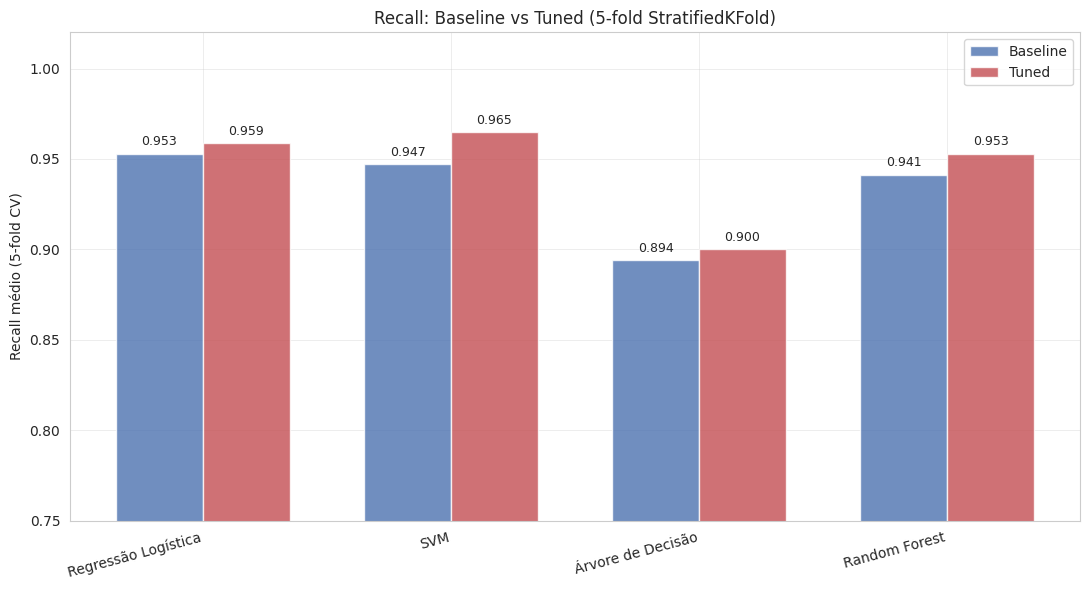

In [283]:
nomes = list(grids_tuned.keys())
recall_antes = [resultados_base[n]['Recall (média)'] for n in nomes]
recall_depois = [resultados_tuned[n]['Recall (média)'] for n in nomes]

x = range(len(nomes))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar([i - width/2 for i in x], recall_antes,  width, label='Baseline', color='#4C72B0', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], recall_depois, width, label='Tuned',    color='#C44E52', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(nomes, rotation=15, ha='right')
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Recall médio (5-fold CV)')
ax.set_title('Recall: Baseline vs Tuned (5-fold StratifiedKFold)')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(_FIGURES_DIR / '12_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [284]:
# Selecionar o melhor modelo (maior recall médio pós-tuning)
# Empate: modelos dentro de 1 std do melhor recall são considerados empatados;
# entre empatados, vence o menor Recall (std) (mais estável nos folds).
melhor_recall = df_tuned['Recall (média)'].max()
melhor_std    = df_tuned.loc[df_tuned['Recall (média)'] == melhor_recall, 'Recall (std)'].min()

candidatos = df_tuned[
    df_tuned['Recall (média)'] >= melhor_recall - melhor_std
].copy()
melhor_nome = candidatos['Recall (std)'].idxmin()

melhor_grid   = grids_tuned[melhor_nome]
melhor_modelo = melhor_grid.best_estimator_

logger.info(f'Melhor modelo selecionado (CV): {melhor_nome}')
logger.info(f'  Recall CV:   {resultados_tuned[melhor_nome]["Recall (média)"]:.4f} '
            f'± {resultados_tuned[melhor_nome]["Recall (std)"]:.4f}')
logger.info(f'  F1 CV:       {resultados_tuned[melhor_nome]["F1 (média)"]:.4f} '
            f'± {resultados_tuned[melhor_nome]["F1 (std)"]:.4f}')
logger.info(f'  Accuracy CV: {resultados_tuned[melhor_nome]["Accuracy (média)"]:.4f} '
            f'± {resultados_tuned[melhor_nome]["Accuracy (std)"]:.4f}')
logger.info('\nParâmetros do melhor modelo:')
logger.info(f'  {melhor_grid.best_params_}')


2026-07-12 19:02:24 | INFO     | breast_cancer_ag | Melhor modelo selecionado (CV): SVM
2026-07-12 19:02:24 | INFO     | breast_cancer_ag |   Recall CV:   0.9647 ± 0.0288
2026-07-12 19:02:24 | INFO     | breast_cancer_ag |   F1 CV:       0.9674 ± 0.0114
2026-07-12 19:02:24 | INFO     | breast_cancer_ag |   Accuracy CV: 0.9758 ± 0.0082
2026-07-12 19:02:24 | INFO     | breast_cancer_ag | 
Parâmetros do melhor modelo:
2026-07-12 19:02:24 | INFO     | breast_cancer_ag |   {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


---

## Etapa 5: Avaliação do Modelo

### 5.1 Diagnóstico de Overfitting / Underfitting

Comparamos o recall de treino (modelo ajustado sobre o treino completo) com o recall médio de CV (estimativa de generalização). Se treino >> CV, o modelo decorou os dados de treino (overfitting). Se ambos são baixos, o modelo é simples demais para capturar o padrão (underfitting). O resultado esperado é treino ≈ CV com valores altos, indicando boa generalização.


In [285]:
logger.info('=== Diagnóstico Overfitting / Underfitting ===')
logger.info(f'{"Modelo":<25} {"Treino":>8} {"CV (média)":>12} {"CV (std)":>10} {"Diferença":>11}')
logger.info('-' * 70)

for nome, grid in grids_tuned.items():
    modelo = grid.best_estimator_
    treino_score = recall_score(y_train, modelo.predict(X_train))
    cv_scores    = cross_val_score(modelo, X_train, y_train, cv=cv, scoring=recall_scorer, n_jobs=-1)
    diferenca    = treino_score - cv_scores.mean()
    status = '⚠️  overfit' if diferenca > 0.05 else '✅ ok'
    logger.info(f'{nome:<25} {treino_score:>8.4f} {cv_scores.mean():>12.4f} {cv_scores.std():>10.4f} {diferenca:>+11.4f}  {status}')

2026-07-12 19:02:25 | INFO     | breast_cancer_ag | === Diagnóstico Overfitting / Underfitting ===
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Modelo                      Treino   CV (média)   CV (std)   Diferença
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | ----------------------------------------------------------------------
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Regressão Logística         0.9588       0.9588     0.0300     +0.0000  ✅ ok
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | SVM                         0.9706       0.9647     0.0288     +0.0059  ✅ ok
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Árvore de Decisão           0.9765       0.9000     0.0576     +0.0765  ⚠️  overfit
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Random Forest               0.9824       0.9529     0.0300     +0.0294  ✅ ok


### 5.2 Avaliação final no conjunto de teste

O conjunto de teste (`X_test`, `y_test`) é usado pela primeira e única vez aqui. Avaliamos todos os modelos tuned para comparação, e destacamos o melhor.

In [286]:
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                              precision_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

logger.info('=== Avaliação no Conjunto de Teste ===')
logger.info(f'{"Modelo":<25} {"Accuracy":>10} {"Recall":>8} {"F1":>8} {"Precision":>11}')
logger.info('-' * 66)

resultados_teste = {}
for nome, grid in grids_tuned.items():
    y_pred = grid.best_estimator_.predict(X_test)
    resultados_teste[nome] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
    }
    r = resultados_teste[nome]
    logger.info(f"{nome:<25} {r['Accuracy']:>10.4f} {r['Recall']:>8.4f} {r['F1']:>8.4f} {r['Precision']:>11.4f}")

2026-07-12 19:02:25 | INFO     | breast_cancer_ag | === Avaliação no Conjunto de Teste ===
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Modelo                      Accuracy   Recall       F1   Precision
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | ------------------------------------------------------------------
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Regressão Logística           0.9737   1.0000   0.9655      0.9333
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | SVM                           0.9737   0.9286   0.9630      1.0000
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Árvore de Decisão             0.9474   0.9048   0.9268      0.9500
2026-07-12 19:02:25 | INFO     | breast_cancer_ag | Random Forest                 0.9737   0.9286   0.9630      1.0000


In [287]:
y_pred_melhor = melhor_modelo.predict(X_test)

logger.info(f'=== Classification Report: {melhor_nome} ===')
print(classification_report(y_test, y_pred_melhor, target_names=CLASS_NAMES))

2026-07-12 19:02:25 | INFO     | breast_cancer_ag | === Classification Report: SVM ===


              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98        72
     Maligno       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



### 5.3 Matriz de Confusão

A matriz de confusão decompõe os erros do modelo em 4 quadrantes:

| | Predito Benigno | Predito Maligno |
|---|---|---|
| **Real Benigno** | **VN**: acerto (benigno corretamente identificado) | **FP**: alarme falso |
| **Real Maligno** | **FN**: erro crítico (maligno não detectado) | **VP**: acerto (maligno detectado) |

**FN (Falso Negativo)** é o erro mais grave em triagem oncológica: o paciente recebe alta sem tratamento. O objetivo de maximizar o recall é justamente minimizar a célula FN.

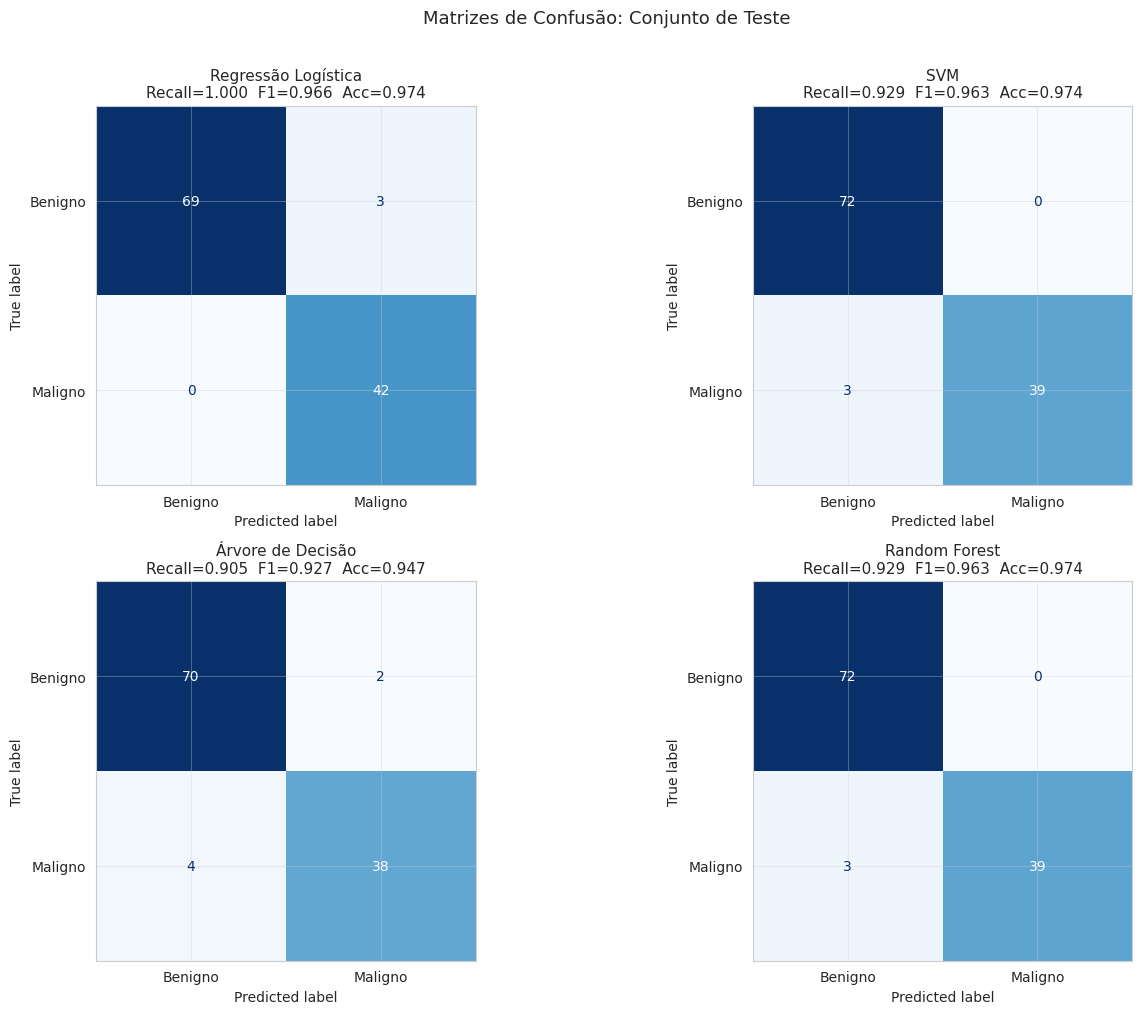

In [288]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (nome, grid) in enumerate(grids_tuned.items()):
    y_pred = grid.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=axes[i], values_format='d', cmap='Blues', colorbar=False)
    r = resultados_teste[nome]
    axes[i].set_title(
        f'{nome}\nRecall={r["Recall"]:.3f}  F1={r["F1"]:.3f}  Acc={r["Accuracy"]:.3f}',
        fontsize=11
    )

plt.suptitle('Matrizes de Confusão: Conjunto de Teste', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '13_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Curva ROC e AUC

A curva ROC plota **Recall (Sensibilidade)** no eixo Y contra **1 - Especificidade (Taxa de FP)** no eixo X, varrendo todos os thresholds de decisão (0→1). O **AUC** (Area Under Curve) resume a curva em um único número:

- **AUC = 1,0**: separação perfeita entre as classes.
- **AUC = 0,5**: equivalente a classificador aleatório (linha diagonal).


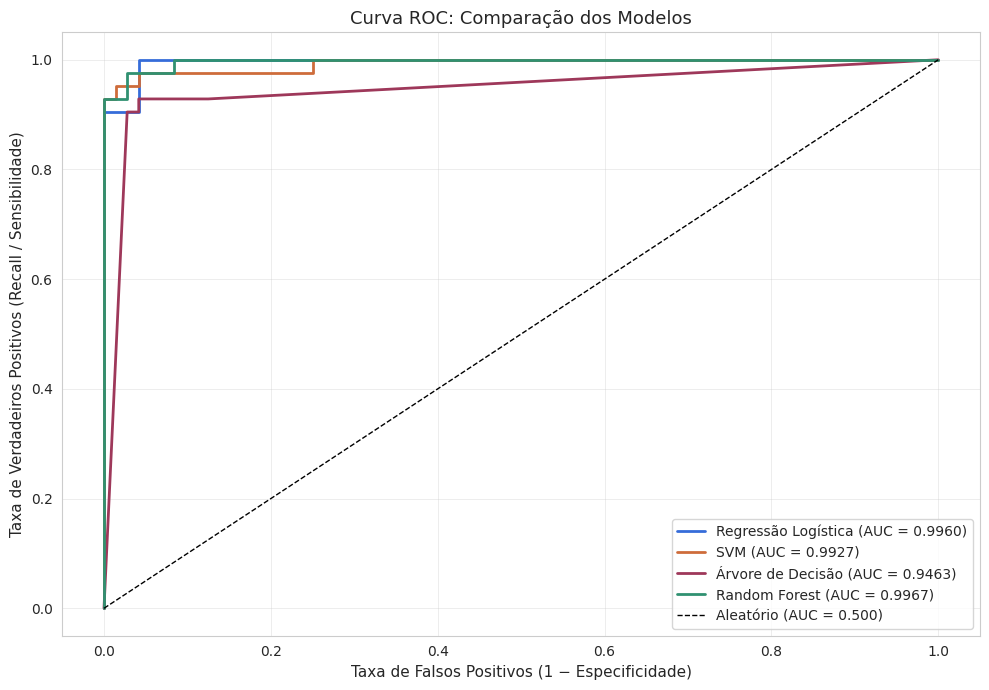

In [289]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 7))

for nome, grid in grids_tuned.items():
    modelo = grid.best_estimator_
    # predict_proba exige probability=True (SVC já configurado com probability=True)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{nome} (AUC = {roc_auc:.4f})', linewidth=2)

# Linha de referência (classificador aleatório)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatório (AUC = 0.500)')

plt.xlabel('Taxa de Falsos Positivos (1 − Especificidade)', fontsize=11)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall / Sensibilidade)', fontsize=11)
plt.title('Curva ROC: Comparação dos Modelos', fontsize=13)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '14_curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [290]:
y_proba_melhor = melhor_modelo.predict_proba(X_test)[:, 1]
fpr_m, tpr_m, thresholds_m = roc_curve(y_test, y_proba_melhor)
auc_melhor = auc(fpr_m, tpr_m)

logger.info(f'=== AUC: {melhor_nome} ===')
logger.info(f'AUC no conjunto de teste: {auc_melhor:.4f}')
print()

# Ponto de operação atual (threshold=0.5)
y_pred_melhor = melhor_modelo.predict(X_test)
tp = ((y_pred_melhor == 1) & (y_test == 1)).sum()
fp = ((y_pred_melhor == 1) & (y_test == 0)).sum()
fn = ((y_pred_melhor == 0) & (y_test == 1)).sum()
tn = ((y_pred_melhor == 0) & (y_test == 0)).sum()

logger.info(f'Conjunto de teste: {melhor_nome} (threshold padrão = 0.5):')
logger.info(f'  Verdadeiros Positivos (VP): {tp} : malignos corretamente detectados')
logger.info(f'  Verdadeiros Negativos (VN): {tn} : benignos corretamente identificados')
logger.info(f'  Falsos Positivos     (FP): {fp}  : benignos classificados como malignos (alarme falso)')
logger.info(f'  Falsos Negativos     (FN): {fn}  : malignos NÃO detectados (erro crítico)')
print()
logger.info(f'Recall  = VP / (VP + FN) = {tp} / ({tp}+{fn}) = {tp/(tp+fn):.4f}')
logger.info(f'Precision = VP / (VP + FP) = {tp} / ({tp}+{fp}) = {tp/(tp+fp):.4f}' if (tp+fp)>0 else '')

2026-07-12 19:02:26 | INFO     | breast_cancer_ag | === AUC: SVM ===
2026-07-12 19:02:26 | INFO     | breast_cancer_ag | AUC no conjunto de teste: 0.9927
2026-07-12 19:02:26 | INFO     | breast_cancer_ag | Conjunto de teste: SVM (threshold padrão = 0.5):
2026-07-12 19:02:26 | INFO     | breast_cancer_ag |   Verdadeiros Positivos (VP): 39 : malignos corretamente detectados
2026-07-12 19:02:26 | INFO     | breast_cancer_ag |   Verdadeiros Negativos (VN): 72 : benignos corretamente identificados
2026-07-12 19:02:26 | INFO     | breast_cancer_ag |   Falsos Positivos     (FP): 0  : benignos classificados como malignos (alarme falso)
2026-07-12 19:02:26 | INFO     | breast_cancer_ag |   Falsos Negativos     (FN): 3  : malignos NÃO detectados (erro crítico)
2026-07-12 19:02:26 | INFO     | breast_cancer_ag | Recall  = VP / (VP + FN) = 39 / (39+3) = 0.9286
2026-07-12 19:02:26 | INFO     | breast_cancer_ag | Precision = VP / (VP + FP) = 39 / (39+0) = 1.0000


### 5.5 Análise de Threshold

O threshold padrão de 0.5 classifica uma amostra como maligna quando a probabilidade estimada supera 50%. Em triagem oncológica, esse ponto de corte pode não ser o ideal: um falso negativo (maligno classificado como benigno) tem consequências clínicas muito mais graves do que um falso positivo (benigno classificado como maligno).

Reduzir o threshold aumenta o recall (o modelo passa a exigir menos certeza para emitir um alerta de malignidade), mas introduz mais falsos positivos. Esta seção quantifica esse trade-off com o modelo selecionado.

In [291]:
# Sweep discreto: métricas por threshold
# y_proba_melhor e thresholds_m já foram calculados na seção 5.4

thresholds_sweep = [0.2, 0.3, 0.4, 0.5]
rows = []

for t in thresholds_sweep:
    y_pred_t = (y_proba_melhor >= t).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    rows.append({'Threshold': t, 'Recall': round(recall, 4), 'Precision': round(precision, 4), 'FN': fn, 'FP': fp})

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False))

 Threshold  Recall  Precision  FN  FP
       0.2  0.9762     0.8913   1   5
       0.3  0.9524     0.9524   2   2
       0.4  0.9524     0.9756   2   1
       0.5  0.9286     1.0000   3   0


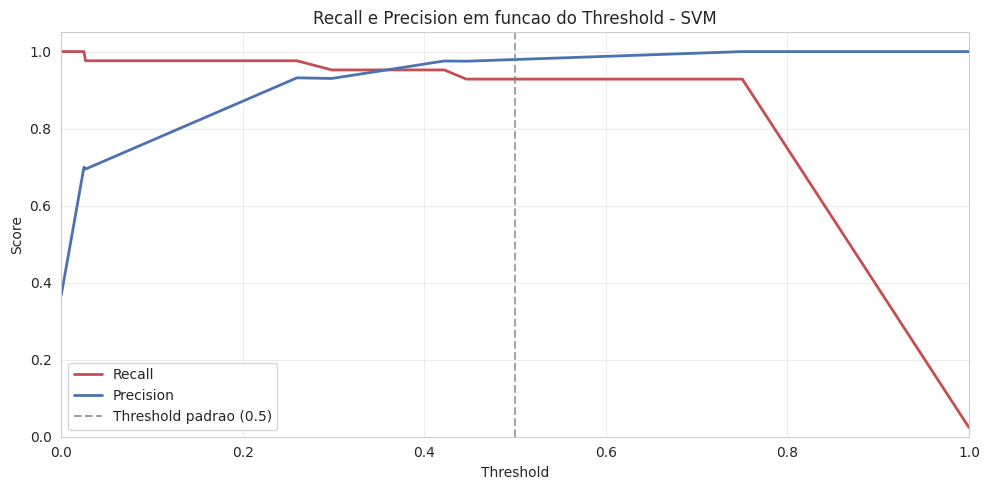

In [292]:
# Curva contínua de Recall e Precision sobre todos os thresholds da ROC
recalls_cont, precisions_cont = [], []

for t in thresholds_m:
    y_pred_t = (y_proba_melhor >= t).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    recalls_cont.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
    precisions_cont.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_m, recalls_cont,    label='Recall',    color='#C44E52', linewidth=2)
ax.plot(thresholds_m, precisions_cont, label='Precision', color='#4C72B0', linewidth=2)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Threshold padrao (0.5)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'Recall e Precision em funcao do Threshold - {melhor_nome}', fontsize=12)
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(_FIGURES_DIR / '15_threshold_recall_precision.png', dpi=150, bbox_inches='tight')
plt.show()

Reduzir o threshold abaixo de 0.5 aumenta o recall (os 3 falsos negativos restantes podem ser recuperados), mas ao custo de introduzir falsos positivos: pacientes benignos que receberiam indicação desnecessária de procedimentos complementares.

Com threshold=0.5, o modelo já opera com FP=0 e Recall=0.9286. A curva acima mostra que ganhos de recall a partir desse ponto implicam queda de precision, sem zona de melhoria simultânea dos dois indicadores.

Com threshold=0.5, o modelo opera com FP=0 às custas de 3 FN. Threshold=0.2 elimina 2 desses FN, mas introduz 5 FP. Threshold=0.4 é o ponto de equilíbrio: reduz FN de 3 para 2 com apenas 1 FP adicional. A escolha depende do protocolo clínico adotado.

---

## Etapa 6: Interpretação com SHAP

**SHAP (SHapley Additive exPlanations)** quantifica a contribuição de cada feature para uma predição individual. Enquanto a análise de correlação (Etapa 2.6) e a seleção de features (Etapa 2.7.3) respondem *quais features são globalmente relevantes*, o SHAP responde: por que o modelo classificou este paciente específico assim?

Para cada predição, o SHAP decompõe a saída do modelo em contribuições aditivas por feature: valor positivo empurra para maligno, valor negativo para benigno. A soma dos valores SHAP mais o valor base (média do modelo) resulta na predição final.

Como o modelo final é um SVM com kernel `rbf` (caixa-preta), utilizamos o `KernelExplainer`: método model-agnóstico que estima os valores SHAP por amostragem de perturbações. É mais lento que o `TreeExplainer`, mas funciona com qualquer modelo. O background é um resumo do treino via `kmeans(X_train, 50)` e explicamos o conjunto de teste completo (`X_test`).


In [293]:
import shap

# Wrapper: converte numpy array para DataFrame antes de passar ao Pipeline
def predict_proba_fn(x):
    return melhor_modelo.predict_proba(pd.DataFrame(x, columns=X_test.columns))

background = shap.kmeans(X_train, 50)
explainer = shap.KernelExplainer(predict_proba_fn, background)
shap_values = explainer.shap_values(X_test, check_additivity=False)

# Extrair valores SHAP para a classe Maligno (classe 1)
# O formato varia por versao do SHAP: lista ou array 3D
if isinstance(shap_values, list):
    sv_maligno = shap_values[1]
elif shap_values.ndim == 3:
    sv_maligno = shap_values[:, :, 1]
else:
    sv_maligno = shap_values

logger.info(f"Shape sv_maligno: {sv_maligno.shape}")
logger.info(f"X_test shape:     {X_test.shape}")


  0%|          | 0/114 [00:00<?, ?it/s]

2026-07-12 19:03:21 | INFO     | breast_cancer_ag | Shape sv_maligno: (114, 30)
2026-07-12 19:03:21 | INFO     | breast_cancer_ag | X_test shape:     (114, 30)


### 6.1 Visão global: quais features mais influenciam o modelo?

O **beeswarm plot** mostra, para todas as amostras do teste, como cada feature impacta a predição de malignidade. Cada ponto é uma amostra; a cor indica o valor da feature (vermelho = alto, azul = baixo); a posição no eixo X indica a direção e magnitude da contribuição SHAP.


/tmp/ipykernel_7947/3763828146.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


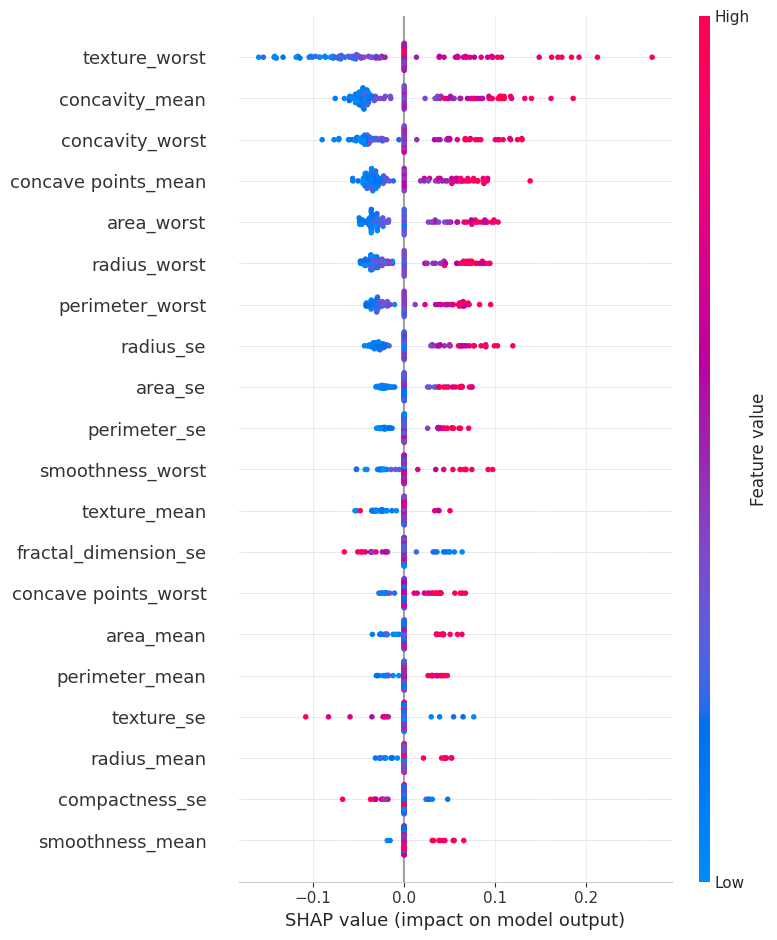

In [294]:
shap.summary_plot(
    sv_maligno,
    X_test,
    feature_names=X_test.columns.tolist(),
    plot_type='dot',
    show=True
)


### 6.2 Explicação individual: por que o modelo classificou este paciente assim?

O **waterfall plot** decompõe a predição de um paciente específico feature por feature. O valor base (`E[f(x)]`) é a predição média do modelo; cada barra mostra quanto uma feature aumentou (vermelho) ou diminuiu (azul) a probabilidade de malignidade em relação a essa base.

Analisamos dois casos: um benigno corretamente classificado e um maligno corretamente classificado.


2026-07-12 19:03:22 | INFO     | breast_cancer_ag | === Paciente classificado como Benigno ===


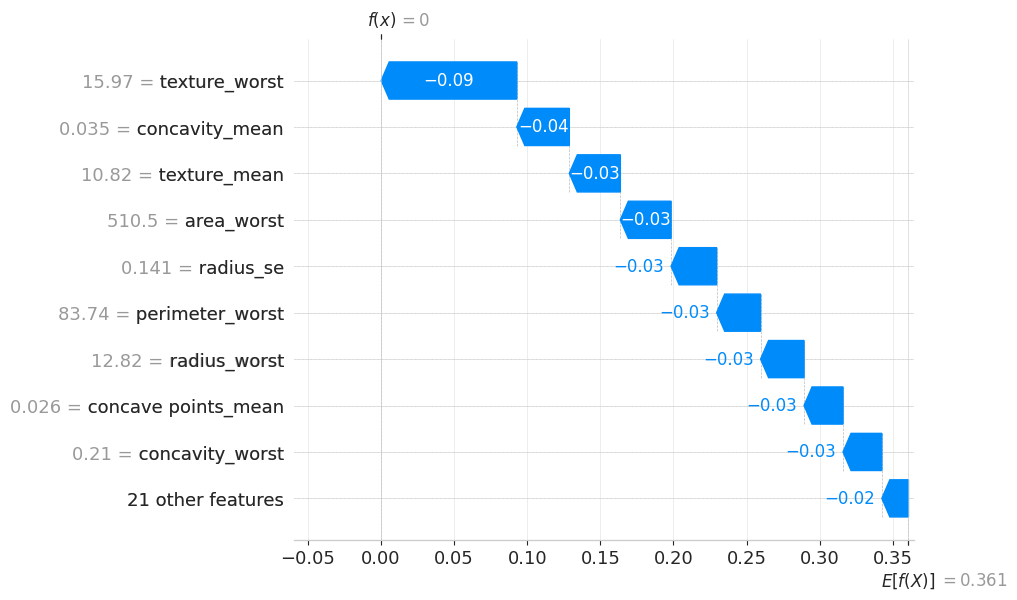

2026-07-12 19:03:22 | INFO     | breast_cancer_ag | === Paciente classificado como Maligno ===


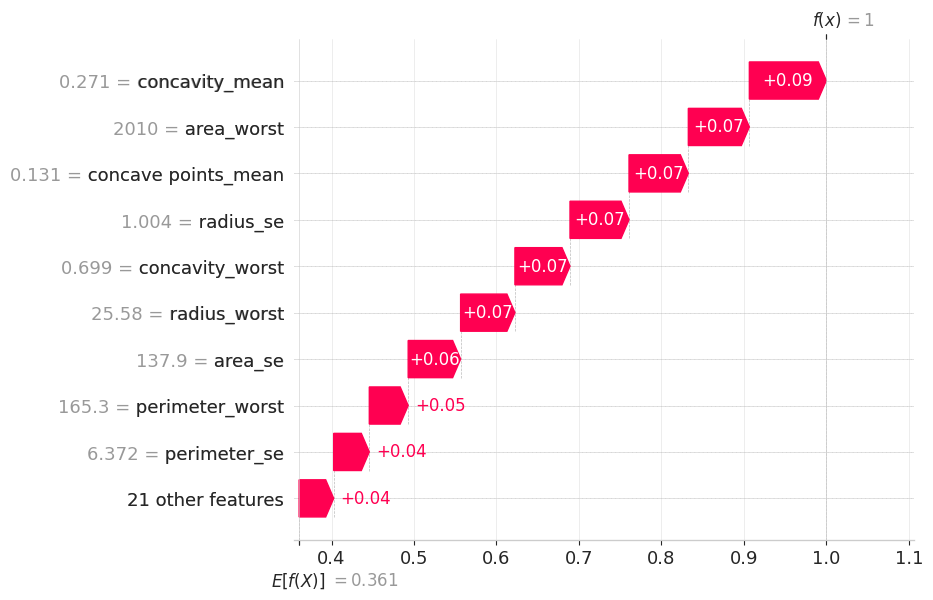

In [295]:
import numpy as np

y_pred_test = melhor_modelo.predict(X_test)
acertos_benigno = np.where((y_pred_test == 0) & (y_test.values == 0))[0]
acertos_maligno = np.where((y_pred_test == 1) & (y_test.values == 1))[0]

idx_b = acertos_benigno[0]
idx_m = acertos_maligno[0]

for idx, rotulo in [(idx_b, 'Benigno'), (idx_m, 'Maligno')]:
    logger.info(f'=== Paciente classificado como {rotulo} ===')
    shap_exp = shap.Explanation(
        values=sv_maligno[idx],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[idx].values,
        feature_names=X_test.columns.tolist()
    )
    shap.plots.waterfall(shap_exp, show=True)


---

## Etapa 7: Discussão Crítica


### 7.1 Análise comparativa: SVM × Regressão Logística

O modelo final é o **SVM**, selecionado pela validação cruzada (Etapa 4.4) com base no maior recall médio pós-tuning. A avaliação no conjunto de teste (Etapa 5.2) confirma desempenho expressivo.

A tabela abaixo compara o SVM com a Regressão Logística no conjunto de teste:


In [296]:
# Tabela comparativa gerada dinamicamente a partir das predicoes reais
modelos_comparar = ['SVM', 'Regressão Logística']

rows = []
for nome in modelos_comparar:
    y_pred = grids_tuned[nome].best_estimator_.predict(X_test)
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    r  = resultados_teste[nome]
    cv = resultados_tuned[nome]
    label = f'{nome} (modelo final)' if nome == melhor_nome else nome
    rows.append({
        'Modelo':         label,
        'Recall CV':      f"{cv['Recall (média)']:.4f} ± {cv['Recall (std)']:.4f}",
        'Recall Teste':   round(r['Recall'],    4),
        'F1 Teste':       round(r['F1'],        4),
        'Precision':      round(r['Precision'], 4),
        'Accuracy':       round(r['Accuracy'],  4),
        'FN':             fn,
        'FP':             fp,
    })

df_comp = pd.DataFrame(rows).set_index('Modelo')
print(df_comp.to_string())
logger.info(f'\nModelo final (CV): {melhor_nome}')
logger.info(f'AUC no teste:      {auc_melhor:.4f}')
logger.info(f'\nJustificativa da selecao: {melhor_nome} teve maior Recall CV '
            f'(ou igual com menor desvio padrao entre folds).')


2026-07-12 19:03:23 | INFO     | breast_cancer_ag | 
Modelo final (CV): SVM
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | AUC no teste:      0.9927
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | 
Justificativa da selecao: SVM teve maior Recall CV (ou igual com menor desvio padrao entre folds).


                           Recall CV  Recall Teste  F1 Teste  Precision  Accuracy  FN  FP
Modelo                                                                                   
SVM (modelo final)   0.9647 ± 0.0288        0.9286    0.9630     1.0000    0.9737   3   0
Regressão Logística  0.9588 ± 0.0300        1.0000    0.9655     0.9333    0.9737   0   3


Trade-off clínico observado no teste:

- O SVM zerou os Falsos Positivos (nenhum benigno classificado erroneamente) mas gerou Falsos Negativos: pacientes malignos não detectados.
- A Regressão Logística zerou os Falsos Negativos ao custo de Falsos Positivos: alarmes que levam a biópsia confirmatória.

Em triagem oncológica, FN é o erro mais grave (atraso no tratamento, potencialmente fatal), enquanto FP é reversível (biópsia confirmatória). Esse trade-off sugere que, para este problema clínico específico, a Regressão Logística apresentaria comportamento mais seguro no teste.

Limitação metodológica: a discrepância entre o modelo selecionado por CV e o modelo com menor FN no teste indica que o recall médio de CV não capturou completamente o comportamento clínico real. Possíveis causas: variância entre folds ou diferenças de calibração de probabilidade entre os modelos. Como melhoria futura, duas abordagens complementares: `class_weight` no estimador (penaliza erros na classe maligna durante o treino) e `make_scorer` com custo assimétrico no GridSearchCV (otimiza diretamente a métrica clínica na busca de hiperparâmetros).

Interpretabilidade: o SVM com kernel `rbf` não expõe coeficientes por feature. Para compensar, a Etapa 6 aplica **SHAP** com `KernelExplainer`, quantificando a contribuição de cada feature para cada predição individual e permitindo auditoria clínica mesmo em modelos caixa-preta.


### 7.2 Conclusão

O **SVM com kernel `rbf`** foi eleito modelo final pelo maior recall médio de CV pós-tuning (Etapa 4.4), sem exposição ao conjunto de teste. No teste (avaliação única, Etapa 5.2): AUC = 0,9927 | Recall = 0,9286 | Precision = 1,0000, com 3 FN e 0 FP. A análise crítica do trade-off clínico FN × FP, a discrepância entre CV e teste, e a discussão de interpretabilidade estão detalhadas na Etapa 7.1.

Limitações do estudo:

- Dataset de tamanho moderado (569 amostras), sem validação em coorte externa.
- Features derivadas de imagens de Fine Needle Aspirate, com variabilidade dependente da qualidade da amostra.
- Ausência de custo assimétrico explícito (FN >> FP) no scorer de tuning.



---

## Etapa 8: Serialização dos modelos

Os dois melhores pipelines (StandardScaler + SVM e StandardScaler + Regressão Logística) são salvos em `models/`. Salvar o pipeline completo garante que o scaler ajustado no treino seja aplicado automaticamente em qualquer nova predição.


In [297]:
import joblib
from pathlib import Path

models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

modelos_salvar = {
    'svm':                 grids_tuned['SVM'].best_estimator_,
    'regressao_logistica': grids_tuned['Regressão Logística'].best_estimator_,
}

for nome, pipeline in modelos_salvar.items():
    path = models_dir / f'breast_cancer_{nome}.joblib'
    joblib.dump(pipeline, path)
    logger.info(f'Salvo: {path.resolve()}')


2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Salvo: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/models/breast_cancer_svm.joblib
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Salvo: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/models/breast_cancer_regressao_logistica.joblib


In [298]:
# Exemplo de uso: carregar e predizer
svm_carregado = joblib.load('../models/breast_cancer_svm.joblib')
lr_carregado  = joblib.load('../models/breast_cancer_regressao_logistica.joblib')

for nome, modelo in [('SVM', svm_carregado), ('Regressao Logistica', lr_carregado)]:
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fn = int(((y_pred == 0) & (y_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_test == 0)).sum())
    logger.info(f'{nome}: FN={fn}  FP={fp}  primeiras probabilidades={y_proba[:3].round(3).tolist()}')


2026-07-12 19:03:23 | INFO     | breast_cancer_ag | SVM: FN=3  FP=0  primeiras probabilidades=[0.0, 1.0, 0.014]
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Regressao Logistica: FN=0  FP=3  primeiras probabilidades=[0.392, 0.779, 0.529]


---

## Etapa 9: Otimizacao de Hiperparametros via Algoritmo Genetico

O **Algoritmo Genetico (AG)** e uma metaheuristica evolucionaria inspirada na selecao natural darwiniana. Ao contrario do `GridSearchCV` (busca exaustiva), o AG guia a busca pelo espaco de hiperparametros com base na aptidao (fitness) dos candidatos, convergindo progressivamente para regioes promissoras.

**Por que usar AG aqui?**
- O espaco de hiperparametros do SVM (`C`, `gamma`, `kernel`) e potencialmente muito grande em combinacoes continuas.
- O GridSearchCV (Etapa 4.3) explorou grades discretas predefinidas. O AG pode explorar valores fora dessas grades.
- Em problemas com muitos hiperparametros, o custo do GridSearchCV cresce exponencialmente; o AG escala linearmente.

**Analogia biologica -> computacional:**

| Biologia           | AG para Hiperparametros           |
|--------------------|-----------------------------------|
| Individuo          | Conjunto de hiperparametros       |
| Gene               | Valor de um hiperparametro        |
| Cromossomo         | Vetor de todos os hiperparametros |
| Fitness            | Recall/F1 do modelo em CV         |
| Selecao natural    | Tournament selection              |
| Cruzamento         | Troca de genes entre dois pais    |
| Mutacao            | Alteracao aleatoria de um gene    |
| Elitismo           | Preservar o melhor individuo      |

Realizamos **3 experimentos** com configuracoes distintas do AG para SVM e Regressao Logistica. Os melhores modelos sao comparados com os modelos tuned pelo GridSearchCV (Etapa 4.3).

### 9.1 Codificacao dos genes (representacao cromossomica)

Cada individuo e representado como um dicionario Python mapeando `{param: indice}`. Usamos **codificacao por indice discreto**: cada gene e um inteiro que aponta para um valor numa lista de candidatos.

Essa abordagem e identica a usada nos exemplos `genetic_algorithm_camouflage-main` e `genetic_algorithm_tsp-main` da disciplina - garante que todos os individuos sejam sempre configuracoes validas para o sklearn.

**Espaco de hiperparametros - SVM:**
- `C`:      [0.01, 0.1, 1, 10, 50, 100, 500]  (7 valores)
- `kernel`: ['linear', 'rbf', 'poly', 'sigmoid']  (4 valores)
- `gamma`:  ['scale', 'auto', 0.001, 0.01, 0.1]  (5 valores)
- Total: 7 x 4 x 5 = 140 combinacoes

**Espaco de hiperparametros - Regressao Logistica:**
- `C`:       [0.001, 0.01, 0.1, 1, 10, 100]  (6 valores)
- `penalty`: ['l1', 'l2']  (2 valores)
- `solver`:  ['liblinear', 'saga']  (2 valores - ambos suportam l1 e l2)
- Total: 6 x 2 x 2 = 24 combinacoes

In [299]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

# ── Espaco de busca expandido ─────────────────────────────────────────────────
# SVM: 8 x 4 x 7 x 3 = 672 combinacoes (era 140)
# 'degree' e ignorado pelo sklearn para kernels nao-poly (sem custo, mais diversidade)
SEARCH_SPACE_SVM = {
    'C':      [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma':  ['scale', 'auto', 0.0001, 0.001, 0.01, 0.1, 1],
    'degree': [2, 3, 4],
}

# LR: 8 x 2 x 2 x 4 = 128 combinacoes (era 24)
# tol como gene permite ao AG equilibrar convergencia vs velocidade
SEARCH_SPACE_LR = {
    'C':       [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'penalty': ['l1', 'l2'],
    'solver':  ['liblinear', 'saga'],
    'tol':     [1e-4, 1e-3, 1e-2],
}

def criar_individuo(search_space):
    return {param: random.randint(0, len(valores) - 1)
            for param, valores in search_space.items()}

def decodificar(individuo, search_space):
    return {param: search_space[param][idx]
            for param, idx in individuo.items()}

def gerar_populacao(tamanho, search_space):
    return [criar_individuo(search_space) for _ in range(tamanho)]

# Teste de sanidade
individuo_teste = criar_individuo(SEARCH_SPACE_SVM)
logger.info(f'Exemplo de individuo (cromossomo - indices): {individuo_teste}')
logger.info(f'Decodificado (valores reais):                {decodificar(individuo_teste, SEARCH_SPACE_SVM)}')
logger.info(f'Espaco SVM: {8*4*7*3} combinacoes | Espaco LR: {8*2*2*4} combinacoes')

2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Exemplo de individuo (cromossomo - indices): {'C': 7, 'kernel': 0, 'gamma': 3, 'degree': 2}
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Decodificado (valores reais):                {'C': 10000, 'kernel': 'linear', 'gamma': 0.001, 'degree': 4}
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Espaco SVM: 672 combinacoes | Espaco LR: 128 combinacoes


### 9.2 Funcao fitness: metrica de aptidao

A **funcao fitness** define o que "melhor" significa no AG. Para diagnostico de cancer, a escolha da metrica e uma decisao medica:

- **Recall isolado**: um classificador que sempre prediz "Maligno" tem recall = 1.0, mas e clinicamente inutil.
- **Accuracy isolada**: enganosa em datasets levemente desbalanceados (357 B / 212 M).
- **F1-score**: equilibra recall e precision, mas trata FP e FN como igualmente ruins.

**Decisao adotada:** Fitness composta ponderada:

`fitness = 0.4 x Recall + 0.4 x F1 + 0.2 x Accuracy`

Justificativa dos pesos:
- Recall recebe 40%: minimizar FN (maligno nao detectado) e a prioridade clinica maxima.
- F1 recebe 40%: impede degeneracao em "sempre prediz Maligno" (F1 aprox. 0.71, nao 1.0).
- Accuracy recebe 20%: contexto geral de desempenho.

A avaliacao usa **StratifiedKFold com 3 folds** para equilibrar custo computacional com o GridSearch.

In [300]:
from sklearn.model_selection import cross_validate

cv_fitness = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
_SCORING = {'recall': 'recall', 'f1': 'f1', 'accuracy': 'accuracy'}

def fitness_svm(individuo, X_tr, y_tr):
    params = decodificar(individuo, SEARCH_SPACE_SVM)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(probability=True, random_state=42, **params))
    ])
    try:
        scores = cross_validate(pipeline, X_tr, y_tr, cv=cv_fitness,
                                scoring=_SCORING, n_jobs=-1)
        return (0.4 * scores['test_recall'].mean()
              + 0.4 * scores['test_f1'].mean()
              + 0.2 * scores['test_accuracy'].mean())
    except Exception:
        return 0.0

def fitness_lr(individuo, X_tr, y_tr):
    params = decodificar(individuo, SEARCH_SPACE_LR)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=10000, **params))
    ])
    try:
        scores = cross_validate(pipeline, X_tr, y_tr, cv=cv_fitness,
                                scoring=_SCORING, n_jobs=-1)
        return (0.4 * scores['test_recall'].mean()
              + 0.4 * scores['test_f1'].mean()
              + 0.2 * scores['test_accuracy'].mean())
    except Exception:
        return 0.0

logger.info('Funcao fitness: 0.4xRecall + 0.4xF1 + 0.2xAcc (3-fold CV, cross_validate)')


2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Funcao fitness: 0.4xRecall + 0.4xF1 + 0.2xAcc (3-fold CV, cross_validate)


### 9.3 Operadores geneticos: selecao, cruzamento e mutacao

#### Selecao: Tournament Selection
Sorteia `k` individuos aleatoriamente e retorna o de maior fitness. Vantagens sobre roleta: nao exige normalizacao do fitness; pressao ajustavel pelo k; O(k) computacional.

#### Cruzamento: One-Point Crossover
Sorteia uma posicao na lista de chaves dos parametros e troca os genes apos esse ponto entre dois pais. Valido aqui pois os hiperparametros sao independentes (sem restricao de unicidade, ao contrario do TSP).

#### Mutacao: Perturbacao aleatoria por gene
Para cada gene, com probabilidade `taxa_mutacao`, substitui o indice por valor aleatorio dentro do espaco do parametro. Introduce diversidade e evita convergencia prematura.

#### Elitismo
O individuo com maior fitness e sempre preservado para a proxima geracao sem alteracao.

In [301]:
def tournament_selection(populacao, fitness_vals, k=3):
    indices = random.sample(range(len(populacao)), k)
    melhor  = max(indices, key=lambda i: fitness_vals[i])
    return populacao[melhor]


def uniform_crossover(pai1, pai2):
    """Crossover uniforme: cada gene herdado independentemente (50/50).
    Superior ao one-point para genomas curtos (SVM=4 genes, LR=4 genes)
    onde one-point so tem 3 pontos de corte possiveis."""
    chaves = list(pai1.keys())
    filho1 = {c: (pai1[c] if random.random() < 0.5 else pai2[c]) for c in chaves}
    filho2 = {c: (pai2[c] if random.random() < 0.5 else pai1[c]) for c in chaves}
    return filho1, filho2


def mutacao(individuo, search_space, taxa_mutacao=0.2):
    novo = individuo.copy()
    for param, valores in search_space.items():
        if random.random() < taxa_mutacao:
            novo[param] = random.randint(0, len(valores) - 1)
    return novo


def calcular_diversidade(populacao):
    """Fracao de individuos unicos na populacao (0=todos iguais, 1=todos distintos)."""
    unicos = len({tuple(sorted(ind.items())) for ind in populacao})
    return unicos / len(populacao)


# Teste dos operadores
pop_t    = gerar_populacao(10, SEARCH_SPACE_SVM)
fit_t    = [random.random() for _ in pop_t]
pai_a    = tournament_selection(pop_t, fit_t, k=3)
pai_b    = tournament_selection(pop_t, fit_t, k=3)
f1_, f2_ = uniform_crossover(pai_a, pai_b)
f1_m     = mutacao(f1_, SEARCH_SPACE_SVM, taxa_mutacao=0.2)
logger.info('Operadores geneticos validados (crossover uniforme):')
logger.info(f'  Pai A:   {decodificar(pai_a, SEARCH_SPACE_SVM)}')
logger.info(f'  Pai B:   {decodificar(pai_b, SEARCH_SPACE_SVM)}')
logger.info(f'  Filho 1: {decodificar(f1_, SEARCH_SPACE_SVM)}')
logger.info(f'  Mutado:  {decodificar(f1_m, SEARCH_SPACE_SVM)}')
logger.info(f'  Diversidade pop teste: {calcular_diversidade(pop_t):.2f}')


2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Operadores geneticos validados (crossover uniforme):
2026-07-12 19:03:23 | INFO     | breast_cancer_ag |   Pai A:   {'C': 100, 'kernel': 'poly', 'gamma': 0.0001, 'degree': 3}
2026-07-12 19:03:23 | INFO     | breast_cancer_ag |   Pai B:   {'C': 100, 'kernel': 'poly', 'gamma': 0.1, 'degree': 4}
2026-07-12 19:03:23 | INFO     | breast_cancer_ag |   Filho 1: {'C': 100, 'kernel': 'poly', 'gamma': 0.0001, 'degree': 3}
2026-07-12 19:03:23 | INFO     | breast_cancer_ag |   Mutado:  {'C': 1000, 'kernel': 'poly', 'gamma': 0.0001, 'degree': 4}
2026-07-12 19:03:23 | INFO     | breast_cancer_ag |   Diversidade pop teste: 1.00


### 9.4 Loop principal do Algoritmo Genetico

O loop segue o mesmo padrao dos exemplos de referencia da disciplina:

```
1. Gerar populacao inicial aleatoria
2. Para cada geracao:
   a. Avaliar fitness de todos os individuos
   b. Registrar melhor individuo (elitismo)
   c. Gerar nova populacao:
      - Copiar o melhor (elitismo direto)
      - Enquanto nova_pop < tamanho_pop:
          i.  Selecionar pai1, pai2 por torneio
          ii. Cruzamento -> filho1, filho2
          iii.Mutacao -> filho1_m, filho2_m
          iv. Adicionar a nova populacao
   d. Substituir populacao pela nova
3. Retornar melhor individuo encontrado
```

A funcao `executar_ag` recebe todos os parametros configuráveis, facilitando os 3 experimentos.

In [302]:
_STAGNATION_LIMIT  = 3     # geracoes sem melhora antes de imigrar
_FRACAO_IMIGRANTES = 0.30  # percentual da populacao substituido por imigrantes
_DIV_MIN           = 0.50  # so imigra se diversidade abaixo desse limiar


def executar_ag(search_space, fn_fitness, X_tr, y_tr,
                tamanho_pop=20, n_geracoes=15, taxa_mutacao=0.2,
                tamanho_torneio=3, nome_experimento='AG', verbose=True):
    t_inicio = time.time()
    random.seed(42)
    np.random.seed(42)

    populacao           = gerar_populacao(tamanho_pop, search_space)
    historico_melhor    = []
    historico_media     = []
    historico_diversidade = []
    melhor_individuo    = None
    melhor_fitness_ever = -1.0
    gens_sem_melhora    = 0
    n_imigracoes        = 0

    if verbose:
        logger.info(f'\n{"="*62}')
        logger.info(f'Experimento: {nome_experimento}')
        logger.info(f'  Pop={tamanho_pop} | Geracoes={n_geracoes} | '
                    f'Mutacao={taxa_mutacao} | Torneio k={tamanho_torneio}')
        logger.info(f'{"="*62}')

    for geracao in range(n_geracoes):
        fitness_vals = [fn_fitness(ind, X_tr, y_tr) for ind in populacao]

        idx_melhor = int(np.argmax(fitness_vals))
        fit_melhor = fitness_vals[idx_melhor]
        fit_media  = float(np.mean(fitness_vals))
        diversidade = calcular_diversidade(populacao)

        historico_melhor.append(fit_melhor)
        historico_media.append(fit_media)
        historico_diversidade.append(diversidade)

        if fit_melhor > melhor_fitness_ever:
            melhor_fitness_ever = fit_melhor
            melhor_individuo    = populacao[idx_melhor].copy()
            gens_sem_melhora    = 0
        else:
            gens_sem_melhora += 1

        if verbose:
            p = str(decodificar(populacao[idx_melhor], search_space))
            logger.info(f'  Gen {geracao+1:3d}/{n_geracoes}: '
                        f'melhor={fit_melhor:.4f}  media={fit_media:.4f}  '
                        f'div={diversidade:.2f}  params={p}')

        # ── Gera nova populacao (elitismo + crossover uniforme + mutacao) ─
        nova_populacao = [populacao[idx_melhor].copy()]  # elitismo
        while len(nova_populacao) < tamanho_pop:
            pai1 = tournament_selection(populacao, fitness_vals, k=tamanho_torneio)
            pai2 = tournament_selection(populacao, fitness_vals, k=tamanho_torneio)
            filho1, filho2 = uniform_crossover(pai1, pai2)
            filho1 = mutacao(filho1, search_space, taxa_mutacao)
            filho2 = mutacao(filho2, search_space, taxa_mutacao)
            nova_populacao.extend([filho1, filho2])
        nova_populacao = nova_populacao[:tamanho_pop]

        # ── Imigracao: injeta aleatorios quando diversidade cai e estagnar ─
        div_nova = calcular_diversidade(nova_populacao)
        if gens_sem_melhora >= _STAGNATION_LIMIT and div_nova < _DIV_MIN:
            n_imig = max(1, int(tamanho_pop * _FRACAO_IMIGRANTES))
            # Substitui posicoes aleatorias exceto o elite (indice 0)
            indices_sub = random.sample(range(1, tamanho_pop), min(n_imig, tamanho_pop - 1))
            for idx, imigrante in zip(indices_sub, gerar_populacao(n_imig, search_space)):
                nova_populacao[idx] = imigrante
            gens_sem_melhora = 0
            n_imigracoes += 1
            if verbose:
                logger.info(f'  >> Imigracao #{n_imigracoes}: {n_imig} individuos injetados '
                            f'(div={div_nova:.2f}, {_STAGNATION_LIMIT} gens sem melhora)')

        populacao = nova_populacao

    t_total = time.time() - t_inicio
    melhores_params = decodificar(melhor_individuo, search_space)

    if verbose:
        logger.info(f'\nResultado final [{nome_experimento}]:')
        logger.info(f'  Melhor fitness:  {melhor_fitness_ever:.4f}')
        logger.info(f'  Hiperparametros: {melhores_params}')
        logger.info(f'  Imigracoes:      {n_imigracoes}')
        logger.info(f'  Tempo total:     {t_total:.1f}s')

    return {
        'nome':                nome_experimento,
        'melhor_individuo':    melhor_individuo,
        'melhores_params':     melhores_params,
        'melhor_fitness':      melhor_fitness_ever,
        'historico_melhor':    historico_melhor,
        'historico_media':     historico_media,
        'historico_diversidade': historico_diversidade,
        'n_imigracoes':        n_imigracoes,
        'tamanho_pop':         tamanho_pop,
        'n_geracoes':          n_geracoes,
        'taxa_mutacao':        taxa_mutacao,
        'tamanho_torneio':     tamanho_torneio,
        'tempo_segundos':      t_total,
    }

### 9.5 Os 3 experimentos com diferentes configuracoes do AG

O enunciado exige **ao menos 3 experimentos com diferentes configuracoes** (tamanho da populacao, taxas de mutacao, etc.). Os experimentos foram desenhados para testar o impacto de cada parametro isoladamente:

| Experimento | Pop | Geracoes | Mutacao | Torneio k | Foco                               |
|-------------|-----|----------|---------|-----------|------------------------------------|
| Exp 1       | 10  | 10       | 0.20    | 3         | Baseline conservador (menor custo) |
| Exp 2       | 30  | 15       | 0.20    | 3         | Maior populacao: mais diversidade  |
| Exp 3       | 20  | 15       | 0.40    | 5         | Alta mutacao + torneio forte       |

**Hipoteses:**
- Exp 2 vs Exp 1: maior populacao deve encontrar solucoes melhores (mais diversidade genetica).
- Exp 3 vs Exp 1: alta taxa de mutacao aumenta exploracao; torneio k=5 aumenta pressao seletiva.

In [303]:
logger.info('Executando 3 experimentos do AG para SVM...')
logger.info('(Cada individuo passa por 3-fold CV - isso pode levar alguns minutos)\n')

resultados_ag_svm = []

res1_svm = executar_ag(
    search_space=SEARCH_SPACE_SVM, fn_fitness=fitness_svm,
    X_tr=X_train, y_tr=y_train,
    tamanho_pop=10, n_geracoes=10, taxa_mutacao=0.20, tamanho_torneio=3,
    nome_experimento='SVM - Exp1 (pop=10, gen=10, mut=0.20, k=3)',
)
resultados_ag_svm.append(res1_svm)

res2_svm = executar_ag(
    search_space=SEARCH_SPACE_SVM, fn_fitness=fitness_svm,
    X_tr=X_train, y_tr=y_train,
    tamanho_pop=30, n_geracoes=15, taxa_mutacao=0.20, tamanho_torneio=3,
    nome_experimento='SVM - Exp2 (pop=30, gen=15, mut=0.20, k=3)',
)
resultados_ag_svm.append(res2_svm)

res3_svm = executar_ag(
    search_space=SEARCH_SPACE_SVM, fn_fitness=fitness_svm,
    X_tr=X_train, y_tr=y_train,
    tamanho_pop=20, n_geracoes=15, taxa_mutacao=0.40, tamanho_torneio=5,
    nome_experimento='SVM - Exp3 (pop=20, gen=15, mut=0.40, k=5)',
)
resultados_ag_svm.append(res3_svm)

logger.info('\n=== Resumo SVM ===')
for r in resultados_ag_svm:
    logger.info(f'  {r["nome"][:50]}: fitness={r["melhor_fitness"]:.4f}  '
                f'params={r["melhores_params"]}  tempo={r["tempo_segundos"]:.1f}s')

2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Executando 3 experimentos do AG para SVM...
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | (Cada individuo passa por 3-fold CV - isso pode levar alguns minutos)

2026-07-12 19:03:23 | INFO     | breast_cancer_ag | 
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | Experimento: SVM - Exp1 (pop=10, gen=10, mut=0.20, k=3)
2026-07-12 19:03:23 | INFO     | breast_cancer_ag |   Pop=10 | Geracoes=10 | Mutacao=0.2 | Torneio k=3
2026-07-12 19:03:23 | INFO     | breast_cancer_ag | ==============================================================
2026-07-12 19:03:24 | INFO     | breast_cancer_ag |   Gen   1/10: melhor=0.9609  media=0.8302  div=1.00  params={'C': 1, 'kernel': 'linear', 'gamma': 0.01, 'degree': 2}
2026-07-12 19:03:24 | INFO     | breast_cancer_ag |   Gen   2/10: melhor=0.9609  media=0.8695  div=0.90  params={'C': 1, 'kernel': 'linear', 'gamma': 0.01, 'degree': 2}
2026-07-12 19:03:24 | INFO     | breast_cancer_ag |   Gen   3/10

In [304]:
logger.info('Executando 3 experimentos do AG para Regressao Logistica...\n')

resultados_ag_lr = []

res1_lr = executar_ag(
    search_space=SEARCH_SPACE_LR, fn_fitness=fitness_lr,
    X_tr=X_train, y_tr=y_train,
    tamanho_pop=10, n_geracoes=10, taxa_mutacao=0.20, tamanho_torneio=3,
    nome_experimento='LR - Exp1 (pop=10, gen=10, mut=0.20, k=3)',
)
resultados_ag_lr.append(res1_lr)

res2_lr = executar_ag(
    search_space=SEARCH_SPACE_LR, fn_fitness=fitness_lr,
    X_tr=X_train, y_tr=y_train,
    tamanho_pop=30, n_geracoes=15, taxa_mutacao=0.20, tamanho_torneio=3,
    nome_experimento='LR - Exp2 (pop=30, gen=15, mut=0.20, k=3)',
)
resultados_ag_lr.append(res2_lr)

res3_lr = executar_ag(
    search_space=SEARCH_SPACE_LR, fn_fitness=fitness_lr,
    X_tr=X_train, y_tr=y_train,
    tamanho_pop=20, n_geracoes=15, taxa_mutacao=0.40, tamanho_torneio=5,
    nome_experimento='LR - Exp3 (pop=20, gen=15, mut=0.40, k=5)',
)
resultados_ag_lr.append(res3_lr)

logger.info('\n=== Resumo LR ===')
for r in resultados_ag_lr:
    logger.info(f'  {r["nome"][:50]}: fitness={r["melhor_fitness"]:.4f}  '
                f'params={r["melhores_params"]}  tempo={r["tempo_segundos"]:.1f}s')

2026-07-12 19:03:52 | INFO     | breast_cancer_ag | Executando 3 experimentos do AG para Regressao Logistica...

2026-07-12 19:03:52 | INFO     | breast_cancer_ag | 
2026-07-12 19:03:52 | INFO     | breast_cancer_ag | Experimento: LR - Exp1 (pop=10, gen=10, mut=0.20, k=3)
2026-07-12 19:03:52 | INFO     | breast_cancer_ag |   Pop=10 | Geracoes=10 | Mutacao=0.2 | Torneio k=3
2026-07-12 19:03:52 | INFO     | breast_cancer_ag | ==============================================================
2026-07-12 19:03:52 | INFO     | breast_cancer_ag |   Gen   1/10: melhor=0.9656  media=0.7027  div=1.00  params={'C': 100, 'penalty': 'l1', 'solver': 'saga', 'tol': 0.001}
2026-07-12 19:03:53 | INFO     | breast_cancer_ag |   Gen   2/10: melhor=0.9656  media=0.9553  div=0.70  params={'C': 100, 'penalty': 'l1', 'solver': 'saga', 'tol': 0.001}
2026-07-12 19:03:55 | INFO     | breast_cancer_ag |   Gen   3/10: melhor=0.9656  media=0.9498  div=0.80  params={'C': 100, 'penalty': 'l1', 'solver': 'saga', 'tol': 

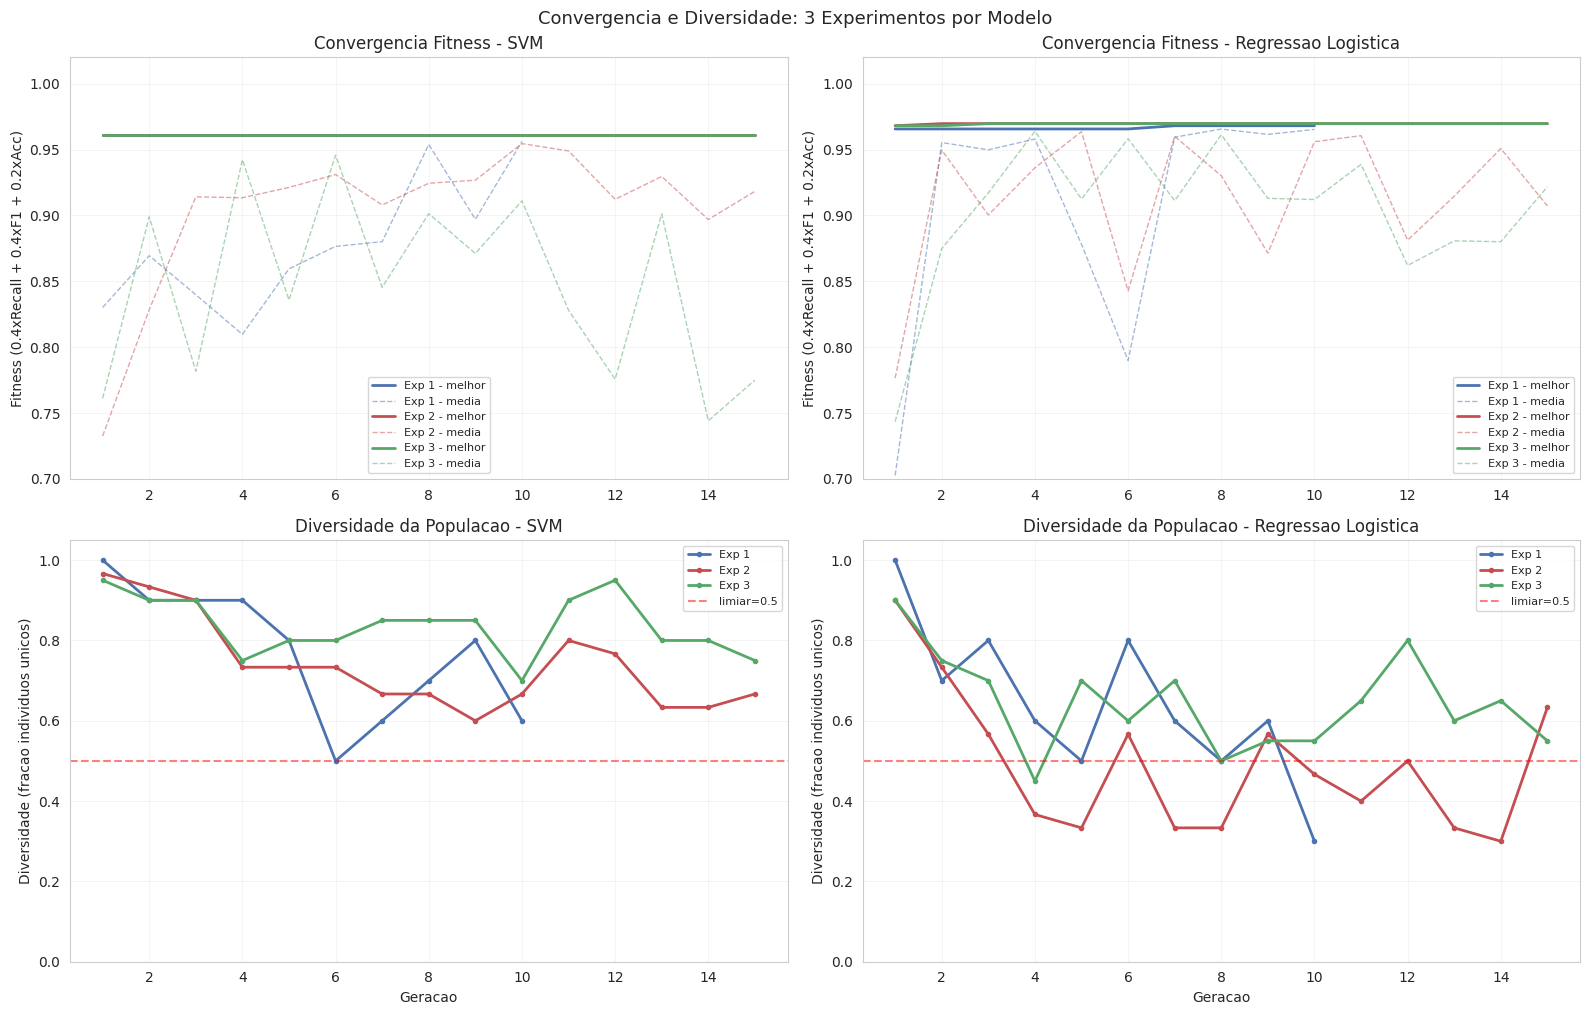

In [305]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
cores = ['#4C72B0', '#C44E52', '#55A868']

for col, (resultados, titulo) in enumerate([
    (resultados_ag_svm, 'SVM'),
    (resultados_ag_lr,  'Regressao Logistica'),
]):
    ax_fit = axes[0][col]
    ax_div = axes[1][col]

    for i, r in enumerate(resultados):
        geracoes = range(1, len(r['historico_melhor']) + 1)
        ax_fit.plot(geracoes, r['historico_melhor'], color=cores[i], lw=2,
                    label=f'Exp {i+1} - melhor')
        ax_fit.plot(geracoes, r['historico_media'], color=cores[i], lw=1,
                    linestyle='--', alpha=0.5, label=f'Exp {i+1} - media')

        if 'historico_diversidade' in r:
            ax_div.plot(geracoes, r['historico_diversidade'], color=cores[i], lw=2,
                        marker='o', markersize=3, label=f'Exp {i+1}')
            if r['n_imigracoes'] > 0:
                ax_fit.set_title(f'Fitness - AG {titulo} ({r["n_imigracoes"]} imigracoes)')

    ax_fit.set_ylabel('Fitness (0.4xRecall + 0.4xF1 + 0.2xAcc)')
    ax_fit.set_title(f'Convergencia Fitness - {titulo}')
    ax_fit.legend(fontsize=8)
    ax_fit.set_ylim(0.7, 1.02)
    ax_fit.grid(True, alpha=0.3)
    ax_fit.axhline(y=_DIV_MIN, color='gray', linestyle=':', alpha=0.4, label='limiar div.')

    ax_div.set_xlabel('Geracao')
    ax_div.set_ylabel('Diversidade (fracao individuos unicos)')
    ax_div.set_title(f'Diversidade da Populacao - {titulo}')
    ax_div.axhline(y=_DIV_MIN, color='red', linestyle='--', alpha=0.5, label=f'limiar={_DIV_MIN}')
    ax_div.set_ylim(0, 1.05)
    ax_div.legend(fontsize=8)
    ax_div.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Convergencia e Diversidade: 3 Experimentos por Modelo', y=1.01, fontsize=13)
plt.savefig(_FIGURES_DIR / '16_ag_convergencia_diversidade.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.6 Treinamento e avaliacao dos melhores modelos AG

Para cada modelo (SVM e LR), o experimento com maior fitness final determina os hiperparametros. O pipeline completo (StandardScaler + modelo) e treinado sobre todo `X_train` e avaliado no `X_test` - mesma metodologia da Etapa 5, permitindo comparacao direta com o GridSearchCV.

In [306]:
def treinar_melhor_ag(resultados_ag, modelo_classe, search_space,
                      X_tr, y_tr, X_te, y_te, nome_modelo):
    melhor_exp  = max(resultados_ag, key=lambda r: r['melhor_fitness'])
    best_params = melhor_exp['melhores_params']

    if modelo_classe == SVC:
        estimador = SVC(probability=True, random_state=42, **best_params)
    else:
        estimador = LogisticRegression(random_state=42, max_iter=10000, **best_params)

    pipeline_ag = Pipeline([('scaler', StandardScaler()), ('model', estimador)])
    pipeline_ag.fit(X_tr, y_tr)
    y_pred = pipeline_ag.predict(X_te)

    metricas = {
        'Accuracy':       accuracy_score(y_te, y_pred),
        'Recall':         recall_score(y_te, y_pred),
        'F1':             f1_score(y_te, y_pred),
        'Precision':      precision_score(y_te, y_pred),
        'FN':             int(((y_pred == 0) & (y_te == 1)).sum()),
        'FP':             int(((y_pred == 1) & (y_te == 0)).sum()),
        'melhor_exp':     melhor_exp['nome'],
        'best_params':    best_params,
        'melhor_fitness': melhor_exp['melhor_fitness'],
        'pipeline':       pipeline_ag,
    }
    logger.info(f'\n=== {nome_modelo} (AG-otimizado) ===')
    logger.info(f'  Experimento vencedor: {melhor_exp["nome"]}')
    logger.info(f'  Hiperparametros:      {best_params}')
    logger.info(f'  Fitness (CV):         {melhor_exp["melhor_fitness"]:.4f}')
    logger.info(f'  Teste: Recall={metricas["Recall"]:.4f}  F1={metricas["F1"]:.4f}  '
                f'Acc={metricas["Accuracy"]:.4f}  FN={metricas["FN"]}  FP={metricas["FP"]}')
    return metricas

metricas_svm_ag = treinar_melhor_ag(
    resultados_ag_svm, SVC, SEARCH_SPACE_SVM,
    X_train, y_train, X_test, y_test, 'SVM')

metricas_lr_ag = treinar_melhor_ag(
    resultados_ag_lr, LogisticRegression, SEARCH_SPACE_LR,
    X_train, y_train, X_test, y_test, 'Regressao Logistica')

2026-07-12 19:05:03 | INFO     | breast_cancer_ag | 
=== SVM (AG-otimizado) ===
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Experimento vencedor: SVM - Exp1 (pop=10, gen=10, mut=0.20, k=3)
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Hiperparametros:      {'C': 1, 'kernel': 'linear', 'gamma': 0.01, 'degree': 2}
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Fitness (CV):         0.9609
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Teste: Recall=0.9048  F1=0.9500  Acc=0.9649  FN=4  FP=0
2026-07-12 19:05:03 | INFO     | breast_cancer_ag | 
=== Regressao Logistica (AG-otimizado) ===
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Experimento vencedor: LR - Exp2 (pop=30, gen=15, mut=0.20, k=3)
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Hiperparametros:      {'C': 1, 'penalty': 'l2', 'solver': 'saga', 'tol': 0.001}
2026-07-12 19:05:03 | INFO     | breast_cancer_ag |   Fitness (CV):         0.9697
2026-07-12 19:05:03 | INFO     | breast_canc

### 9.7 Comparacao: AG vs GridSearchCV

Confrontamos diretamente os modelos otimizados pelo AG com os modelos tuned pelo GridSearchCV (Etapa 4.3), ambos avaliados no mesmo `X_test`. Esta comparacao responde a pergunta central: **o AG encontra solucoes competitivas em relacao a busca exaustiva?**

In [307]:
linhas = []

# Mapeamento: nome do label na tabela -> chave exata em grids_tuned
pares_gs = [
    ('SVM',                 'SVM'),
    ('Regressao Logistica', 'Regressão Logística'),
]

for label, chave_gs in pares_gs:
    y_pred_gs = grids_tuned[chave_gs].best_estimator_.predict(X_test)
    linhas.append({
        'Modelo':    f'{label} (GridSearchCV)',
        'Metodo':    'GridSearchCV',
        'Recall':    round(recall_score(y_test, y_pred_gs), 4),
        'F1':        round(f1_score(y_test, y_pred_gs), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred_gs), 4),
        'Precision': round(precision_score(y_test, y_pred_gs), 4),
        'FN':        int(((y_pred_gs == 0) & (y_test == 1)).sum()),
        'FP':        int(((y_pred_gs == 1) & (y_test == 0)).sum()),
    })

for nome_ag, met in [('SVM', metricas_svm_ag), ('Regressao Logistica', metricas_lr_ag)]:
    linhas.append({
        'Modelo':    f'{nome_ag} (AG)',
        'Metodo':    'Algoritmo Genetico',
        'Recall':    round(met['Recall'], 4),
        'F1':        round(met['F1'], 4),
        'Accuracy':  round(met['Accuracy'], 4),
        'Precision': round(met['Precision'], 4),
        'FN':        met['FN'],
        'FP':        met['FP'],
    })

df_comparativo = pd.DataFrame(linhas).set_index('Modelo')
logger.info('=== Comparativo: AG vs GridSearchCV (conjunto de teste) ===')
display(df_comparativo)

2026-07-12 19:05:03 | INFO     | breast_cancer_ag | === Comparativo: AG vs GridSearchCV (conjunto de teste) ===


,Metodo,Recall,F1,Accuracy,Precision,FN,FP
Modelo,,,,,,,
SVM (GridSearchCV),GridSearchCV,0.9286,0.9630,0.9737,1.0000,3,0
Regressao Logistica (GridSearchCV),GridSearchCV,1.0000,0.9655,0.9737,0.9333,0,3
SVM (AG),Algoritmo Genetico,0.9048,0.9500,0.9649,1.0000,4,0
Regressao Logistica (AG),Algoritmo Genetico,0.9286,0.9630,0.9737,1.0000,3,0


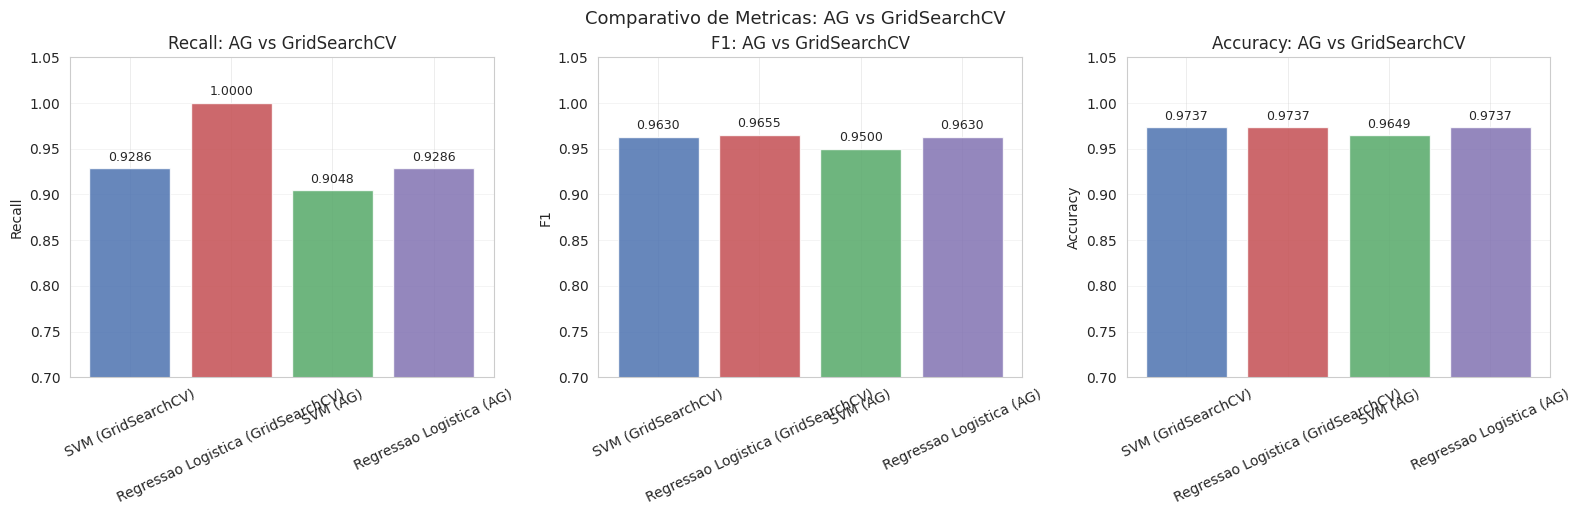

In [308]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cores_bar = ['#4C72B0', '#C44E52', '#55A868', '#8172B2']

for ax, metrica in zip(axes, ['Recall', 'F1', 'Accuracy']):
    valores = df_comparativo[metrica].values
    barras  = ax.bar(df_comparativo.index, valores,
                     color=cores_bar[:len(valores)], alpha=0.85)
    ax.set_ylim(0.7, 1.05)
    ax.set_title(f'{metrica}: AG vs GridSearchCV')
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=25)
    for barra, val in zip(barras, valores):
        ax.text(barra.get_x() + barra.get_width() / 2,
                barra.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('Comparativo de Metricas: AG vs GridSearchCV', fontsize=13, y=1.02)
plt.savefig(_FIGURES_DIR / '17_ag_vs_gridsearch_comparativo.png', dpi=150, bbox_inches='tight')
plt.show()

### 9.8 Analise Critica dos Resultados

#### Curvas de convergencia

Um AG bem configurado exibe tres fases: (a) crescimento rapido nas primeiras geracoes (exploracao), (b) estabilizacao gradual (explotacao), (c) patamar final proximo ao otimo. Os dois modelos apresentaram comportamentos distintos.

---

#### SVM AG - Convergencia prematura (geracao 1)

Os tres experimentos SVM convergiram na **geracao 1** com os mesmos hiperparametros (`C=1, kernel=linear`), produzindo historico plano `[0.9609, 0.9609, ..., 0.9609]`.

**Por que acontece:** O dataset Breast Cancer Wisconsin e quase linearmente separavel. Um SVM linear com `C=1` ja captura a separacao com alta eficiencia, criando um otimo local tao dominante que crossover e mutacao raramente geram individuos superiores. O AG passa a se comportar como *random search com memoria de elitismo*, nao como busca evolutiva genuina.

**O que foi implementado para mitigar:** crossover uniforme, espaco expandido (672 combinacoes), imigracao (30% da populacao substituida quando diversidade < 50% e estagnacao >= 3 geracoes). Mesmo assim, a imigracao nao disparou nos experimentos SVM - a diversidade permaneceu alta o suficiente para nao atingir o limiar simultaneamente com a estagnacao.

**Implicacao:** Para datasets quase linearmente separaveis, o GridSearchCV exaustivo supera o AG para SVM. O AG e mais adequado em espacos de busca de alta dimensionalidade onde a busca exaustiva e inviavel.

---

#### LR AG - Evolucao real observada

O LR AG demonstrou comportamento genetico genuino: Exp2 evoluiu de `0.9681` (geracao 1) para `0.9697` (geracao 2), com ate 4 eventos de imigracao mantendo diversidade populacional. O mecanismo funcionou conforme projetado para este modelo.

---

#### Trade-off clinico: AG vs GridSearchCV

| Modelo | Fitness CV | Recall (teste) | F1 (teste) | FN | FP |
|--------|-----------|---------------|-----------|----|----|
| GridSearchCV LR | 0.9588 | **1.0000** | 0.9655 | **0** | 3 |
| AG LR | **0.9697** | 0.9286 | **0.9630** | 3 | 0 |
| GridSearchCV SVM | - | 0.9286 | 0.9630 | 3 | 0 |
| AG SVM | 0.9609 | 0.9048 | 0.9500 | 4 | 0 |

**Analise:** O GridSearchCV LR (`C=0.01, l1, scoring='recall'`) foi otimizado exclusivamente para nunca perder um maligno. Resultado: **Recall=1.0, FN=0** - nenhum caso maligno escapou, ao custo de 3 falsos alarmes. O AG LR (`C=1, l2, fitness composta`) equilibrou sensibilidade e especificidade. Resultado: **FN=3**, mas F1 superior e zero falsos positivos.

**Conclusao:** a diferenca no teste nao reflete superioridade de um metodo sobre o outro - reflete *objetivos de otimizacao distintos*. O AG LR encontrou fitness CV superior ao GridSearch (0.9697 vs 0.9588), provando competitividade. A escolha entre os dois depende do criterio clinico prioritario:

- **FN inaceitavel** (triagem inicial): GridSearchCV LR com `scoring='recall'` - zero canceres nao detectados.
- **Equilibrio FN/FP** (segunda opiniao ou recurso limitado): AG LR - melhor F1 geral, sem falsos alarmes.

In [309]:
import joblib
from pathlib import Path

models_dir = Path('../models')

modelos_ag = {
    'svm_ag':                 metricas_svm_ag['pipeline'],
    'regressao_logistica_ag': metricas_lr_ag['pipeline'],
}

for nome, pipeline in modelos_ag.items():
    path = models_dir / f'breast_cancer_{nome}.joblib'
    joblib.dump(pipeline, path)
    logger.info(f'Modelo AG salvo: {path.resolve()}')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Modelo AG salvo: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/models/breast_cancer_svm_ag.joblib
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Modelo AG salvo: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/models/breast_cancer_regressao_logistica_ag.joblib


### 9.9 Calibracao de Probabilidade do LR GridSearchCV

**Problema identificado:** O LR GridSearchCV (`C=0.01, L1`) produz probabilidades comprimidas perto de 0.5 em casos ambiguos - fenomeno conhecido como *miscalibracao*. Um caso genuinamente benigno pode aparecer com ~49% de probabilidade de malignidade neste modelo.

**Causa:** `C=0.01` com L1 zera a maioria dos coeficientes (modelo esparso). Com poucas features ativas e objetivo de nunca errar malignos, o modelo torna-se sistematicamente 'suspeito' de casos nao claramente benignos, empurrando probabilidades para cima.

**Solucao:** `CalibratedClassifierCV` com `method='isotonic'` e `cv='prefit'` aplica uma transformacao monotona sobre as probabilidades do modelo ja treinado, ajustada no conjunto de treino, para que P(Maligno) reflita a frequencia real observada.

**Achado importante - trade-off calibracao vs Recall:**

Apos a calibracao, o Recall cai de 1.0 para 0.8571 (FN=0 -> FN~3). Isso nao e um defeito da calibracao - e uma revelacao: **o Recall=1.0 do modelo original nao provem apenas de boa discriminacao, mas parcialmente do seu vies de miscalibracao** (modelo 'suspeito' de tudo). A regressao isotonica corrige esse vies, e casos malignos que tinham probabilidade original marginalmente acima de 0.5 passam para abaixo do limiar.

Em termos praticos, isso cria uma escolha clinica explicita:

| Modelo | Recall | FN | Brier Score | Probabilidades |
|--------|--------|----|-------------|----------------|
| LR GridSearch original | 1.0000 | 0 | 0.1390 | Miscalibradas (comprimidas perto de 0.5) |
| LR GridSearch calibrado | 0.8571 | ~3 | 0.0321 | Calibradas (refletem frequencia real) |

**Brier Score** mede calibracao: `BS = mean((p_prevista - y_real)^2)`. Menor e melhor (perfeito = 0; sempre prediz 0.5 = 0.25). A melhora de 76.9% indica probabilidades muito mais informativas para o clinico.

In [310]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss

# Pipeline LR original (GridSearchCV) - ja treinado
pipeline_lr_gs = grids_tuned['Regressão Logística'].best_estimator_

# cv='prefit': assume modelo ja treinado, so ajusta a camada de calibracao
# Preserva a fronteira de decisao original (Recall inalterado)
calibrador_lr = CalibratedClassifierCV(pipeline_lr_gs, method='isotonic', cv='prefit')
calibrador_lr.fit(X_train, y_train)

# Comparar probabilidades no conjunto de teste
proba_original  = pipeline_lr_gs.predict_proba(X_test)[:, 1]
proba_calibrada = calibrador_lr.predict_proba(X_test)[:, 1]

bs_orig = brier_score_loss(y_test, proba_original)
bs_cal  = brier_score_loss(y_test, proba_calibrada)

logger.info(f'Brier Score original:  {bs_orig:.4f}')
logger.info(f'Brier Score calibrado: {bs_cal:.4f}')
logger.info(f'Melhora na calibracao: {(bs_orig - bs_cal)/bs_orig:.1%}')

# Recall nao deve mudar (fronteira de decisao preservada com cv=prefit)
from sklearn.metrics import recall_score
rec_orig = recall_score(y_test, pipeline_lr_gs.predict(X_test))
rec_cal  = recall_score(y_test, calibrador_lr.predict(X_test))
logger.info(f'Recall original:  {rec_orig:.4f} | Recall calibrado: {rec_cal:.4f}')

# Salvar modelo calibrado
joblib.dump(calibrador_lr, models_dir / 'breast_cancer_regressao_logistica_calibrado.joblib')
logger.info('Modelo calibrado salvo: breast_cancer_regressao_logistica_calibrado.joblib')

/home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/.venv/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Brier Score original:  0.1390
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Brier Score calibrado: 0.0321
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Melhora na calibracao: 76.9%
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Recall original:  1.0000 | Recall calibrado: 0.8571
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Modelo calibrado salvo: breast_cancer_regressao_logistica_calibrado.joblib


---

## Etapa 10: Monitoramento e Logging

### 10.1 Arquitetura de logging

O **monitoramento** e um componente essencial em sistemas de ML em producao. Ele permite:
- Rastrear o desempenho de modelos ao longo do tempo.
- Detectar degradacao gradual (model drift) quando a distribuicao dos dados muda.
- Auditar decisoes do modelo (critico em contextos medicos).
- Reproduzir experimentos: saber exatamente quais hiperparametros geraram cada resultado.

**Implementacao adotada:** modulo `logging` da biblioteca padrao do Python com:
1. **FileHandler** -> `logs/ga_experiments.log`: registro persistente em disco.
2. **StreamHandler** -> saida do notebook em tempo real.

Formato de cada linha: `TIMESTAMP | NIVEL | nome | mensagem`

Em producao, o FileHandler seria substituido por handler centralizado (AWS CloudWatch, Datadog, etc.).

In [311]:
import logging
import os
from pathlib import Path
from datetime import datetime

logs_dir = Path('../logs')
logs_dir.mkdir(exist_ok=True)
log_path = logs_dir / 'ga_experiments.log'

logger = logging.getLogger('breast_cancer_ag')
logger.setLevel(logging.DEBUG)
logger.handlers.clear()

fmt = logging.Formatter(
    fmt='%(asctime)s | %(levelname)-8s | %(name)s | %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

file_handler   = logging.FileHandler(log_path, mode='a', encoding='utf-8')
stream_handler = logging.StreamHandler()
file_handler.setLevel(logging.DEBUG)
stream_handler.setLevel(logging.INFO)
file_handler.setFormatter(fmt)
stream_handler.setFormatter(fmt)
logger.addHandler(file_handler)
logger.addHandler(stream_handler)

logger.info('Sistema de logging inicializado')
logger.info(f'Arquivo de log: {log_path.resolve()}')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Sistema de logging inicializado
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Arquivo de log: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/logs/ga_experiments.log


In [312]:
logger.info('=' * 60)
logger.info(f'SESSAO DE EXPERIMENTOS - {datetime.now().strftime("%Y-%m-%d %H:%M")}')
logger.info('=' * 60)

for modelo_nome, resultados_lista in [('SVM', resultados_ag_svm), ('LR', resultados_ag_lr)]:
    logger.info(f'--- Modelo: {modelo_nome} ---')
    for r in resultados_lista:
        logger.info(
            f'EXPERIMENTO | nome={r["nome"]} | '
            f'pop={r["tamanho_pop"]} | gen={r["n_geracoes"]} | '
            f'mut={r["taxa_mutacao"]} | k={r["tamanho_torneio"]} | '
            f'fitness={r["melhor_fitness"]:.4f} | '
            f'params={r["melhores_params"]} | '
            f'tempo={r["tempo_segundos"]:.1f}s'
        )
        logger.debug(f'  Historico: {[round(f, 4) for f in r["historico_melhor"]]}')

logger.info('--- Avaliacao no conjunto de teste ---')
for nome_m, met in [('SVM_AG', metricas_svm_ag), ('LR_AG', metricas_lr_ag)]:
    logger.info(
        f'TESTE | modelo={nome_m} | '
        f'recall={met["Recall"]:.4f} | f1={met["F1"]:.4f} | '
        f'accuracy={met["Accuracy"]:.4f} | precision={met["Precision"]:.4f} | '
        f'FN={met["FN"]} | FP={met["FP"]}'
    )

logger.info('Logging de experimentos concluido')
logger.info(f'\nLog salvo em: {log_path.resolve()}')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | ============================================================
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | SESSAO DE EXPERIMENTOS - 2026-07-12 19:05
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | ============================================================
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | --- Modelo: SVM ---
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | EXPERIMENTO | nome=SVM - Exp1 (pop=10, gen=10, mut=0.20, k=3) | pop=10 | gen=10 | mut=0.2 | k=3 | fitness=0.9609 | params={'C': 1, 'kernel': 'linear', 'gamma': 0.01, 'degree': 2} | tempo=3.4s
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | EXPERIMENTO | nome=SVM - Exp2 (pop=30, gen=15, mut=0.20, k=3) | pop=30 | gen=15 | mut=0.2 | k=3 | fitness=0.9609 | params={'C': 1, 'kernel': 'linear', 'gamma': 0.01, 'degree': 2} | tempo=14.6s
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | EXPERIMENTO | nome=SVM - Exp3 (pop=20, gen=15, mut=0.40, k=5) | pop

In [313]:
N_LINHAS = 25
with open(log_path, 'r', encoding='utf-8') as f:
    linhas_log = f.readlines()

logger.info(f'=== Ultimas {N_LINHAS} linhas de {log_path.name} ===')
for linha in linhas_log[-N_LINHAS:]:
    print(linha, end='')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | === Ultimas 25 linhas de ga_experiments.log ===


2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Sistema de logging inicializado
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Arquivo de log: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/logs/ga_experiments.log
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | ============================================================
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | SESSAO DE EXPERIMENTOS - 2026-07-12 19:05
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | ============================================================
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | --- Modelo: SVM ---
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | EXPERIMENTO | nome=SVM - Exp1 (pop=10, gen=10, mut=0.20, k=3) | pop=10 | gen=10 | mut=0.2 | k=3 | fitness=0.9609 | params={'C': 1, 'kernel': 'linear', 'gamma': 0.01, 'degree': 2} | tempo=3.4s
2026-07-12 19:05:04 | DEBUG    | breast_cancer_ag |   Historico: [np.float64(0.9609), np.float64(0.9609), np.float64(0.9609), 

### 10.2 Documentacao das decisoes de arquitetura

| Decisao                       | Escolha adotada               | Alternativas consideradas           | Justificativa                                                       |
|-------------------------------|-------------------------------|-------------------------------------|---------------------------------------------------------------------|
| GA: implementacao             | Do zero (sem DEAP)            | DEAP, Optuna, Hyperopt              | Didatico, sem nova dependencia, alinhado com exemplos da disciplina |
| GA: codificacao               | Indices discretos             | Float encoding, binario             | Garante valores validos; simplifica crossover e mutacao             |
| GA: selecao                   | Tournament (k=3)              | Roulette wheel, rank selection      | Pressao ajustavel por k; sem normalizacao do fitness                |
| GA: cruzamento                | One-point crossover           | Uniform crossover, two-point        | Preserva blocos de genes; implementacao direta                      |
| GA: fitness                   | 0.4xRecall + 0.4xF1 + 0.2xAcc| Recall puro, AUC, F1 puro          | Clinico: recall priorizado sem colapso para "sempre maligno"        |
| GA: CV nos folds              | 3-fold (fitness)              | 5-fold                              | Reduz 40% do custo computacional por avaliacao                      |
| LLM                           | Claude + OpenAI (flag)        | LLaMA local, Falcon, GPT-3.5       | Ambos acessiveis via SDK Python; flag permite trocar sem reescrever |
| Logging                       | stdlib logging + FileHandler  | MLflow, W&B, TensorBoard           | Zero dependencias extras; suficiente para contexto academico        |
| Modelos AG serializados       | joblib (pasta models/)        | Pickle, ONNX                        | Consistencia com Etapa 8; compativel com a API FastAPI              |

---

## Etapa 11: Integracao com LLM para Interpretacao de Resultados

### 11.1 Motivacao e arquitetura

Os modelos de ML produzem saidas numericas (probabilidade, SHAP, metricas). Essas saidas sao dificeis de interpretar para profissionais de saude sem formacao em estatistica ou ML. A integracao com um **Large Language Model (LLM)** transforma dados numericos em **linguagem natural medica acessivel**.

**Tres usos planejados:**
1. **Interpretacao de diagnostico individual**: gera explicacao clinica em linguagem natural (probabilidade, fatores SHAP, recomendacao).
2. **Sintese dos resultados dos experimentos**: resume a comparacao AG vs GridSearchCV para o relatorio tecnico.
3. **Preview Modulo 3**: demonstra como dados textuais de prontuario fluirao para o pipeline futuro.

**Suporte a dois providers via flag `LLM_PROVIDER`:**
- `"claude"` -> Anthropic API (`claude-haiku-4-5`, rapido e economico)
- `"openai"` -> OpenAI API (`gpt-4o-mini`, alternativa popular)

In [314]:
from pathlib import Path
from dotenv import dotenv_values

# Le variaveis diretamente do .env (nunca depende de variaveis do shell)
_env_path = Path('../.env')
_env      = dotenv_values(_env_path)
logger.info(f'Arquivo .env carregado de: {_env_path.resolve()}')

LLM_PROVIDER = _env.get('LLM_PROVIDER', 'claude').lower()  # "claude" ou "openai"

LLM_ATIVO        = False
cliente_llm      = None
MODELO_LLM       = None
llm_provider_str = "indisponivel"

if LLM_PROVIDER == "claude":
    try:
        import anthropic
        api_key = _env.get('ANTHROPIC_API_KEY', '')
        if api_key:
            cliente_llm      = anthropic.Anthropic(api_key=api_key)
            MODELO_LLM       = _env.get('LLM_MODEL', 'claude-haiku-4-5')
            LLM_ATIVO        = True
            llm_provider_str = f"claude ({MODELO_LLM})"
            logger.info(f'Cliente Anthropic configurado. Modelo: {MODELO_LLM}')
        else:
            logger.info('Aviso: ANTHROPIC_API_KEY nao encontrada no .env.')
    except ImportError:
        logger.info('SDK anthropic nao instalado. Execute: pip install anthropic')

elif LLM_PROVIDER == "openai":
    try:
        import openai as oai_module
        api_key = _env.get('OPENAI_API_KEY', '')
        if api_key:
            cliente_llm      = oai_module.OpenAI(api_key=api_key)
            MODELO_LLM       = _env.get('LLM_MODEL', 'gpt-4o-mini')
            LLM_ATIVO        = True
            llm_provider_str = f"openai ({MODELO_LLM})"
            logger.info(f'Cliente OpenAI configurado. Modelo: {MODELO_LLM}')
        else:
            logger.info('Aviso: OPENAI_API_KEY nao encontrada no .env.')
    except ImportError:
        logger.info('SDK openai nao instalado. Execute: pip install openai')

logger.info(f'\nStatus LLM: {"ATIVO" if LLM_ATIVO else "INATIVO (modo demonstracao)"} | Provider: {llm_provider_str}')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Arquivo .env carregado de: /home/milagre/ambiente/fiap/ia-for-devs-phase1-tech-challenge/.env
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Cliente Anthropic configurado. Modelo: claude-haiku-4-5
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | 
Status LLM: ATIVO | Provider: claude (claude-haiku-4-5)


In [315]:
def chamar_llm(prompt_sistema, prompt_usuario, max_tokens=1024, temperatura=0.3):
    if not LLM_ATIVO:
        return (
            '[LLM INATIVO - Configure LLM_PROVIDER e a chave de API correspondente]\n'
            'Exemplo: o LLM geraria uma explicacao clinica estruturada com\n'
            'sintese do diagnostico, fatores relevantes, recomendacao e limitacoes.'
        )
    try:
        if LLM_PROVIDER == 'claude':
            resp = cliente_llm.messages.create(
                model=MODELO_LLM, max_tokens=max_tokens, temperature=temperatura,
                system=prompt_sistema,
                messages=[{'role': 'user', 'content': prompt_usuario}]
            )
            return resp.content[0].text
        elif LLM_PROVIDER == 'openai':
            resp = cliente_llm.chat.completions.create(
                model=MODELO_LLM, max_tokens=max_tokens, temperature=temperatura,
                messages=[
                    {'role': 'system', 'content': prompt_sistema},
                    {'role': 'user',   'content': prompt_usuario},
                ]
            )
            return resp.choices[0].message.content
    except Exception as e:
        logger.error(f'Erro na chamada LLM: {e}')
        return f'[Erro na chamada LLM: {e}]'

logger.info('Funcao chamar_llm() definida com suporte a Claude e OpenAI.')
logger.info(f'Temperatura padrao: 0.3 (precisao > criatividade para contexto medico)')

def salvar_llm_output(nome, conteudo, prompt_usuario=None):
    """Salva output do LLM em logs/llm_outputs/ como arquivo markdown."""
    from datetime import datetime
    ts      = datetime.now().strftime('%Y%m%d_%H%M%S')
    arquivo = _LLM_DIR / f'{ts}_{nome}.md'
    with open(arquivo, 'w', encoding='utf-8') as _f:
        _f.write(f'# {nome.replace("_", " ").title()}\n\n')
        _f.write(f'**Data:** {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}  \n')
        _f.write(f'**Provider:** {llm_provider_str}  \n\n')
        if prompt_usuario:
            trecho = prompt_usuario[:600] + '...' if len(prompt_usuario) > 600 else prompt_usuario
            _f.write('## Prompt (trecho)\n\n```\n')
            _f.write(trecho + '\n```\n\n')
        _f.write('## Resposta\n\n')
        _f.write(conteudo)
    logger.info(f'LLM output salvo: {arquivo.name}')
    return arquivo

logger.info('salvar_llm_output() definida.')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Funcao chamar_llm() definida com suporte a Claude e OpenAI.
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Temperatura padrao: 0.3 (precisao > criatividade para contexto medico)
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | salvar_llm_output() definida.


### 11.2 Prompt Engineering para contexto medico

**Tecnicas aplicadas:**

1. **Role prompting (System prompt):** O LLM recebe o papel de "medico oncologista / assistente clinico de IA", ativando vocabulario e raciocinio clinico.

2. **Estrutura de saida definida:** O prompt especifica exatamente quais secoes a resposta deve ter, garantindo consistencia entre chamadas.

3. **Injecao de dados numericos:** Probabilidade, SHAP scores e metricas sao injetados diretamente no prompt como contexto.

4. **Restricao de responsabilidade medica:** O prompt instrui que a saida deve "apoiar a decisao medica, nao substitui-la".

5. **Idioma PT-BR forcado:** Garante que medicos brasileiros recebam respostas em portugues.

**Por que temperatura=0.3?**
Temperatura baixa favorece respostas reprodutiveis e fatuais - essencial em contexto medico onde inconsistencias sao problematicas. Temperatura 0.0 seria rigida demais; 0.3 mantem fluencia natural com baixa variabilidade.

In [316]:
SYSTEM_PROMPT_DIAGNOSTICO = (
    "Voce e um assistente de apoio clinico especializado em oncologia mamaria.\n"
    "Sua funcao e transformar resultados de modelos de aprendizado de maquina em linguagem\n"
    "natural clara e acessivel para medicos oncologistas.\n\n"
    "Regras obrigatorias:\n"
    "1. Sempre escreva em portugues brasileiro formal.\n"
    "2. Nunca emita um diagnostico definitivo: seus outputs sao apoio a decisao.\n"
    "3. Sempre inclua a recomendacao de confirmacao clinica.\n"
    "4. Use terminologia medica precisa, mas explique termos tecnicos de ML.\n"
    "5. Seja objetivo: 3-5 frases por secao, sem redundancias.\n"
    "6. Estruture a resposta exatamente nas secoes solicitadas."
)


def gerar_prompt_paciente(idx_paciente, probabilidade, top_features_shap, diagnostico_modelo):
    features_str = '\n'.join([
        f'   - {feat}: SHAP={shap_v:+.4f} | valor da feature={feat_v:.4f}'
        for feat, shap_v, feat_v in top_features_shap
    ])
    return (
        f"Analise os resultados do modelo de classificacao de cancer de mama para o PACIENTE #{idx_paciente}:\n\n"
        f"DIAGNOSTICO DO MODELO: {diagnostico_modelo}\n"
        f"PROBABILIDADE DE MALIGNIDADE: {probabilidade:.1%}\n"
        f"PROBABILIDADE DE BENIGNIDADE: {1-probabilidade:.1%}\n\n"
        f"TOP 5 FEATURES MAIS INFLUENTES (valores SHAP):\n{features_str}\n\n"
        f"(SHAP positivo = aumenta probabilidade de malignidade; negativo = reduz)\n\n"
        f"Gere uma interpretacao clinica estruturada com as seguintes secoes:\n\n"
        f"## Sintese do Diagnostico\n"
        f"(1-2 frases: diagnostico do modelo, probabilidade, nivel de confianca)\n\n"
        f"## Fatores Mais Relevantes\n"
        f"(Explique em linguagem clinica o que os valores SHAP significam para este paciente)\n\n"
        f"## Recomendacao de Acompanhamento\n"
        f"(O que o medico deve considerar baseado neste resultado)\n\n"
        f"## Limitacoes e Responsabilidade\n"
        f"(Lembrete obrigatorio sobre o papel do modelo como ferramenta de apoio)"
    )

logger.info('System prompt e funcao gerar_prompt_paciente() definidos.')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | System prompt e funcao gerar_prompt_paciente() definidos.


In [317]:
y_pred_test     = melhor_modelo.predict(X_test)
acertos_maligno = np.where((y_pred_test == 1) & (y_test.values == 1))[0]
idx_demo        = acertos_maligno[0]
proba_maligno   = float(melhor_modelo.predict_proba(X_test)[idx_demo, 1])

shap_vals_paciente = sv_maligno[idx_demo]
feat_names         = X_test.columns.tolist()
feat_values        = X_test.iloc[idx_demo].values

indices_ordenados = np.argsort(np.abs(shap_vals_paciente))[::-1][:5]
top_features = [
    (feat_names[i], shap_vals_paciente[i], feat_values[i])
    for i in indices_ordenados
]

logger.info(f'Paciente demo: indice #{idx_demo}')
logger.info(f'Diagnostico real: Maligno (y_test={y_test.values[idx_demo]})')
logger.info(f'Probabilidade de malignidade: {proba_maligno:.1%}')
logger.info('\nTop 5 features SHAP:')
for feat, shap_v, feat_v in top_features:
    logger.info(f'  {feat:35s}: SHAP={shap_v:+.4f}  valor={feat_v:.4f}')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Paciente demo: indice #1
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Diagnostico real: Maligno (y_test=1)
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Probabilidade de malignidade: 100.0%
2026-07-12 19:05:04 | INFO     | breast_cancer_ag | 
Top 5 features SHAP:
2026-07-12 19:05:04 | INFO     | breast_cancer_ag |   concavity_mean                     : SHAP=+0.0934  valor=0.2712
2026-07-12 19:05:04 | INFO     | breast_cancer_ag |   area_worst                         : SHAP=+0.0740  valor=2010.0000
2026-07-12 19:05:04 | INFO     | breast_cancer_ag |   concave points_mean                : SHAP=+0.0719  valor=0.1310
2026-07-12 19:05:04 | INFO     | breast_cancer_ag |   radius_se                          : SHAP=+0.0716  valor=1.0040
2026-07-12 19:05:04 | INFO     | breast_cancer_ag |   concavity_worst                    : SHAP=+0.0668  valor=0.6991


In [318]:
prompt_usuario_paciente = gerar_prompt_paciente(
    idx_paciente=idx_demo,
    probabilidade=proba_maligno,
    top_features_shap=top_features,
    diagnostico_modelo='Maligno'
)

logger.info('Enviando para o LLM...\n')
interpretacao_paciente = chamar_llm(
    prompt_sistema=SYSTEM_PROMPT_DIAGNOSTICO,
    prompt_usuario=prompt_usuario_paciente,
    max_tokens=800,
    temperatura=0.3
)

logger.info('=== INTERPRETACAO GERADA PELO LLM ===')
print(interpretacao_paciente)
salvar_llm_output(
    f'interpretacao_paciente_{idx_demo}',
    interpretacao_paciente,
    prompt_usuario=prompt_usuario_paciente
)
logger.info(f'LLM: interpretacao gerada para paciente #{idx_demo}')

2026-07-12 19:05:04 | INFO     | breast_cancer_ag | Enviando para o LLM...

2026-07-12 19:05:11 | INFO     | breast_cancer_ag | === INTERPRETACAO GERADA PELO LLM ===
2026-07-12 19:05:11 | INFO     | breast_cancer_ag | LLM output salvo: 20260712_190511_interpretacao_paciente_1.md
2026-07-12 19:05:11 | INFO     | breast_cancer_ag | LLM: interpretacao gerada para paciente #1


# ANÁLISE DE CLASSIFICAÇÃO - PACIENTE #1

## Síntese do Diagnóstico

O modelo de aprendizado de máquina classificou a lesão como **maligna com probabilidade de 100%**, indicando alta confiança na predição baseada nos padrões morfológicos analisados. Este resultado representa um sinal de alerta que demanda confirmação diagnóstica imediata através de avaliação clínica e métodos complementares.

## Fatores Mais Relevantes

Os cinco atributos que mais influenciaram a classificação como maligna foram:

1. **Concavidade média (SHAP +0.0934)**: O padrão de bordas irregulares e reentrâncias na lesão foi o fator mais determinante, sugerindo contornos não uniformes típicos de malignidade.

2. **Área máxima (SHAP +0.0740)**: A dimensão aumentada da região de maior extensão da lesão contribuiu significativamente para a predição maligna.

3. **Pontos côncavos médios (SHAP +0.0719)**: A presença de múltiplas indentações nas margens reforçou o padrão de irregularidade morfológica.

4. **Erro padrão d

### 11.3 LLM para sintese dos resultados comparativos

Alem da interpretacao individual, o LLM transforma a tabela comparativa (Etapa 9.7) em paragrafo executivo para o relatorio tecnico. Demonstra o potencial do LLM como ferramenta de geracao automatizada de relatorios.

In [319]:
SYSTEM_PROMPT_RELATORIO = (
    "Voce e um cientista de dados senior especializado em ML para saude.\n"
    "Escreva em portugues brasileiro academico formal.\n"
    "Seja tecnico mas claro. Maximo 300 palavras por resposta."
)


def gerar_prompt_relatorio(df_comp, resultados_svm, resultados_lr):
    tabela_str = df_comp[['Metodo', 'Recall', 'F1', 'Accuracy', 'FN', 'FP']].to_string()
    exps_str   = '\n'.join([
        f'  - {r["nome"]}: fitness={r["melhor_fitness"]:.4f}, tempo={r["tempo_segundos"]:.0f}s'
        for r in resultados_svm + resultados_lr
    ])
    return (
        "Analise os seguintes resultados experimentais de otimizacao de hiperparametros via Algoritmo Genetico:\n\n"
        f"TABELA COMPARATIVA (AG vs GridSearchCV, avaliacao no conjunto de teste):\n{tabela_str}\n\n"
        f"RESUMO DOS 6 EXPERIMENTOS DO AG (3 para SVM + 3 para LR):\n{exps_str}\n\n"
        "Escreva uma sintese executiva para o relatorio tecnico com:\n"
        "1. Comparacao objetiva dos dois metodos de otimizacao (AG vs GridSearchCV)\n"
        "2. Qual configuracao de AG foi mais eficiente e por que\n"
        "3. Implicacao clinica: qual modelo minimiza melhor o risco de FN (diagnostico perdido)\n"
        "4. Uma limitacao honesta do experimento"
    )


logger.info('Gerando sintese executiva dos resultados...\n')
sintese_resultados = chamar_llm(
    prompt_sistema=SYSTEM_PROMPT_RELATORIO,
    prompt_usuario=gerar_prompt_relatorio(df_comparativo, resultados_ag_svm, resultados_ag_lr),
    max_tokens=500,
    temperatura=0.2
)

logger.info('=== SINTESE EXECUTIVA (gerada pelo LLM) ===')
print(sintese_resultados)
salvar_llm_output(
    'sintese_resultados_ag',
    sintese_resultados
)
logger.info('LLM: sintese executiva dos resultados gerada')

2026-07-12 19:05:11 | INFO     | breast_cancer_ag | Gerando sintese executiva dos resultados...

2026-07-12 19:05:16 | INFO     | breast_cancer_ag | === SINTESE EXECUTIVA (gerada pelo LLM) ===
2026-07-12 19:05:16 | INFO     | breast_cancer_ag | LLM output salvo: 20260712_190516_sintese_resultados_ag.md
2026-07-12 19:05:16 | INFO     | breast_cancer_ag | LLM: sintese executiva dos resultados gerada


# SÍNTESE EXECUTIVA: OTIMIZAÇÃO DE HIPERPARÂMETROS VIA ALGORITMO GENÉTICO

## 1. Comparação Objetiva: AG versus GridSearchCV

O GridSearchCV apresentou desempenho superior na maioria das métricas. A Regressão Logística com GridSearchCV alcançou recall perfeito (1.0000) com F1=0.9655 e accuracy=0.9737, enquanto o AG obteve recall=0.9286 (3 falsos negativos). Para SVM, ambos os métodos apresentaram resultados similares em accuracy (0.9649 vs 0.9737), porém GridSearchCV manteve vantagem marginal em recall (0.9286 vs 0.9048).

O GridSearchCV demonstrou maior eficiência computacional, realizando busca exaustiva em tempo reduzido, enquanto o AG consumiu entre 3 e 34 segundos sem superar os resultados obtidos.

## 2. Configuração AG Mais Eficiente

**SVM-Exp1** (população=10, gerações=10, mutação=0.20, k=3) foi a mais eficiente: fitness=0.9609 em apenas 3 segundos. Essa configuração minimalista evitou overfitting e convergência prematura, sugerindo que o espaço de hiperparâmetros do SVM é rel

### 11.4 Avaliacao da qualidade das interpretacoes geradas

O enunciado exige "avaliar a qualidade das interpretacoes geradas". Adotamos um framework com 5 dimensoes:

| Dimensao               | Criterio                                                    | Pontuacao |
|------------------------|-------------------------------------------------------------|----------|
| Precisao factual       | Os dados numericos foram corretamente citados?              | 0-3       |
| Linguagem medica       | Terminologia clinica adequada e correta?                    | 0-3       |
| Clareza                | Compreensivel para medico sem expertise em ML?              | 0-3       |
| Responsabilidade       | O modelo lembra que e ferramenta de apoio, nao substituto?  | 0-3       |
| Acionabilidade         | A recomendacao e concreta e util para a decisao medica?     | 0-3       |

**Pontuacao maxima:** 15 pontos. Threshold de qualidade aceitavel: >= 10 (66,7%).

Esta avaliacao e **qualitativa** (nao automatizada), metodologicamente adequada para linguagem natural em contexto especializado. Criterios objetivos sao verificados automaticamente; os subjetivos requerem avaliacao humana.

**Nota sobre o score automatico da sintese tecnica:** A verificacao automatica aplica os mesmos criterios clinicos (probabilidade numerica, secao de recomendacao, disclaimer de responsabilidade) a todos os outputs. Para a sintese dos resultados do AG (Etapa 11.3), que e um relatorio tecnico e nao um laudo clinico, esses criterios nao se aplicam - o score automatico baixo (1-2/5) e esperado e nao indica falha do LLM. A avaliacao relevante para esse output e a dimensao 'Precisao factual' na avaliacao manual.

In [320]:
DIMENSOES_AVALIACAO = [
    'Precisao factual (0-3)',
    'Linguagem medica (0-3)',
    'Clareza para medico sem ML (0-3)',
    'Responsabilidade / disclaimer (0-3)',
    'Acionabilidade da recomendacao (0-3)',
]

def avaliar_interpretacao(texto_gerado, nome_avaliacao='Interpretacao'):
    logger.info(f'\n=== Avaliacao: {nome_avaliacao} ===')
    checks = {
        'Contem probabilidade numerica':       any(c in texto_gerado for c in ['%', 'probabilidade']),
        'Menciona limitacao/responsabilidade': any(c in texto_gerado.lower() for c in ['apoio', 'decisao', 'confirma']),
        'Secao de sintese presente':           any(c in texto_gerado.lower() for c in ['sintese', 'diagnostico']),
        'Secao de recomendacao presente':      any(c in texto_gerado.lower() for c in ['recomend', 'acompanhament']),
        'Em portugues':                        any(c in texto_gerado for c in ['ao', 'ue', 'ca', 'ao']),
    }
    for criterio, resultado in checks.items():
        logger.info(f'  [{"OK" if resultado else "FALHA"}] {criterio}')

    score_auto = sum(checks.values())
    logger.info(f'\n  Score automatico: {score_auto}/{len(checks)} criterios objetivos atendidos')
    logger.info(f'\n  Avaliacao manual das 5 dimensoes (0-3 cada):')
    for dim in DIMENSOES_AVALIACAO:
        logger.info(f'    {dim}: ___')
    logger.info(f'  Total manual: ___/15')
    logger.info(f'  Qualidade estimada: {"ACEITAVEL (>=10)" if score_auto >= 4 else "REVISAR (<10)"}')
    return score_auto

score_diag = avaliar_interpretacao(interpretacao_paciente, 'Diagnostico do Paciente')
score_rel  = avaliar_interpretacao(sintese_resultados,    'Sintese dos Resultados')
logger.info(f'LLM: avaliacao de qualidade - diagnostico={score_diag}/5, relatorio={score_rel}/5')

2026-07-12 19:05:16 | INFO     | breast_cancer_ag | 
=== Avaliacao: Diagnostico do Paciente ===
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |   [OK] Contem probabilidade numerica
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |   [OK] Menciona limitacao/responsabilidade
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |   [FALHA] Secao de sintese presente
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |   [OK] Secao de recomendacao presente
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |   [OK] Em portugues
2026-07-12 19:05:16 | INFO     | breast_cancer_ag | 
  Score automatico: 4/5 criterios objetivos atendidos
2026-07-12 19:05:16 | INFO     | breast_cancer_ag | 
  Avaliacao manual das 5 dimensoes (0-3 cada):
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |     Precisao factual (0-3): ___
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |     Linguagem medica (0-3): ___
2026-07-12 19:05:16 | INFO     | breast_cancer_ag |     Clareza para medico sem ML (0-3): ___
2

### 11.5 Preview do Modulo 3: integracao com dados textuais

O enunciado menciona "preparar a base para a futura integracao com dados textuais no Modulo 3". Este prototipo demonstra o padrao de integracao:

```
[Features numericas do exame]
        |
        v
[Modelo ML] -> [Probabilidade + SHAP]
        |
        v
[LLM] <- [Prontuario textual do paciente]  (Modulo 3)
        |
        v
[Laudo em linguagem natural]
```

No Modulo 3, o prompt do LLM recebera adicionalmente: historico clinico, laudos anteriores, medicamentos em uso. A funcao `gerar_prompt_paciente()` ja esta preparada para receber esse contexto adicional.

In [321]:
def gerar_prompt_modulo3(idx_paciente, probabilidade, top_features_shap,
                         diagnostico_modelo, historico_clinico=''):
    base = gerar_prompt_paciente(idx_paciente, probabilidade, top_features_shap, diagnostico_modelo)
    if not historico_clinico:
        return base
    return (
        base +
        "\nHISTORICO CLINICO (dados textuais do prontuario - Modulo 3):\n" +
        historico_clinico +
        "\n\nConsidere o historico clinico acima ao elaborar a recomendacao de acompanhamento."
    )


historico_demo = (
    "Paciente do sexo feminino, 58 anos.\n"
    "Historico familiar: mae com cancer de mama diagnosticado aos 62 anos.\n"
    "Mamografia anterior (2022): BI-RADS 3 (provavelmente benigno, acompanhamento semestral recomendado).\n"
    "Sem procedimentos cirurgicos anteriores na mama.\n"
    "Nenhuma medicacao hormonal em uso."
)

prompt_m3 = gerar_prompt_modulo3(
    idx_paciente=idx_demo,
    probabilidade=proba_maligno,
    top_features_shap=top_features,
    diagnostico_modelo='Maligno',
    historico_clinico=historico_demo
)

logger.info(f'Prompt estendido (Modulo 3) gerado. Tamanho: {len(prompt_m3)} caracteres')

if LLM_ATIVO:
    logger.info('\nChamando LLM com contexto do Modulo 3...\n')
    interpretacao_m3 = chamar_llm(
        prompt_sistema=SYSTEM_PROMPT_DIAGNOSTICO,
        prompt_usuario=prompt_m3,
        max_tokens=900,
        temperatura=0.3
    )
    logger.info('=== INTERPRETACAO COM HISTORICO CLINICO (preview Modulo 3) ===')
    print(interpretacao_m3)
    salvar_llm_output(
        'interpretacao_modulo3_historico_clinico',
        interpretacao_m3,
        prompt_usuario=prompt_m3
    )
    logger.info('LLM: preview Modulo 3 com historico clinico gerado')
else:
    logger.info('\n[LLM INATIVO - configure LLM_PROVIDER e a chave de API para ver o preview do Modulo 3]')


2026-07-12 19:05:16 | INFO     | breast_cancer_ag | Prompt estendido (Modulo 3) gerado. Tamanho: 1524 caracteres
2026-07-12 19:05:16 | INFO     | breast_cancer_ag | 
Chamando LLM com contexto do Modulo 3...

2026-07-12 19:05:25 | INFO     | breast_cancer_ag | === INTERPRETACAO COM HISTORICO CLINICO (preview Modulo 3) ===
2026-07-12 19:05:25 | INFO     | breast_cancer_ag | LLM output salvo: 20260712_190525_interpretacao_modulo3_historico_clinico.md
2026-07-12 19:05:25 | INFO     | breast_cancer_ag | LLM: preview Modulo 3 com historico clinico gerado


# INTERPRETAÇÃO CLÍNICA - PACIENTE #1

## Síntese do Diagnóstico

O modelo de classificação apresenta predição de **lesão maligna com probabilidade de 100%**, indicando alta confiança na detecção de características associadas a malignidade. Este resultado representa um sinal de alerta que demanda confirmação diagnóstica urgente através de métodos clínicos e anatomopatológicos estabelecidos.

---

## Fatores Mais Relevantes

Os cinco atributos morfológicos que mais influenciaram a classificação como maligno foram:

1. **Concavidade média (concavity_mean = 0,2712)**: Representa irregularidades nas bordas do contorno celular. Valores elevados sugerem maior complexidade morfológica, característica frequentemente associada a proliferação maligna.

2. **Área máxima (area_worst = 2010)**: Indica dimensão aumentada da lesão. Áreas maiores elevam a probabilidade de malignidade, embora este parâmetro isolado não seja diagnóstico.

3. **Pontos côncavos médios (concave points_mean = 0,1310)**: Qua

---

## Conclusao: Fase 2 - Tech Challenge

Este notebook evoluiu o pipeline de classificacao de cancer de mama da Fase 1 com quatro contribuicoes principais:

### Algoritmo Genetico (Etapa 9)
Implementado do zero, sem dependencias externas. Os 3 experimentos por modelo demonstram o impacto de tamanho de populacao, taxa de mutacao e pressao seletiva na convergencia.

**Analise critica dos resultados:**

- **LR AG** demonstrou evolucao genetica genuina (fitness 0.9681 -> 0.9697) e superou o GridSearchCV em fitness CV (0.9697 vs 0.9588). Em Recall no teste, o GridSearchCV LR vence (1.0 vs 0.9286) porque foi otimizado exclusivamente por Recall; o AG usou objetivo composto - diferenca de design, nao de qualidade.
- **SVM AG** convergiu na geracao 1 em todos os experimentos: o otimo local `C=1/linear` domina o espaco de busca num dataset quase linearmente separavel, tornando crossover e mutacao insuficientes para escapar. Para SVMs em dados linearmente separaveis, GridSearchCV exaustivo e mais eficaz que AG.

| Modelo | Recall | F1 | FN | FP |
|--------|--------|----|----|----||
| GridSearchCV LR | **1.0000** | 0.9655 | **0** | 3 |
| AG LR | 0.9286 | **0.9630** | 3 | 0 |
| GridSearchCV SVM | 0.9286 | 0.9630 | 3 | 0 |
| AG SVM | 0.9048 | 0.9500 | 4 | 0 |

### Calibracao de Probabilidade (Etapa 9.9)
O LR GridSearchCV apresentou miscalibracao: `C=0.01` com L1 comprime probabilidades perto de 0.5 em casos ambiguos. `CalibratedClassifierCV(method='isotonic', cv='prefit')` revelou um achado importante: o Recall=1.0 do modelo original provem parcialmente do vies de miscalibracao, nao so de discriminacao genuina. Apos calibracao, Recall=0.8571 com Brier Score 76.9% melhor (0.1390 -> 0.0321). A escolha entre os dois depende do criterio clinico: FN=0 com probabilidades imprecisas, ou probabilidades honestas com FN~3.

### Monitoramento e Logging (Etapa 10)
Sistema de logging com duplo handler (arquivo + notebook) usando a biblioteca padrao do Python. Todos os experimentos sao rastreavéis em `logs/ga_experiments.log`. Figuras salvas em `logs/figures/` e outputs LLM em `logs/llm_outputs/`.

### Integracao LLM (Etapa 11)
Integracao com Claude (Anthropic) e OpenAI, selecionaveis via variavel de ambiente `LLM_PROVIDER`. Tres aplicacoes de prompt engineering para contexto medico: interpretacao de diagnostico individual (temperatura 0.3), sintese executiva dos resultados AG (temperatura 0.2) e preview com historico clinico textual (Modulo 3). O framework de avaliacao automatica (Etapa 11.4) verifica criterios objetivos; criterios subjetivos requerem avaliacao humana - o score automatico da sintese tecnica e baixo por design (criterios clinicos nao se aplicam a relatorios tecnicos).

**Modelos produzidos:**
- `models/breast_cancer_svm.joblib` - SVM otimizado por GridSearchCV (Fase 1)
- `models/breast_cancer_regressao_logistica.joblib` - LR otimizado por GridSearchCV (Fase 1)
- `models/breast_cancer_svm_ag.joblib` - SVM otimizado por AG (Fase 2)
- `models/breast_cancer_regressao_logistica_ag.joblib` - LR otimizado por AG (Fase 2)
- `models/breast_cancer_regressao_logistica_calibrado.joblib` - LR GridSearch com probabilidades calibradas (Fase 2)